# Notebook 3 - Fuel Economics and Price Formation

## Objective 

This notebook investigates how fuel economics and physical operating conditions relate to Alberta pool-price formation. 

Notebook 2 identified the physical conditions associated with system tightness and scarcity. Notebook 3 asks a different question: 

> Why does the market clear near \$60/MWh in one hour and near \$120/MWh in another? 

The analysis evaluates: 

- natural-gas prices; 
- illustrative gas-fired fuel-cost proxies; 
- the relationship between fuel costs and pool price; 
- the portion of price not explained by a fixed heat-rate fuel-cost benchmark; 
- interactions between fuel costs and physical system tightness; 
- gas-generation intensity; and 
- the limits imposed by unavailable offer, marginal-unit, emissions-cost, and variable-cost data. 

The notebook distinguishes three concepts: 

1. **Fuel cost:** gas price multiplied by an assumed heat rate.
2. **Marginal-cost proxy:** an incomplete benchmark based on fuel cost alone.
3. **Price-cost wedge:** pool price minus the selected fuel-cost proxy.

The price-cost wedge is not automatically a profit margin, scarcity rent, strategic markup, or measure of market power. It also reflects omitted operating costs, unit constraints, transmission conditions, offer behaviour, market rules, and measurement limitations.

The analysis is descriptive and contemporaneous. It does not establish causality or out-of-sample forecasting performance.

## 1. Definitions and Analytical Framework

### 1.1 Imports and Canonical Dataset

The notebook uses the canonical hourly master dataset produced by the project pipeline. The master DataFrame remains authoritative, while Notebook 3 variables are stored separately in price_features.

The study period covers Alberta operating years 2015–2025.

In [1]:
# ---------------------------------------------------------------------
# Configure imports and load the canonical master dataset
# ---------------------------------------------------------------------

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists(): 
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path: 
    sys.path.append(str(SRC_PATH))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display

from config import MASTER_PARQUET, RANDOM_SEED

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

np.random.seed(RANDOM_SEED)

master = pd.read_parquet(MASTER_PARQUET)

print(
    f'Canonical master loaded: '
    f'{master.shape[0]:,} rows x '
    f'{master.shape[1]:,} columns'
)

Canonical master loaded: 100,033 rows x 619 columns


### 1.2 Study Period and Input Validation

The analysis requires pool price, natural-gas price, reported spark spread, generation by thermal technology, and a compact set of physical system conditions inherited from Notebook 2.

Coverage is audited before any economic proxies are constructed. Natural-gas prices are reported at daily frequency and repeated across the corresponding hourly observations. Analyses focused specifically on gas-price variation therefore use daily observations where appropriate, preventing a daily price from being treated as 24 independent fuel-price observations.

In [2]:
# ---------------------------------------------------------------------
# Define the study period and required inputs
# ---------------------------------------------------------------------

STUDY_START_YEAR = 2015
STUDY_END_YEAR = 2025

REFERENCE_HEAT_RATE_GJ_PER_MWH = 7.5
NON_EXTREME_PRICE_CEILING = 300

HEAT_RATE_SCENARIOS = {
    'Fuel cost at 6.0 GJ/MWh': 6.0,
    'Fuel cost at 7.5 GJ/MWh': 7.5,
    'Fuel cost at 9.0 GJ/MWh': 9.0,
    'Fuel cost at 12.0 GJ/MWh': 12.0,
}

GAS_TECHNOLOGIES = [
    "cogeneration",
    "combined_cycle",
    "dual_fuel",
    "gas_fired_steam",
    "simple_cycle",
]

THERMAL_TECHNOLOGIES = [
    "coal",
    *GAS_TECHNOLOGIES,
]

GAS_GENERATION_COLUMNS = [
    f'{technology}_system_generation'
    for technology in GAS_TECHNOLOGIES
]

THERMAL_AVAILABILITY_COLUMNS = [
    f'{technology}_system_available'
    for technology in THERMAL_TECHNOLOGIES
]

THERMAL_GENERATION_COLUMNS = [
    f'{technology}_system_generation'
    for technology in THERMAL_TECHNOLOGIES
]

REQUIRED_COLUMNS = [
    "timestamp_utc",
    "timestamp_alberta",
    "local_date",
    "year_alberta",
    "pool_price",
    "gas_price",
    "spark_spread",
    "ail_mw",
    "wind_system_generation",
    "solar_system_generation",
    "total_system_available",
    "total_system_generation",
    "total_outage_mw",
    "net_imports_mw",
] + GAS_GENERATION_COLUMNS + (
    THERMAL_AVAILABILITY_COLUMNS
) + THERMAL_GENERATION_COLUMNS

missing_required_columns = sorted(
    set(REQUIRED_COLUMNS) - set(master.columns)
)

if missing_required_columns:
    raise ValueError(
        'Master dataset is missing Notebook 3 columns: '
        f'{missing_required_columns}'
    )

master['timestamp_utc'] = pd.to_datetime(
    master['timestamp_utc'],
    utc = True,
)

master = (
    master
    .sort_values('timestamp_utc')
    .reset_index(drop = True)
)

master = (
    master.loc[
        master["year_alberta"].between(
            STUDY_START_YEAR,
            STUDY_END_YEAR,
        )
    ]
    .copy()
    .reset_index(drop=True)
)

duplicate_timestamps = int(
    master["timestamp_utc"].duplicated().sum()
)

non_hourly_intervals = int(
    master["timestamp_utc"]
    .diff()
    .iloc[1:]
    .ne(pd.Timedelta(hours=1))
    .sum()
)

if duplicate_timestamps or non_hourly_intervals:
    raise ValueError(
        "Hourly timestamp validation failed: "
        f"duplicates={duplicate_timestamps}, "
        f"non_hourly_intervals={non_hourly_intervals}"
    )

print(
    f"Selected period: "
    f"{master['timestamp_alberta'].min()} to "
    f"{master['timestamp_alberta'].max()}"
)

Selected period: 2015-01-01 00:00:00-07:00 to 2025-12-31 23:00:00-07:00


In [3]:
# ---------------------------------------------------------------------
# Audit coverage and reporting frequency
# ---------------------------------------------------------------------

CORE_ECONOMIC_COLUMNS = [
    "pool_price",
    "gas_price",
    "spark_spread",
    "ail_mw",
    "total_system_available",
    "total_system_generation",
    "total_outage_mw",
    "net_imports_mw",
]

economic_input_audit = pd.DataFrame(
    {
        "missing_hours":
            master[
                CORE_ECONOMIC_COLUMNS
            ].isna().sum(),

        "coverage_pct":
            master[
                CORE_ECONOMIC_COLUMNS
            ].notna().mean() * 100,

        "first_reported": [
            master.loc[
                master[column].notna(),
                "timestamp_alberta",
            ].min()
            for column in CORE_ECONOMIC_COLUMNS
        ],

        "last_reported": [
            master.loc[
                master[column].notna(),
                "timestamp_alberta",
            ].max()
            for column in CORE_ECONOMIC_COLUMNS
        ],
    },
    index=CORE_ECONOMIC_COLUMNS,
)

daily_gas_value_counts = (
    master
    .groupby("local_date")["gas_price"]
    .nunique(dropna=True)
)

if daily_gas_value_counts.max() > 1:
    raise ValueError(
        "More than one gas-price value was observed "
        "within at least one Alberta operating day."
    )

print("Economic-input coverage")
display(
    economic_input_audit.round(
        {"coverage_pct": 3}
    )
)

print(
    "Maximum distinct gas prices within one day:",
    int(daily_gas_value_counts.max()),
)

Economic-input coverage


,missing_hours,coverage_pct,first_reported,last_reported
pool_price,0,100.000,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00
gas_price,0,100.000,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00
spark_spread,0,100.000,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00
ail_mw,0,100.000,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00
total_system_available,0,100.000,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00
total_system_generation,0,100.000,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00
total_outage_mw,0,100.000,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00
net_imports_mw,3673,96.191,2015-01-01 00:00:00-07:00,2025-07-31 23:00:00-06:00


Maximum distinct gas prices within one day: 1


In [4]:
# ---------------------------------------------------------------------
# Audit gas-generation reporting coverage by technology
# ---------------------------------------------------------------------

gas_generation_coverage_rows = []

for technology, column in zip(
    GAS_TECHNOLOGIES,
    GAS_GENERATION_COLUMNS,
):
    reported_mask = master[column].notna()

    if not reported_mask.any():
        first_reported = pd.NaT
        last_reported = pd.NaT
        missing_hours = len(master)
        internal_gap_hours = 0
        internal_gap_blocks = 0

    else:
        first_idx = reported_mask.idxmax()
        last_idx = reported_mask[::-1].idxmax()

        reporting_window = master.loc[first_idx:last_idx].copy()
        reporting_missing = reporting_window[column].isna()

        first_reported = reporting_window[
            "timestamp_alberta"
        ].iloc[0]

        last_reported = reporting_window[
            "timestamp_alberta"
        ].iloc[-1]

        missing_hours = int(
            master[column].isna().sum()
        )

        internal_gap_hours = int(
            reporting_missing.sum()
        )

        gap_starts = (
            reporting_missing
            & ~reporting_missing.shift(
                fill_value=False
            )
        )

        internal_gap_blocks = int(
            gap_starts.sum()
        )

    gas_generation_coverage_rows.append(
        {
            "technology": technology,
            "column": column,
            "first_reported": first_reported,
            "last_reported": last_reported,
            "missing_hours": missing_hours,
            "internal_gap_hours": internal_gap_hours,
            "internal_gap_blocks": internal_gap_blocks,
            "coverage_pct": (
                master[column].notna().mean() * 100
            ),
        }
    )

gas_generation_coverage = pd.DataFrame(
    gas_generation_coverage_rows
)

display(
    gas_generation_coverage.round(
        {"coverage_pct": 3}
    )
)

,technology,column,first_reported,last_reported,missing_hours,internal_gap_hours,internal_gap_blocks,coverage_pct
0,cogeneration,cogeneration_system_generation,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00,0,0,0,100.000
1,combined_cycle,combined_cycle_system_generation,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00,0,0,0,100.000
2,dual_fuel,dual_fuel_system_generation,2018-03-05 00:00:00-07:00,2024-07-11 23:00:00-06:00,46512,5783,1,51.767
3,gas_fired_steam,gas_fired_steam_system_generation,2021-02-01 00:00:00-07:00,2025-12-31 23:00:00-07:00,53352,0,0,44.674
4,simple_cycle,simple_cycle_system_generation,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00,0,0,0,100.000


In [5]:
# ---------------------------------------------------------------------
# Validate the historical solar zero-fill assumption
# ---------------------------------------------------------------------

solar_generation = master[
    "solar_system_generation"
]

solar_reported = solar_generation.notna()

if not solar_reported.any():
    raise ValueError(
        "Solar generation is never reported."
    )

solar_reporting_start = master.loc[
    solar_reported,
    "timestamp_alberta",
].min()

unexpected_solar_missing = (
    master["timestamp_alberta"].ge(
        solar_reporting_start
    )
    & solar_generation.isna()
)

assert not unexpected_solar_missing.any(), (
    "Solar generation contains missing observations "
    "after its reporting boundary."
)

print(
    "Solar reporting begins:",
    solar_reporting_start,
)

print(
    "Missing solar hours before reporting begins:",
    int(
        (
            master["timestamp_alberta"].lt(
                solar_reporting_start
            )
            & solar_generation.isna()
        ).sum()
    ),
)

Solar reporting begins: 2017-12-05 00:00:00-07:00
Missing solar hours before reporting begins: 25656


#### Generation Audit

Cogeneration, combined-cycle, and simple-cycle generation are reported throughout 2015–2025. Gas-fired steam begins in 2021, while dual fuel has only 51.8% coverage and contains a 5,783-hour internal gap. Consequently, the composition of reported gas generation changes over time. Section 6.1 checks this result against a measure constructed from cogeneration, combined cycle, and simple cycle, which are reported continuously throughout the study period.

### 1.3 Reported Spark-Spread Identity

The reported spark spread must be interpreted carefully. In the canonical source, it is constructed as:

Reported Spark Spread = Pool Price - 7.5 x Gas Price

It therefore contains the contemporaneous pool-price target by construction.

The reported spark spread is useful for decomposing historical price into a fixed heat-rate fuel-cost benchmark and a residual. It is not an independent driver of price and must not be used as an ex-ante predictor of the same hour’s pool price.

In [6]:
# ---------------------------------------------------------------------
# Validate the reported spark-spread calculation
# ---------------------------------------------------------------------

reconstructed_spark_spread = (
    master["pool_price"]
    - REFERENCE_HEAT_RATE_GJ_PER_MWH
    * master["gas_price"]
)

spark_spread_error = (
    master["spark_spread"]
    - reconstructed_spark_spread
)

nonzero_gas = (
    master["gas_price"].notna()
    & master["gas_price"].ne(0)
)

implied_heat_rate = (
    (
        master.loc[
            nonzero_gas,
            "pool_price",
        ]
        - master.loc[
            nonzero_gas,
            "spark_spread",
        ]
    )
    / master.loc[
        nonzero_gas,
        "gas_price",
    ]
)

spark_spread_identity_audit = pd.DataFrame([
    {
        "reference_heat_rate_gj_per_mwh":
            REFERENCE_HEAT_RATE_GJ_PER_MWH,

        "median_implied_heat_rate":
            implied_heat_rate.median(),

        "maximum_absolute_spread_error":
            spark_spread_error.abs().max(),

        "observations":
            spark_spread_error.notna().sum(),
    }
])

assert np.allclose(
    master["spark_spread"],
    reconstructed_spark_spread,
    equal_nan=True,
    atol=1e-8,
), (
    "Reported spark spread is not exactly equal "
    "to pool price minus 7.5 times gas price."
)

display(
    spark_spread_identity_audit.round(8)
)

,reference_heat_rate_gj_per_mwh,median_implied_heat_rate,maximum_absolute_spread_error,observations
0,7.5,7.5,0.0,96432


### 1.4 Structural Market Regimes

The same externally defined generation-transition regimes used in Notebook 2 are retained:

- **2015–2017:** coal-dominant system;
- **2018–2021:** coal-to-gas transition;
- **2022–2024:** late coal exit and renewable buildout; and
- **2025:** coal-free gas-renewable system.

These periods were not selected using the pool-price outcome. They allow the relationship between gas costs and price to be compared across materially different generation fleets.

In [7]:
# ---------------------------------------------------------------------
# Define structural generation regimes
# ---------------------------------------------------------------------

STRUCTURAL_REGIME_ORDER = [
    "Coal-dominant",
    "Coal-to-gas transition",
    "Late coal exit and renewable buildout",
    "Coal-free gas-renewable system",
]

structural_regime = pd.Categorical(
    np.select(
        [
            master["year_alberta"].le(2017),
            master["year_alberta"].le(2021),
            master["year_alberta"].le(2024),
        ],
        STRUCTURAL_REGIME_ORDER[:3],
        default=STRUCTURAL_REGIME_ORDER[3],
    ),
    categories=STRUCTURAL_REGIME_ORDER,
    ordered=True,
)

### 1.5 Analytical Variables

Fuel cost is approximated under several illustrative heat-rate assumptions: 

Fuel Cost_h = Gas Price x h

where h is measured in GJ/MWh.

These scenarios are not estimates of individual generating units. They show how the fuel-cost implication changes across a plausible range of thermal efficiencies.

The reference price-cost wedge is:

Price-Cost Wedge = Pool Price - 7.5 x Gas Price

Because this is algebraically identical to the reported spark spread, it is descriptive only.

The notebook also carries forward a compact set of physical context variables from Notebook 2. They are used to determine whether the relationship between fuel cost and price changes when the system is physically tight.

In [8]:
# ---------------------------------------------------------------------
# Construct Notebook 3 variables without modifying master
# ---------------------------------------------------------------------

price_features = pd.DataFrame(
    index = master.index
)

for label, heat_rate in (
    HEAT_RATE_SCENARIOS.items()
): 
    column_suffix = (
        str(heat_rate).replace(".", "_")
    )

    price_features[
        f"fuel_cost_hr_{column_suffix}"
    ] = (
        master["gas_price"]
        * heat_rate
    )

price_features['reference_fuel_cost_mwh'] = (
    master["gas_price"]
    * REFERENCE_HEAT_RATE_GJ_PER_MWH
)

price_features[
    "price_cost_wedge_mwh"
] = (
    master["pool_price"]
    - price_features[
        "reference_fuel_cost_mwh"
    ]
)

assert np.allclose(
    price_features[
        "price_cost_wedge_mwh"
    ],
    master["spark_spread"],
    equal_nan=True,
    atol=1e-8,
)

price_features[
    "non_extreme_price_hour"
] = (
    master["pool_price"]
    .lt(NON_EXTREME_PRICE_CEILING)
)

price_features[
    "domestic_available_margin_mw"
] = (
    master["total_system_available"]
    - master["ail_mw"]
)

price_features[
    "reported_supply_headroom_mw"
] = (
    master["total_system_available"]
    - master["total_system_generation"]
)

price_features[
    "reported_thermal_available_mw"
] = (
    master[THERMAL_AVAILABILITY_COLUMNS]
    .sum(axis=1, min_count=1)
)

price_features[
    "reported_thermal_generation_mw"
] = (
    master[THERMAL_GENERATION_COLUMNS]
    .sum(axis=1, min_count=1)
)

price_features[
    "thermal_headroom_mw"
] = (
    price_features[
        "reported_thermal_available_mw"
    ]
    - price_features[
        "reported_thermal_generation_mw"
    ]
)

price_features["gas_generation_mw"] = (
    master[GAS_GENERATION_COLUMNS]
    .sum(axis=1, min_count=1)
)

price_features["net_load_mw"] = (
    master["ail_mw"]
    - master["wind_system_generation"]
    - solar_generation.fillna(0)
)

price_features[
    "gas_generation_share_pct"
] = (
    price_features["gas_generation_mw"]
    / master[
        "total_system_generation"
    ].replace(0, np.nan)
    * 100
)

display(price_features.head())

,fuel_cost_hr_6_0,fuel_cost_hr_7_5,fuel_cost_hr_9_0,fuel_cost_hr_12_0,reference_fuel_cost_mwh,price_cost_wedge_mwh,non_extreme_price_hour,domestic_available_margin_mw,reported_supply_headroom_mw,reported_thermal_available_mw,reported_thermal_generation_mw,thermal_headroom_mw,gas_generation_mw,net_load_mw,gas_generation_share_pct
0,15.78,19.725,23.67,31.56,19.725,17.725,True,1624.0,3183.562894,9941.0,6582.944677,3358.055323,1562.063502,8347.038132,20.417964
1,15.78,19.725,23.67,31.56,19.725,14.895,True,1677.0,3196.657922,9827.0,6413.605041,3413.394959,1534.635922,8118.810520,20.392906
2,15.78,19.725,23.67,31.56,19.725,3.075,True,2228.0,4090.841863,10172.0,5989.258194,4182.741806,1299.877560,8015.339203,18.633144
3,15.78,19.725,23.67,31.56,19.725,1.325,True,2295.0,4281.283895,10142.0,5822.894685,4319.105315,1268.710956,7977.106894,18.779815
4,15.78,19.725,23.67,31.56,19.725,1.065,True,2135.0,4119.859996,9939.0,5719.917422,4219.082578,1255.305642,7874.891515,18.696447


In [9]:
# ---------------------------------------------------------------------
# Construct a continuously reported gas-generation measure
# ---------------------------------------------------------------------

CONTINUOUS_GAS_GENERATION_COLUMNS = [
    "cogeneration_system_generation",
    "combined_cycle_system_generation",
    "simple_cycle_system_generation",
]

continuous_gas_missing = (
    master[
        CONTINUOUS_GAS_GENERATION_COLUMNS
    ]
    .isna()
    .sum()
)

assert continuous_gas_missing.eq(0).all(), (
    "A continuously reported gas technology "
    "contains missing observations."
)

price_features[
    "continuous_gas_generation_mw"
] = (
    master[
        CONTINUOUS_GAS_GENERATION_COLUMNS
    ]
    .sum(axis=1)
)

price_features[
    "continuous_gas_generation_share_pct"
] = (
    price_features[
        "continuous_gas_generation_mw"
    ]
    / master[
        "total_system_generation"
    ].replace(0, np.nan)
    * 100
)

## 2. Natural-Gas Prices and Pool-Price Regimes

### 2.1 Daily and Annual Fuel-Price Variation

Natural-gas prices vary daily, whereas Alberta pool prices vary hourly. The first comparison therefore aggregates market outcomes to the Alberta operating day.

This section establishes whether years with higher gas prices also tend to have higher pool prices. It does not assume that fuel prices alone explain hourly price dispersion.

In [10]:
# ---------------------------------------------------------------------
# Construct a daily market table
# ---------------------------------------------------------------------

daily_source = pd.DataFrame({
    "local_date": master["local_date"],
    "year_alberta": master["year_alberta"],
    "gas_price": master["gas_price"],
    "pool_price": master["pool_price"],
    "reference_fuel_cost_mwh":
        price_features[
            "reference_fuel_cost_mwh"
        ],
    "price_cost_wedge_mwh":
        price_features[
            "price_cost_wedge_mwh"
        ],
    "net_load_mw": price_features["net_load_mw"],
    "domestic_available_margin_mw":
        price_features[
            "domestic_available_margin_mw"
        ],
})

daily_market = (
    daily_source
    .groupby(
        [
            "local_date",
            "year_alberta",
        ],
        as_index=False,
    )
    .agg(
        gas_price=("gas_price", "first"),
        distinct_gas_prices=(
            "gas_price",
            "nunique",
        ),
        average_pool_price=(
            "pool_price",
            "mean",
        ),
        median_pool_price=(
            "pool_price",
            "median",
        ),
        pool_price_90th_percentile=(
            "pool_price",
            lambda series:
                series.quantile(0.90),
        ),
        maximum_pool_price=(
            "pool_price",
            "max",
        ),
        average_reference_fuel_cost=(
            "reference_fuel_cost_mwh",
            "mean",
        ),
        median_price_cost_wedge=(
            "price_cost_wedge_mwh",
            "median",
        ),
        average_net_load_mw=(
            "net_load_mw",
            "mean",
        ),
        minimum_available_margin_mw=(
            "domestic_available_margin_mw",
            "min",
        ),
        observed_hours=("pool_price", "size"),
    )
)

if daily_market[
    "distinct_gas_prices"
].max() > 1:
    raise ValueError(
        "Daily market table contains more than "
        "one gas price within a local date."
    )

daily_market["structural_regime"] = (
    pd.Categorical(
        np.select(
            [
                daily_market[
                    "year_alberta"
                ].le(2017),
                daily_market[
                    "year_alberta"
                ].le(2021),
                daily_market[
                    "year_alberta"
                ].le(2024),
            ],
            STRUCTURAL_REGIME_ORDER[:3],
            default=STRUCTURAL_REGIME_ORDER[3],
        ),
        categories=STRUCTURAL_REGIME_ORDER,
        ordered=True,
    )
)

daily_market[
    "gas_price_percentile_within_year"
] = (
    daily_market
    .groupby("year_alberta")[
        "gas_price"
    ]
    .rank(method="average", pct=True)
)

daily_market["gas_price_decile"] = (
    np.floor(
        daily_market[
            "gas_price_percentile_within_year"
        ]
        * 10
    )
    .clip(upper=9)
    .astype("Int64")
)

gas_decile_by_date = (
    daily_market
    .set_index("local_date")[
        "gas_price_decile"
    ]
)

price_features["gas_price_decile"] = (
    master["local_date"]
    .map(gas_decile_by_date)
    .astype("Int64")
)

display(daily_market.head())

,local_date,year_alberta,gas_price,distinct_gas_prices,average_pool_price,median_pool_price,pool_price_90th_percentile,maximum_pool_price,average_reference_fuel_cost,median_price_cost_wedge,average_net_load_mw,minimum_available_margin_mw,observed_hours,structural_regime,gas_price_percentile_within_year,gas_price_decile
0,2015-01-01,2015,2.63,1,27.581250,27.170,37.351,45.04,19.725,7.445,8661.927542,883.0,24,Coal-dominant,0.627397,6
1,2015-01-02,2015,2.77,1,25.022917,23.855,41.807,50.55,20.775,3.080,9073.032875,412.0,24,Coal-dominant,0.838356,8
2,2015-01-03,2015,2.87,1,34.402917,33.925,39.797,44.22,21.525,12.400,9915.915823,1137.0,24,Coal-dominant,0.964384,9
3,2015-01-04,2015,2.95,1,35.530833,31.490,41.527,89.32,22.125,9.365,9895.672645,631.0,24,Coal-dominant,0.989041,9
4,2015-01-05,2015,2.94,1,100.507917,36.600,261.753,780.86,22.050,14.550,10057.368496,532.0,24,Coal-dominant,0.986301,9


In [11]:
# ---------------------------------------------------------------------
# Summarize annual fuel and pool prices
# ---------------------------------------------------------------------

annual_hourly_prices = (
    master
    .groupby("year_alberta")
    .agg(
        average_pool_price=(
            "pool_price",
            "mean",
        ),
        median_pool_price=(
            "pool_price",
            "median",
        ),
        pool_price_90th_percentile=(
            "pool_price",
            lambda series:
                series.quantile(0.90),
        ),
        maximum_pool_price=(
            "pool_price",
            "max",
        ),
    )
)

annual_daily_gas = (
    daily_market
    .groupby("year_alberta")
    .agg(
        average_gas_price=(
            "gas_price",
            "mean",
        ),
        median_gas_price=(
            "gas_price",
            "median",
        ),
        minimum_gas_price=(
            "gas_price",
            "min",
        ),
        maximum_gas_price=(
            "gas_price",
            "max",
        ),
    )
)

annual_price_economics = (
    annual_hourly_prices
    .join(annual_daily_gas)
)

display(annual_price_economics.round(2))

,average_pool_price,median_pool_price,pool_price_90th_percentile,maximum_pool_price,average_gas_price,median_gas_price,minimum_gas_price,maximum_gas_price
year_alberta,,,,,,,,
2015,33.34,20.48,34.07,998.04,2.56,2.56,2.10,3.03
2016,18.28,15.46,25.38,631.30,2.07,2.18,0.46,3.73
2017,22.19,19.46,28.08,999.99,2.06,2.30,-0.55,4.00
2018,50.35,33.25,62.03,999.99,1.44,1.58,-1.50,3.20
2019,54.88,33.51,73.78,999.99,1.69,1.94,-0.25,5.50
2020,46.72,33.28,42.38,999.99,2.12,1.99,0.84,3.26
2021,101.93,57.34,199.25,999.99,3.41,3.18,0.75,6.23
2022,162.46,83.78,436.49,999.99,5.07,5.15,-1.00,8.39
2023,133.63,57.20,367.74,999.99,2.55,2.49,0.00,4.50


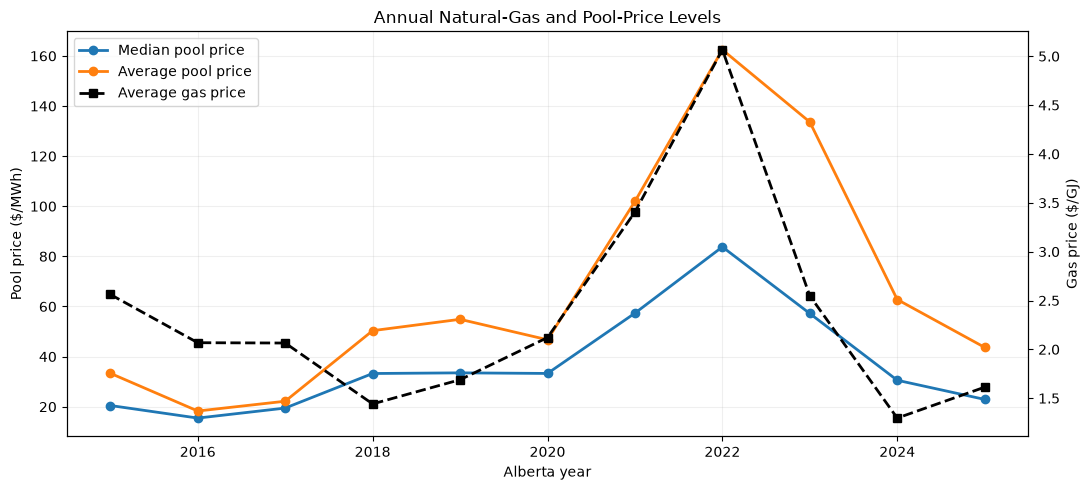

In [12]:
# ---------------------------------------------------------------------
# Plot annual gas and pool-price levels
# ---------------------------------------------------------------------

fig, ax_price = plt.subplots(
    figsize=(11, 5)
)

ax_price.plot(
    annual_price_economics.index,
    annual_price_economics[
        "median_pool_price"
    ],
    marker="o",
    linewidth=2,
    label="Median pool price",
)

ax_price.plot(
    annual_price_economics.index,
    annual_price_economics[
        "average_pool_price"
    ],
    marker="o",
    linewidth=2,
    label="Average pool price",
)

ax_price.set_xlabel("Alberta year")
ax_price.set_ylabel("Pool price ($/MWh)")
ax_price.grid(alpha=0.20)

ax_gas = ax_price.twinx()

ax_gas.plot(
    annual_price_economics.index,
    annual_price_economics[
        "average_gas_price"
    ],
    color="black",
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Average gas price",
)

ax_gas.set_ylabel("Gas price ($/GJ)")

handles_1, labels_1 = (
    ax_price.get_legend_handles_labels()
)
handles_2, labels_2 = (
    ax_gas.get_legend_handles_labels()
)

ax_price.legend(
    handles_1 + handles_2,
    labels_1 + labels_2,
    loc="upper left",
)

ax_price.set_title(
    "Annual Natural-Gas and Pool-Price Levels"
)

plt.tight_layout()
plt.show()

#### Daily and Annual Fuel-Price Variation

Gas and electricity prices moved most closely together in 2021–2022, when average gas prices rose from \$3.41 to \$5.07/GJ and pool prices from \$101.93 to \$162.46/MWh. However, the relationship is not sufficient on its own: pool prices remained elevated in 2018–2019 and 2023 despite comparatively low gas prices, then declined in 2024–2025.

Overall, gas prices help explain ordinary production costs, while scarcity, system tightness, and other market conditions explain much of the remaining price variation. Maximum annual prices provide little comparison because the market repeatedly reached its price cap.

### 2.2 Daily Gas-Price Relationship

Daily median and upper-tail pool prices are compared with the corresponding gas price.

A positive relationship would be consistent with fuel-cost pass-through. Wide vertical dispersion at the same gas price would indicate that fuel cost alone does not determine Alberta’s hourly price level.

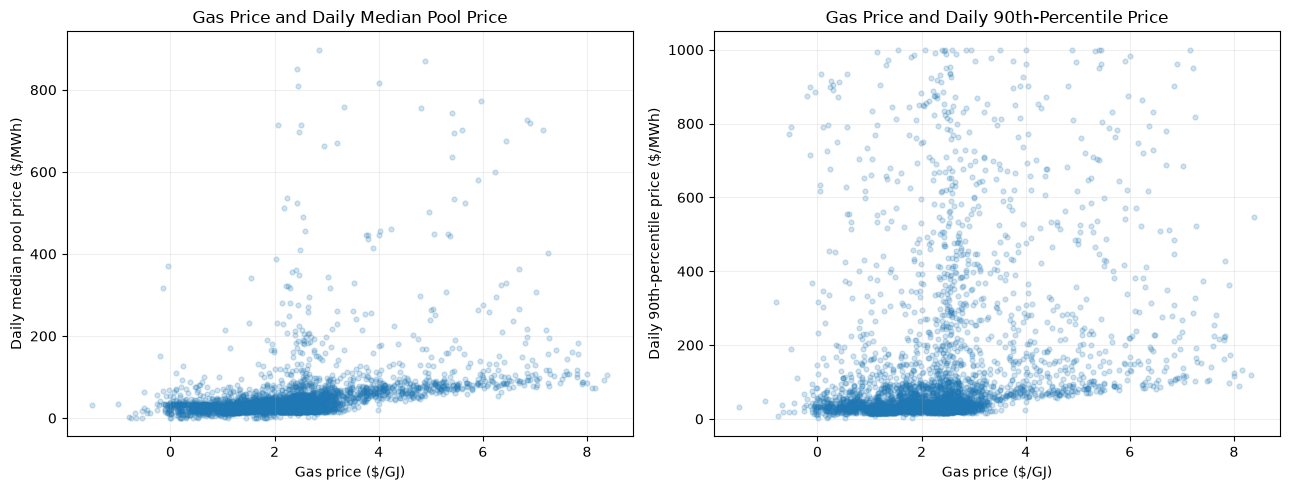

In [13]:
# ---------------------------------------------------------------------
# Plot daily gas prices against daily market outcomes
# ---------------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
)

axes[0].scatter(
    daily_market["gas_price"],
    daily_market["median_pool_price"],
    alpha=0.20,
    s=12,
)

axes[0].set_title(
    "Gas Price and Daily Median Pool Price"
)
axes[0].set_xlabel("Gas price ($/GJ)")
axes[0].set_ylabel(
    "Daily median pool price ($/MWh)"
)
axes[0].grid(alpha=0.20)

axes[1].scatter(
    daily_market["gas_price"],
    daily_market[
        "pool_price_90th_percentile"
    ],
    alpha=0.20,
    s=12,
)

axes[1].set_title(
    "Gas Price and Daily 90th-Percentile Price"
)
axes[1].set_xlabel("Gas price ($/GJ)")
axes[1].set_ylabel(
    "Daily 90th-percentile price ($/MWh)"
)
axes[1].grid(alpha=0.20)

plt.tight_layout()
plt.show()

In [14]:
# ---------------------------------------------------------------------
# Calculate daily gas-price correlations by year and regime
# ---------------------------------------------------------------------

annual_daily_correlations = pd.DataFrame([
    {
        "year_alberta": year,
        "days": len(group),
        "gas_vs_daily_median_price":
            group["gas_price"].corr(
                group["median_pool_price"],
                method="spearman",
            ),
        "gas_vs_daily_90th_percentile":
            group["gas_price"].corr(
                group[
                    "pool_price_90th_percentile"
                ],
                method="spearman",
            ),
    }
    for year, group in daily_market.groupby(
        "year_alberta"
    )
])

regime_daily_correlations = pd.DataFrame([
    {
        "structural_regime": regime,
        "days": len(group),
        "gas_vs_daily_median_price":
            group["gas_price"].corr(
                group["median_pool_price"],
                method="spearman",
            ),
        "gas_vs_daily_90th_percentile":
            group["gas_price"].corr(
                group[
                    "pool_price_90th_percentile"
                ],
                method="spearman",
            ),
    }
    for regime, group in daily_market.groupby(
        "structural_regime",
        observed=True,
    )
])

print("Annual daily correlations")
display(
    annual_daily_correlations.round(3)
)

print("Structural-regime daily correlations")
display(
    regime_daily_correlations.round(3)
)

Annual daily correlations


,year_alberta,days,gas_vs_daily_median_price,gas_vs_daily_90th_percentile
0,2015,365,0.267,0.196
1,2016,366,0.599,0.583
2,2017,365,0.193,0.203
3,2018,365,0.129,-0.017
4,2019,365,0.446,0.335
5,2020,366,0.450,0.371
6,2021,365,0.653,0.321
7,2022,365,0.459,0.084
8,2023,365,0.378,0.256
9,2024,366,0.581,0.317


Structural-regime daily correlations


,structural_regime,days,gas_vs_daily_median_price,gas_vs_daily_90th_percentile
0,Coal-dominant,1096,0.417,0.415
1,Coal-to-gas transition,1461,0.598,0.470
2,Late coal exit and renewable buildout,1096,0.717,0.436
3,Coal-free gas-renewable system,365,0.447,0.190


#### Daily Gas-Price Relationship

Gas prices are generally more closely related to daily median pool prices than to daily 90th-percentile prices, indicating that fuel costs explain ordinary price formation better than upper-tail events. The median-price relationship is strongest in 2016, 2021, and 2024, but varies considerably by year. In 2022, for example, gas prices remained moderately correlated with median prices but had almost no relationship with the daily upper tail, suggesting that scarcity conditions dominated extreme pricing.

At the regime level, the median-price correlation increases from 0.417 in the coal-dominant period to 0.598 during the coal-to-gas transition and 0.717 during the late coal-exit period. This is consistent with greater gas-price exposure in ordinary pool prices. The coal-free regime contains only 2025, however, so its weaker correlation should not yet be interpreted as a lasting structural change.

### 2.3 Year-by-Year Gas-Price Shape

Annual correlations summarize each year with one coefficient but do not show where the relationship occurs. The following heatmap compares each gas-price decile with that year’s median daily pool price. Positive values indicate that the decile’s median price is above the corresponding annual median.

Using within-year differences removes changes in the general price level and provides a more direct test of whether higher gas-price deciles are consistently associated with higher typical pool prices. Cells with fewer than 20 observed days are suppressed.

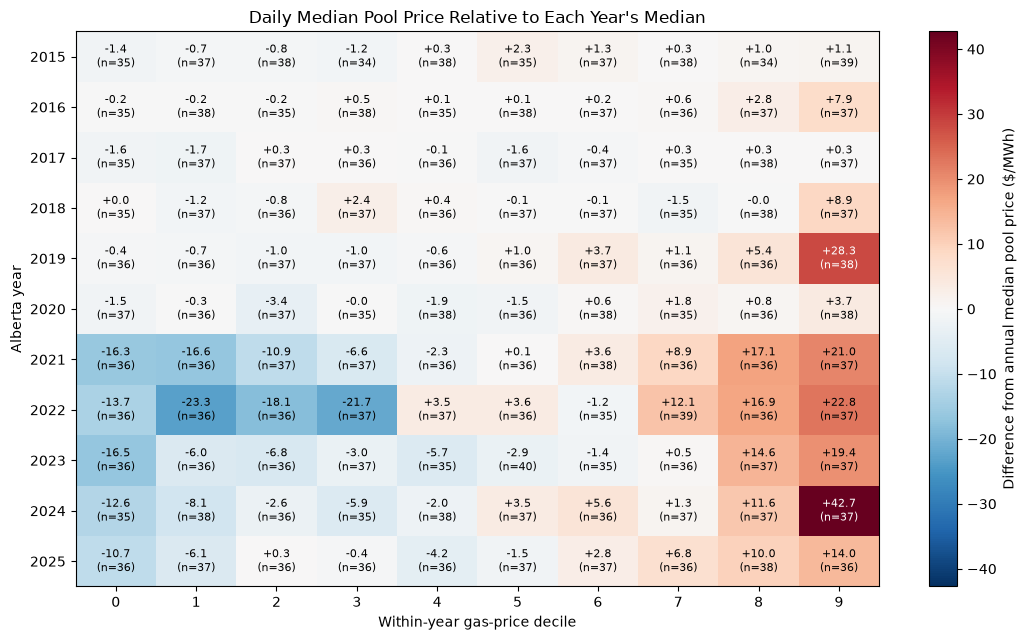

,year_alberta,supported_deciles,decile_0_median_price,decile_9_median_price,top_minus_bottom_mwh,decile_shape_spearman,positive_top_bottom
0,2015,10,19.210,21.690,2.480,0.758,True
1,2016,10,15.220,23.370,8.150,0.915,True
2,2017,10,18.505,20.425,1.920,0.706,True
3,2018,10,33.260,42.165,8.905,0.176,True
4,2019,10,33.383,62.128,28.745,0.827,True
5,2020,10,32.075,37.345,5.270,0.782,True
6,2021,10,41.212,78.490,37.277,0.988,True
7,2022,10,70.488,106.950,36.463,0.879,True
8,2023,10,39.880,75.825,35.945,0.976,True
9,2024,10,17.355,72.730,55.375,0.952,True


In [15]:
# ---------------------------------------------------------------------
# Test year-by-year gas-price-decile shape stability
# ---------------------------------------------------------------------

MINIMUM_YEAR_DECILE_DAYS = 20

year_gas_decile_summary = (
    daily_market
    .groupby(
        [
            "year_alberta",
            "gas_price_decile",
        ],
        observed=True,
    )
    .agg(
        days=("local_date", "size"),
        median_daily_pool_price=(
            "median_pool_price",
            "median",
        ),
    )
    .reset_index()
)

year_median_pool_price = (
    daily_market
    .groupby("year_alberta")[
        "median_pool_price"
    ]
    .median()
    .rename("year_median_pool_price")
    .reset_index()
)

year_gas_decile_summary = (
    year_gas_decile_summary
    .merge(
        year_median_pool_price,
        on="year_alberta",
        how="left",
    )
)

year_gas_decile_summary[
    "difference_from_year_median"
] = (
    year_gas_decile_summary[
        "median_daily_pool_price"
    ]
    - year_gas_decile_summary[
        "year_median_pool_price"
    ]
)

year_decile_values = (
    year_gas_decile_summary
    .pivot(
        index="year_alberta",
        columns="gas_price_decile",
        values="difference_from_year_median",
    )
    .reindex(columns=range(10))
    .sort_index()
)

year_decile_counts = (
    year_gas_decile_summary
    .pivot(
        index="year_alberta",
        columns="gas_price_decile",
        values="days",
    )
    .reindex(
        index=year_decile_values.index,
        columns=range(10),
    )
)

displayed_year_deciles = (
    year_decile_values
    .where(
        year_decile_counts.ge(
            MINIMUM_YEAR_DECILE_DAYS
        )
    )
)

color_limit = np.nanmax(
    np.abs(
        displayed_year_deciles.to_numpy(
            dtype=float
        )
    )
)

if not np.isfinite(color_limit) or color_limit == 0:
    color_limit = 1

fig, ax = plt.subplots(
    figsize=(11, 6.5)
)

image = ax.imshow(
    displayed_year_deciles,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-color_limit,
    vmax=color_limit,
)

ax.set_xticks(range(10))
ax.set_xticklabels(range(10))

ax.set_yticks(
    range(len(displayed_year_deciles.index))
)
ax.set_yticklabels(
    displayed_year_deciles.index
)

for row in range(
    displayed_year_deciles.shape[0]
):
    for column in range(
        displayed_year_deciles.shape[1]
    ):
        value = displayed_year_deciles.iloc[
            row,
            column,
        ]
        count = year_decile_counts.iloc[
            row,
            column,
        ]

        if np.isfinite(value):
            text_color = (
                "white"
                if abs(value) > color_limit * 0.60
                else "black"
            )

            ax.text(
                column,
                row,
                f"{value:+.1f}\n"
                f"(n={count:.0f})",
                ha="center",
                va="center",
                fontsize=8,
                color=text_color,
            )

ax.set_title(
    "Daily Median Pool Price Relative to "
    "Each Year's Median"
)
ax.set_xlabel(
    "Within-year gas-price decile"
)
ax.set_ylabel("Alberta year")

fig.colorbar(
    image,
    ax=ax,
    label=(
        "Difference from annual median "
        "pool price ($/MWh)"
    ),
)

plt.tight_layout()
plt.show()


# Summarize the direction of each annual shape

year_shape_rows = []

for year, group in (
    year_gas_decile_summary
    .groupby("year_alberta")
):
    supported = (
        group.loc[
            group["days"].ge(
                MINIMUM_YEAR_DECILE_DAYS
            )
        ]
        .sort_values("gas_price_decile")
    )

    decile_prices = (
        supported
        .set_index("gas_price_decile")[
            "median_daily_pool_price"
        ]
    )

    lowest_price = decile_prices.get(
        0,
        np.nan,
    )
    highest_price = decile_prices.get(
        9,
        np.nan,
    )

    if len(supported) >= 3:
        shape_correlation = (
            supported[
                "gas_price_decile"
            ]
            .astype(float)
            .corr(
                supported[
                    "median_daily_pool_price"
                ],
                method="spearman",
            )
        )
    else:
        shape_correlation = np.nan

    year_shape_rows.append({
        "year_alberta": year,
        "supported_deciles": len(supported),
        "decile_0_median_price": lowest_price,
        "decile_9_median_price": highest_price,
        "top_minus_bottom_mwh": (
            highest_price - lowest_price
        ),
        "decile_shape_spearman":
            shape_correlation,
        "positive_top_bottom": (
            highest_price > lowest_price
            if (
                np.isfinite(lowest_price)
                and np.isfinite(highest_price)
            )
            else pd.NA
        ),
    })

year_gas_shape_summary = pd.DataFrame(
    year_shape_rows
)

display(
    year_gas_shape_summary.round(3)
)

#### Year-by-Year Gas-Price Shape

The within-year decile analysis shows that the relationship between natural-gas prices and typical pool prices is positive in every year, but highly variable in strength and magnitude. In all years from 2015–2025, the highest gas-price decile has a higher median pool price than the lowest decile. However, the top-minus-bottom difference ranges from only \$1.92/MWh in 2017 and \$2.48/MWh in 2015 to \$55.38/MWh in 2024.

The decile-shape Spearman correlations are positive in every year and are particularly strong from 2021 onward, reaching 0.988 in 2021, 0.976 in 2023, and 0.952 in 2024. The heatmap also shows that the relationship is not simply a consequence of differences in the overall price level across years: after expressing each decile relative to its own year's median pool price, high gas-price deciles—especially deciles 8 and 9—still tend to coincide with above-median pool prices.

The relationship is nevertheless nonlinear and regime-dependent rather than a stable one-for-one fuel-cost pass-through. Earlier years often show relatively small differences across gas-price deciles, while 2019 and especially 2021–2025 display much stronger separation at the top of the gas-price distribution. Natural-gas price therefore provides a persistent economic signal for typical pool prices, but the size of that signal changes materially across years and structural market conditions.

### 2.4 Gas-Price Response Across Structural Regimes

The direction of the gas-price relationship is consistent across the sample: every year has a higher median pool price in gas-price decile 9 than in decile 0. The relationship is generally strong by rank, with annual shape correlations above 0.70 in every year except 2018. However, its magnitude varies substantially. The top-to-bottom difference is less than \$3/MWh in 2015 and 2017, compared with approximately \$36–\$55/MWh in 2021–2024.

The heatmap shows that the relationship is often concentrated in the highest gas-price deciles rather than increasing smoothly across all ten groups. This is particularly evident in 2018, which has a positive top-to-bottom difference but a weak overall shape correlation of 0.176. From 2021 onward, low gas-price deciles are generally below each year’s median price, while deciles 8 and 9 are materially above it.

Overall, higher within-year gas-price ranks are consistently associated with higher typical pool prices, but the strength and smoothness of that relationship vary by year. This supports a persistent fuel-price association without implying a constant pass-through rate or independent price-setting effect.

In [16]:
# ---------------------------------------------------------------------
# Summarize pool prices across gas-price deciles
# ---------------------------------------------------------------------

gas_decile_summary = (
    daily_market
    .groupby(
        "gas_price_decile",
        observed=True,
    )
    .agg(
        days=("local_date", "size"),
        average_gas_price=(
            "gas_price",
            "mean",
        ),
        median_daily_median_price=(
            "median_pool_price",
            "median",
        ),
        median_daily_90th_price=(
            "pool_price_90th_percentile",
            "median",
        ),
        average_daily_maximum_price=(
            "maximum_pool_price",
            "mean",
        ),
    )
)

display(gas_decile_summary.round(2))

,days,average_gas_price,median_daily_median_price,median_daily_90th_price,average_daily_maximum_price
gas_price_decile,,,,,
0,392,0.96,29.04,37.37,185.88
1,404,1.56,30.13,38.82,177.72
2,401,1.84,30.26,41.63,178.34
3,399,2.08,32.16,41.48,183.06
4,401,2.30,32.22,42.80,186.57
5,405,2.48,33.03,44.76,187.14
6,404,2.67,33.21,44.78,195.36
7,399,2.88,33.36,49.27,201.09
8,403,3.09,35.08,49.11,186.38


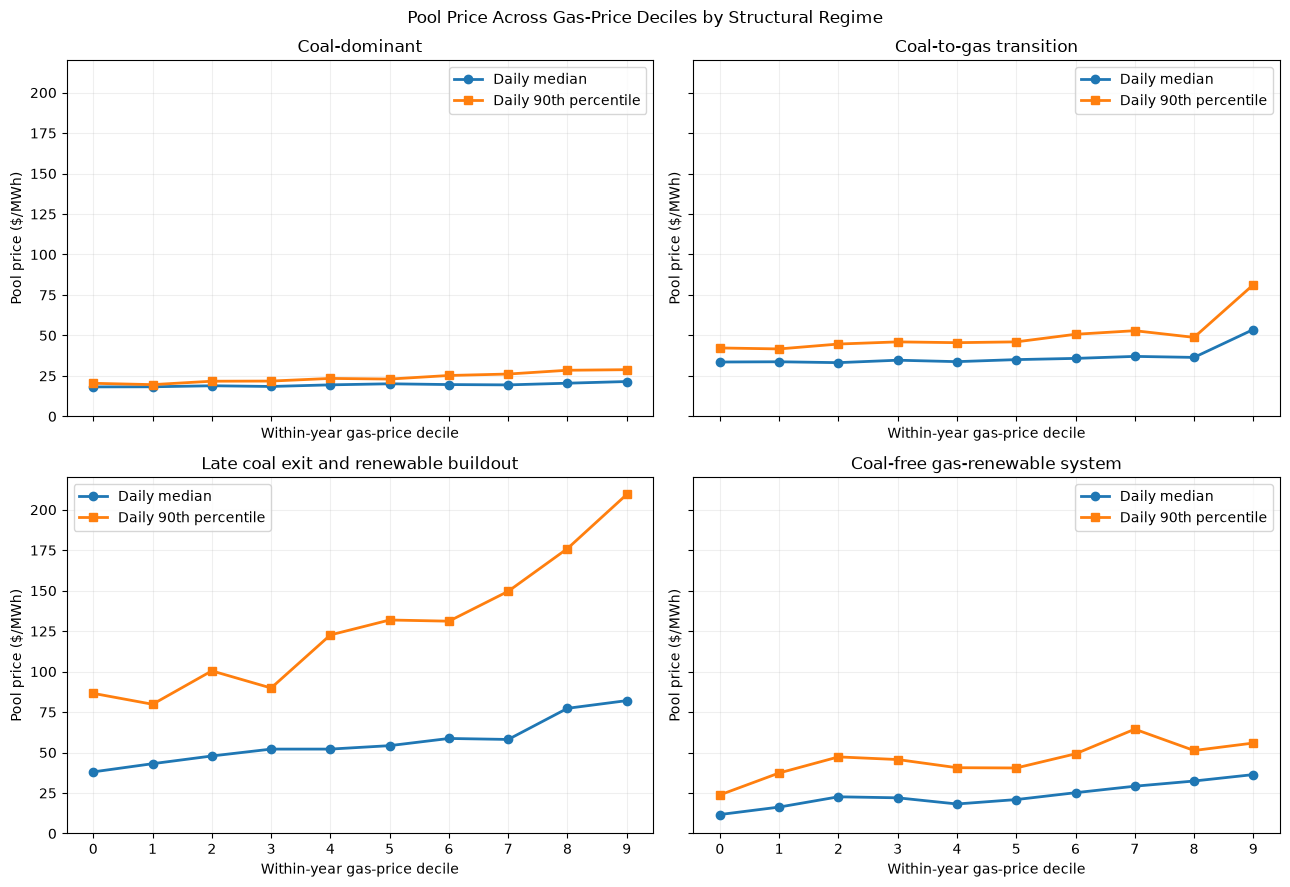

In [17]:
# ---------------------------------------------------------------------
# Compare gas-price deciles across structural regimes
# ---------------------------------------------------------------------

gas_decile_regime_summary = (
    daily_market
    .groupby(
        [
            "structural_regime",
            "gas_price_decile",
        ],
        observed=True,
    )
    .agg(
        days=("local_date", "size"),
        median_daily_pool_price=(
            "median_pool_price",
            "median",
        ),
        median_daily_90th_price=(
            "pool_price_90th_percentile",
            "median",
        ),
    )
    .reset_index()
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 9),
    sharex=True,
    sharey=True,
)

maximum_price = (
    gas_decile_regime_summary[
        "median_daily_90th_price"
    ].max()
)

for axis, regime in zip(
    axes.flatten(),
    STRUCTURAL_REGIME_ORDER,
):
    plot_data = (
        gas_decile_regime_summary.loc[
            gas_decile_regime_summary[
                "structural_regime"
            ].eq(regime)
        ]
        .set_index("gas_price_decile")
        .reindex(range(10))
    )

    axis.plot(
        plot_data.index,
        plot_data[
            "median_daily_pool_price"
        ],
        marker="o",
        linewidth=2,
        label="Daily median",
    )

    axis.plot(
        plot_data.index,
        plot_data[
            "median_daily_90th_price"
        ],
        marker="s",
        linewidth=2,
        label="Daily 90th percentile",
    )

    axis.set_title(regime)
    axis.set_xticks(range(10))
    axis.set_ylim(0, maximum_price * 1.05)
    axis.set_xlabel("Within-year gas-price decile")
    axis.set_ylabel("Pool price ($/MWh)")
    axis.grid(alpha=0.20)
    axis.legend()

fig.suptitle(
    "Pool Price Across Gas-Price Deciles "
    "by Structural Regime"
)

plt.tight_layout()
plt.show()

#### Gas-Price Response Across Structural Regimes

Pool prices generally increase with within-year gas-price deciles, but the relationship is strongest at the top of the distribution. From the lowest to highest gas-price decile, the median daily price rises from \$29.04 to \$40.40/MWh, while the daily 90th percentile increases from \$37.37 to \$70.56/MWh. Daily maximum prices are much less orderly, confirming that isolated extremes depend heavily on scarcity conditions beyond fuel costs.

The relationship is weak in the coal-dominant regime, becomes clearer during the coal-to-gas transition, and is strongest during the late coal-exit and renewable-buildout period. The coal-free regime retains a positive median-price relationship, but its upper tail is less consistent and currently represents only 2025.

### Fuel-Price Interpretation

Higher natural-gas prices are generally associated with higher typical Alberta pool prices, but the relationship is moderate and uneven. Across within-year gas-price deciles, the median daily pool price increases from \$29.04/MWh in the lowest decile to \$40.40/MWh in the highest. The daily 90th-percentile price rises more sharply, from \$37.37/MWh to \$70.56/MWh, although much of this increase is concentrated in the highest gas-price decile rather than occurring smoothly across the distribution.

The annual results show that gas prices are more consistently related to the centre of the price distribution than to its upper tail. The correlation with daily median pool price is positive in every year, ranging from 0.129 in 2018 to 0.653 in 2021. It exceeds the corresponding upper-tail correlation in ten of the eleven years. Upper-tail relationships are less stable: the gas-price correlation with the daily 90th-percentile price is slightly negative in 2018 and only 0.084 in 2022, despite that year having the highest gas and pool prices in the study period. Extreme prices therefore appear to depend much more heavily on scarcity and other operating conditions than on contemporaneous gas prices alone.

The direction of the typical-price relationship nevertheless persists within individual years. Median pool price is higher in gas-price decile 9 than in decile 0 in all eleven years. The relationship is strongly monotonic in most years, with a decile-shape Spearman correlation above 0.70 in every year except 2018. Its magnitude changes considerably, however. The top-to-bottom difference is only \$1.92/MWh in 2017 and \$2.48/MWh in 2015, compared with \$37.28/MWh in 2021, \$36.46/MWh in 2022, \$35.95/MWh in 2023, and \$55.38/MWh in 2024.

The structural-regime results are consistent with greater gas-price exposure as Alberta moved away from coal-fired generation. The correlation between gas price and daily median pool price increases from 0.417 in the coal-dominant period to 0.598 during the coal-to-gas transition and 0.717 during the late coal-exit and renewable-buildout period. The correlation falls to 0.447 in the coal-free gas-renewable regime, but that regime currently contains only 2025 and cannot establish a durable reversal. These changes should be interpreted as evolving gas-price exposure rather than identified pass-through coefficients because fleet composition, system tightness, demand, renewable output, and other market conditions also changed across the regimes.

Considerable price dispersion remains among days with similar gas-price ranks. Average daily maximum prices range from approximately \$178/MWh to \$227/MWh across the ten gas-price deciles and do not increase monotonically with gas price. Annual comparisons reinforce this point: average gas prices were nearly identical in 2015 and 2023—approximately \$2.56/GJ and \$2.55/GJ—while average pool price increased from \$33.34/MWh to \$133.63/MWh. Gas prices therefore contribute to Alberta’s ordinary electricity-price level but cannot independently explain the wide variation in daily prices or the occurrence of extreme outcomes.

Overall, the evidence supports a persistent but state-dependent relationship between fuel prices and typical pool prices. It does not establish a constant or causal gas-price pass-through rate. Physical tightness, generation availability, operating constraints, offers, and market rules remain necessary for explaining the substantial price variation observed among periods with similar gas prices.

## 3. Heat-Rate Fuel-Cost Proxies

### 3.1 Illustrative Fuel-Cost Scenarios

A gas-fired unit’s fuel cost depends on both gas price and heat rate. Four illustrative heat rates are evaluated:

- 6.0 GJ/MWh;
- 7.5 GJ/MWh;
- 9.0 GJ/MWh; and
- 12.0 GJ/MWh.

These scenarios span more-efficient through less-efficient gas-fired operation. They are not assigned to specific assets and do not include carbon compliance, variable operations and maintenance, start costs, minimum-run constraints, or opportunity costs.

The resulting values should therefore be described as fuel-cost proxies, not complete marginal costs.

In [18]:
# ---------------------------------------------------------------------
# Summarize annual heat-rate fuel-cost proxies
# ---------------------------------------------------------------------

fuel_cost_columns = [
    column
    for column in price_features.columns
    if column.startswith("fuel_cost_hr_")
]

annual_fuel_costs = (
    pd.concat(
        [
            master[["year_alberta"]],
            price_features[
                fuel_cost_columns
            ],
        ],
        axis=1,
    )
    .groupby("year_alberta")
    .agg(["mean", "median", "max"])
)

display(annual_fuel_costs.round(2))

fuel_cost_hr_6_0               fuel_cost_hr_7_5               fuel_cost_hr_9_0               fuel_cost_hr_12_0               
                         mean median    max             mean median    max             mean median    max              mean median     max
year_alberta                                                                                                                              
2015                    15.37  15.36  18.18            19.21  19.20  22.72            23.06  23.04  27.27             30.74  30.72   36.36
2016                    12.41  13.08  22.38            15.51  16.35  27.98            18.61  19.62  33.57             24.82  26.16   44.76
2017                    12.39  13.80  23.98            15.49  17.25  29.98            18.58  20.70  35.98             24.78  27.60   47.97
2018                     8.65   9.48  19.20            10.81  11.85  24.00            12.97  14.22  28.80             17.30  18.96   38.40
2019                    10.14  11.61  33.00            12.67  14.51  41.25            15.20  17.42  49.50             20.27  23.22   66.00
2020                    12.73  11.97  19.53            15.91  14.96  24.41            19.09  17.96  29.30             25.45  23.94   39.06
2021                    20.44  19.08  37.38            25.55  23.85  46.72            30.66  28.62  56.07             40.87  38.16   74.76
2022                    30.40  30.90  50.34            38.00  38.62  62.92            45.60  46.35  75.51             60.80  61.80  100.68
2023                    15.29  14.94  27.00            19.11  18.68  33.75            22.93  22.41  40.50             30.58  29.88   54.00
2024                     7.78   7.62  36.00             9.72   9.52  45.00            11.67  11.43  54.00             15.56  15.24   72.00
2025                     9.68  10.62  23.70            12.10  13.28  29.62            14.52  15.93  35.55             19.36  21.24   47.40

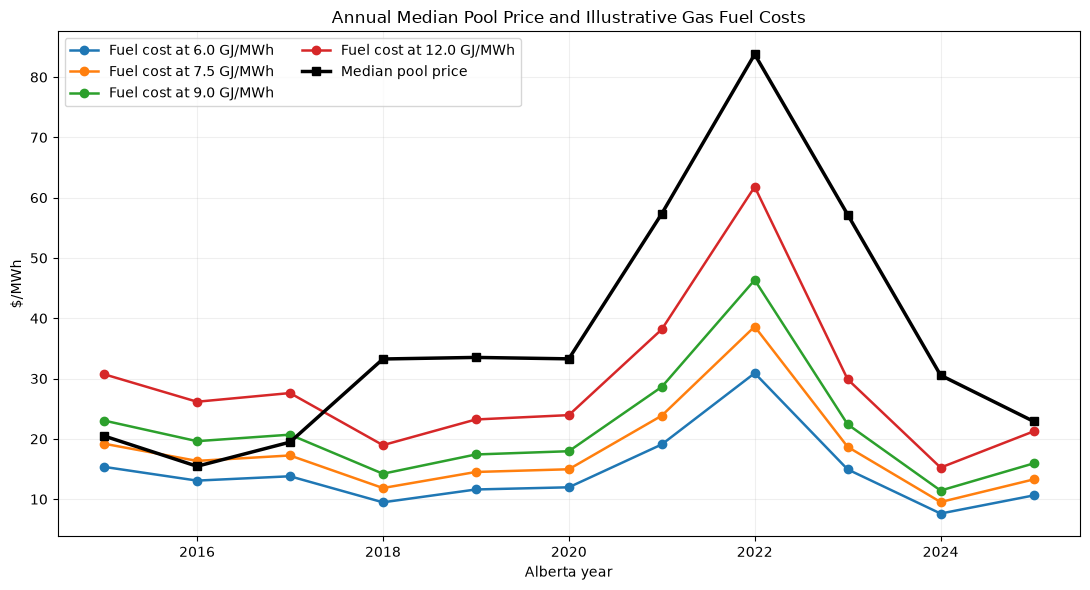

In [19]:
# ---------------------------------------------------------------------
# Plot annual fuel-cost scenarios against median pool price
# ---------------------------------------------------------------------

annual_fuel_cost_plot = (
    pd.concat(
        [
            master[["year_alberta"]],
            price_features[
                fuel_cost_columns
            ],
        ],
        axis=1,
    )
    .groupby("year_alberta")
    .median()
)

fig, ax = plt.subplots(figsize=(11, 6))

for label, heat_rate in (
    HEAT_RATE_SCENARIOS.items()
):
    column_suffix = (
        str(heat_rate).replace(".", "_")
    )

    ax.plot(
        annual_fuel_cost_plot.index,
        annual_fuel_cost_plot[
            f"fuel_cost_hr_{column_suffix}"
        ],
        marker="o",
        linewidth=1.8,
        label=label,
    )

ax.plot(
    annual_price_economics.index,
    annual_price_economics[
        "median_pool_price"
    ],
    color="black",
    marker="s",
    linewidth=2.5,
    label="Median pool price",
)

ax.set_title(
    "Annual Median Pool Price and "
    "Illustrative Gas Fuel Costs"
)
ax.set_xlabel("Alberta year")
ax.set_ylabel("$/MWh")
ax.grid(alpha=0.20)
ax.legend(ncol=2)

plt.tight_layout()
plt.show()


#### Illustrative Fuel-Cost Scenarios

Illustrative fuel costs closely follow the gas-price cycle, declining through 2018, rising sharply in 2021–2022, and moderating after 2022. However, median pool prices frequently exceed even the 12.0 GJ/MWh fuel-cost scenario, with especially large gaps in 2021–2023. This indicates that gas costs contributed to the elevated price level but cannot fully explain it; system tightness, non-fuel operating costs, and other market conditions remained important. These scenarios represent fuel costs only and should not be interpreted as complete marginal costs or profitability thresholds.

## 4. Fuel Economics Conditional on System Tightness

### 4.1 Physical Context States

Fuel costs do not operate independently of the physical system.

Notebook 2 showed that available margin and net load are central indicators of system tightness. Notebook 3 uses those variables only as conditioning states. It does not repeat the complete scarcity analysis.

Available-margin states are defined from within-year percentiles:

- **Critical:** bottom 5%;
- **Tight:** 5th–20th percentile;
- **Balanced:** 20th–80th percentile; and
- **Loose:** top 20%.

The central question is whether a given gas price corresponds to different pool-price outcomes under tight and loose physical conditions.

In [20]:
# ---------------------------------------------------------------------
# Define within-year physical context states
# ---------------------------------------------------------------------

MARGIN_STATE_ORDER = [
    "Critical",
    "Tight",
    "Balanced",
    "Loose",
]

margin_frame = pd.DataFrame({
    "year_alberta": master["year_alberta"],
    "available_margin_mw":
        price_features[
            "domestic_available_margin_mw"
        ],
})

price_features[
    "available_margin_percentile_within_year"
] = (
    margin_frame
    .groupby("year_alberta")[
        "available_margin_mw"
    ]
    .rank(method="average", pct=True)
)

price_features["margin_state"] = pd.cut(
    price_features[
        "available_margin_percentile_within_year"
    ],
    bins=[
        0,
        0.05,
        0.20,
        0.80,
        1.00,
    ],
    labels=MARGIN_STATE_ORDER,
    include_lowest=True,
)

price_features[
    "net_load_percentile_within_year"
] = (
    pd.DataFrame({
        "year_alberta":
            master["year_alberta"],
        "net_load_mw":
            price_features["net_load_mw"],
    })
    .groupby("year_alberta")[
        "net_load_mw"
    ]
    .rank(method="average", pct=True)
)

price_features["net_load_decile"] = (
    np.floor(
        price_features[
            "net_load_percentile_within_year"
        ]
        * 10
    )
    .clip(upper=9)
    .astype("Int64")
)

### 4.2 Gas Price x Available Margin

In [21]:
# ---------------------------------------------------------------------
# Summarize gas-price and margin-state interactions
# ---------------------------------------------------------------------

gas_margin_summary = (
    pd.DataFrame({
        "margin_state":
            price_features["margin_state"],
        "gas_price_decile":
            price_features[
                "gas_price_decile"
            ],
        "pool_price":
            master["pool_price"],
        "price_cost_wedge_mwh":
            price_features[
                "price_cost_wedge_mwh"
            ],
    })
    .dropna()
    .groupby(
        [
            "margin_state",
            "gas_price_decile",
        ],
        observed=True,
    )
    .agg(
        hours=("pool_price", "size"),
        median_pool_price=(
            "pool_price",
            "median",
        ),
        average_pool_price=(
            "pool_price",
            "mean",
        ),
        median_price_cost_wedge=(
            "price_cost_wedge_mwh",
            "median",
        ),
        price_90th_percentile=(
            "pool_price",
            lambda series:
                series.quantile(0.90),
        ),
    )
    .reset_index()
)

display(gas_margin_summary.round(2))

,margin_state,gas_price_decile,hours,median_pool_price,average_pool_price,median_price_cost_wedge,price_90th_percentile
0,Critical,0,352,33.38,125.91,30.94,442.49
1,Critical,1,310,58.83,187.44,34.12,759.46
2,Critical,2,374,50.76,111.24,29.41,244.67
3,Critical,3,409,47.17,143.22,27.00,511.71
4,Critical,4,377,31.79,114.74,18.60,382.54
5,Critical,5,482,37.81,130.50,21.88,498.38
6,Critical,6,468,52.28,171.35,29.16,587.21
7,Critical,7,455,72.58,253.06,44.03,886.46
8,Critical,8,615,60.89,134.27,36.58,400.39
9,Critical,9,978,76.87,226.28,49.09,779.21


In [22]:
# ---------------------------------------------------------------------
# Reusable conditional economic heatmap
# ---------------------------------------------------------------------

MINIMUM_CONDITIONAL_HOURS = 100


def plot_economic_heatmap(
    summary,
    value_column,
    title,
    colorbar_label,
    minimum_hours=MINIMUM_CONDITIONAL_HOURS,
):
    values = (
        summary
        .pivot(
            index="margin_state",
            columns="gas_price_decile",
            values=value_column,
        )
        .reindex(
            index=MARGIN_STATE_ORDER,
            columns=range(10),
        )
    )

    counts = (
        summary
        .pivot(
            index="margin_state",
            columns="gas_price_decile",
            values="hours",
        )
        .reindex(
            index=MARGIN_STATE_ORDER,
            columns=range(10),
        )
    )

    displayed_values = values.where(
        counts.ge(minimum_hours)
    )

    fig, ax = plt.subplots(
        figsize=(11, 5.5)
    )

    image = ax.imshow(
        displayed_values,
        aspect="auto",
        cmap="YlOrRd",
    )

    ax.set_xticks(range(10))
    ax.set_xticklabels(range(10))

    ax.set_yticks(
        range(len(MARGIN_STATE_ORDER))
    )
    ax.set_yticklabels(
        MARGIN_STATE_ORDER
    )

    for row in range(
        displayed_values.shape[0]
    ):
        for column in range(
            displayed_values.shape[1]
        ):
            value = displayed_values.iloc[
                row,
                column,
            ]
            count = counts.iloc[
                row,
                column,
            ]

            if np.isfinite(value):
                ax.text(
                    column,
                    row,
                    f"{value:.1f}\n"
                    f"(n={count:,.0f})",
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    ax.set_title(title)
    ax.set_xlabel(
        "Within-year gas-price decile"
    )
    ax.set_ylabel(
        "Available-margin state"
    )

    fig.colorbar(
        image,
        ax=ax,
        label=colorbar_label,
    )

    plt.tight_layout()
    plt.show()

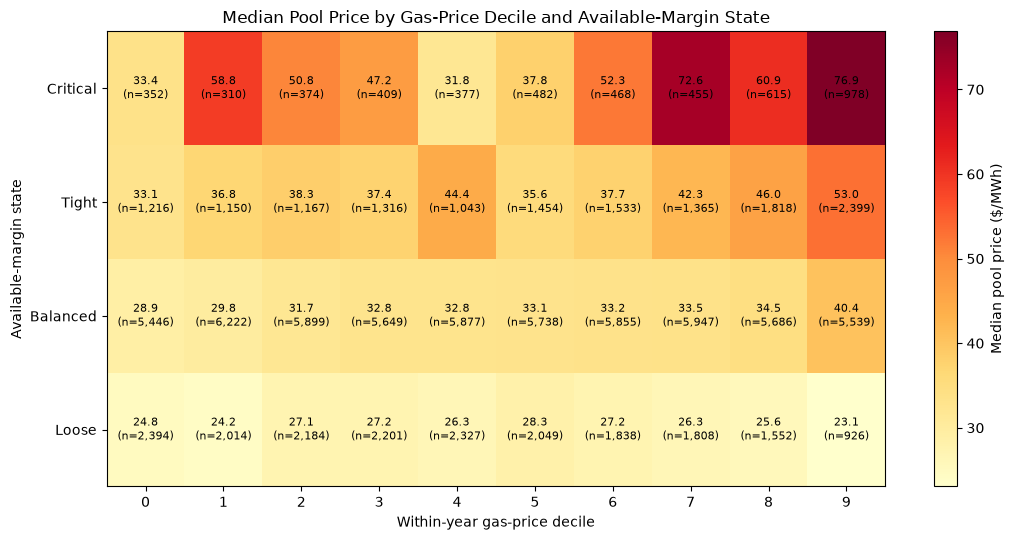

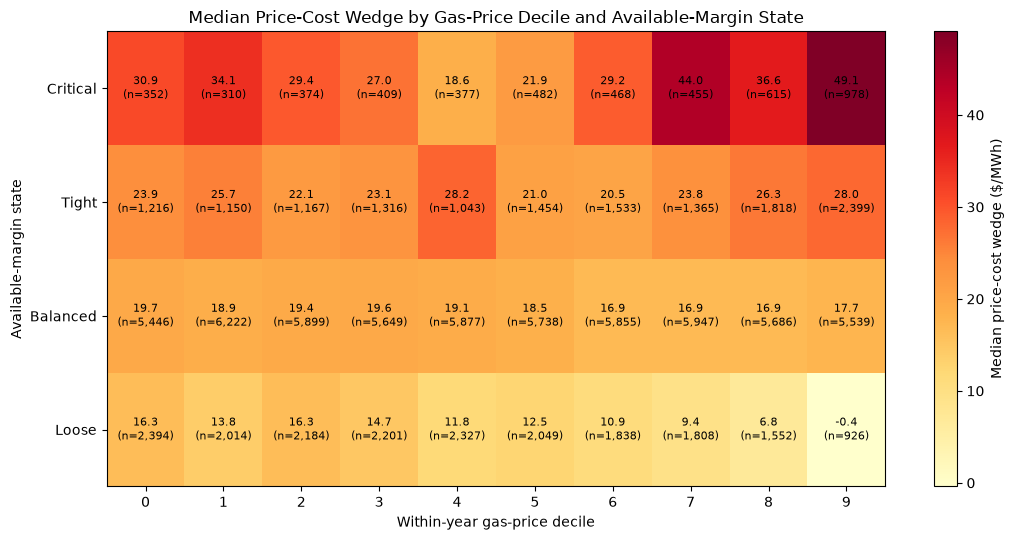

In [23]:
# ---------------------------------------------------------------------
# Plot conditional pool price and price-cost wedge
# ---------------------------------------------------------------------

plot_economic_heatmap(
    gas_margin_summary,
    value_column="median_pool_price",
    title=(
        "Median Pool Price by Gas-Price Decile "
        "and Available-Margin State"
    ),
    colorbar_label="Median pool price ($/MWh)",
)

plot_economic_heatmap(
    gas_margin_summary,
    value_column="median_price_cost_wedge",
    title=(
        "Median Price-Cost Wedge by Gas-Price "
        "Decile and Available-Margin State"
    ),
    colorbar_label=(
        "Median price-cost wedge ($/MWh)"
    ),
)

#### Gas-Price Decile x Available-Margin State

The relationship between gas prices and pool prices depends strongly on available-margin conditions. Under balanced conditions, median pool prices rise gradually from approximately \$29/MWh in the lowest gas-price decile to \$40/MWh in the highest. Tight and critical conditions produce substantially higher—but less orderly—prices, showing that physical scarcity can dominate the underlying fuel-cost relationship. Loose conditions exhibit almost no positive gas-price gradient.

The price-cost wedge reinforces this distinction. Under loose conditions, the median wedge declines as gas prices rise and becomes slightly negative in the highest decile, indicating limited pass-through of higher fuel costs. Under critical conditions, the wedge remains large and volatile, reaching \$49/MWh in the highest gas-price decile. Overall, gas costs help establish the ordinary price level, while available margin is strongly associated with whether prices separate sharply from the fixed 7.5 GJ/MWh fuel-cost benchmark. The wedge remains descriptive and should not be interpreted as profit or market markup.

### 4.3 Structural Stability of the Gas-Price and Margin Interaction

The pooled heatmap may combine materially different generation structures and year compositions. The following small multiples repeat the comparison within each structural regime using a common colour scale.

A cell is displayed only when it contains at least 30 hourly observations across at least five distinct dates. The coal-free gas-renewable regime contains only 2025 and should therefore be interpreted as preliminary rather than a stable multi-year result.

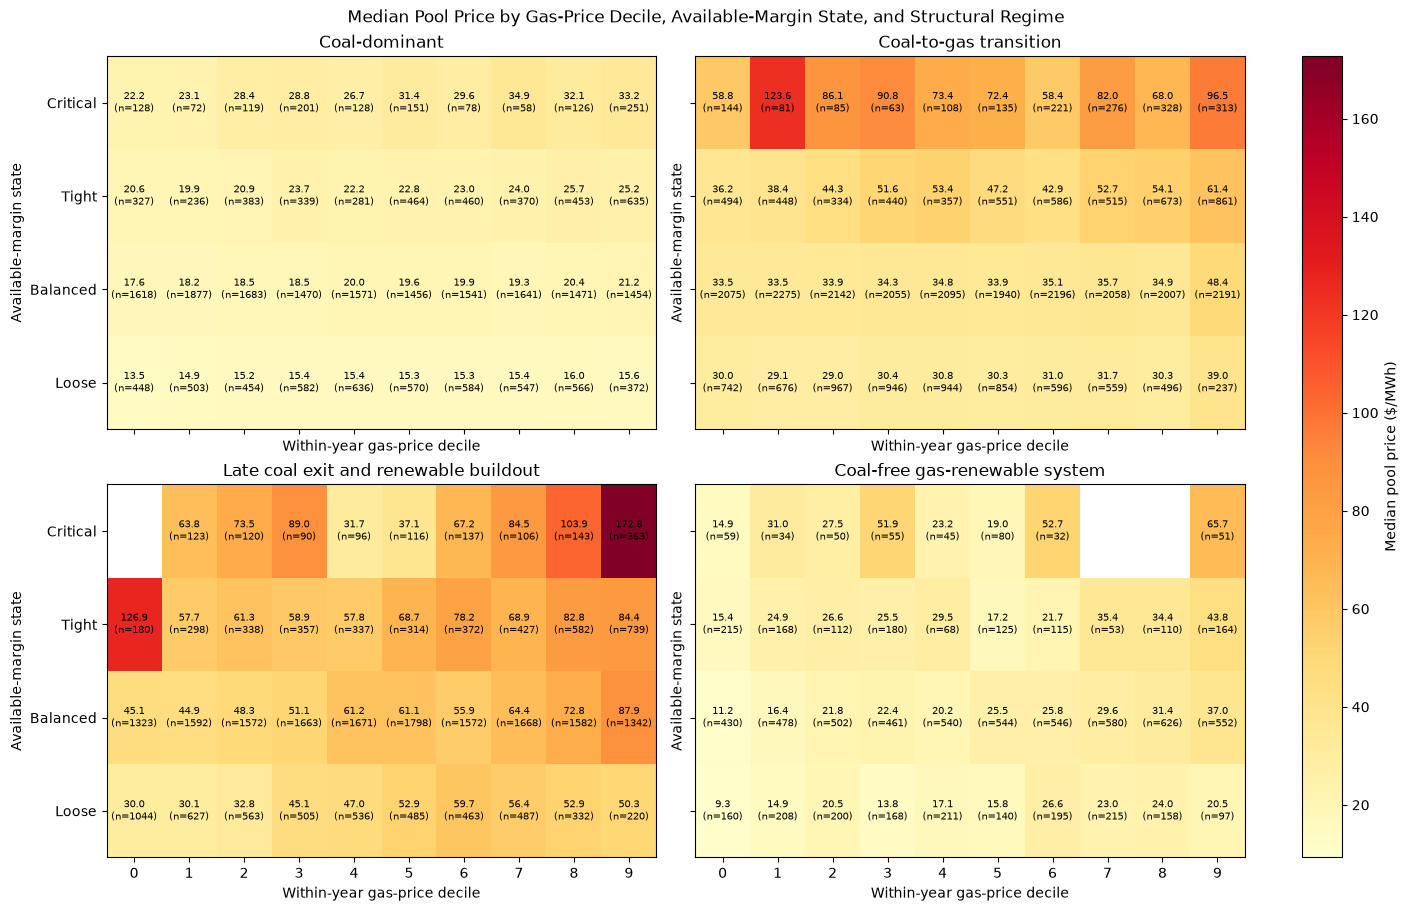

,structural_regime,margin_state,supported_deciles,minimum_years_observed,decile_0_median_price,decile_9_median_price,top_minus_bottom_mwh,decile_shape_spearman
0,Coal-dominant,Critical,10,2,22.195,33.220,11.025,0.915
1,Coal-dominant,Tight,10,3,20.590,25.160,4.570,0.903
2,Coal-dominant,Balanced,10,3,17.630,21.220,3.590,0.891
3,Coal-dominant,Loose,10,3,13.510,15.605,2.095,0.855
4,Coal-to-gas transition,Critical,10,3,58.825,96.480,37.655,-0.079
5,Coal-to-gas transition,Tight,10,4,36.200,61.410,25.210,0.806
6,Coal-to-gas transition,Balanced,10,4,33.460,48.350,14.890,0.891
7,Coal-to-gas transition,Loose,10,4,30.005,39.000,8.995,0.770
8,Late coal exit and renewable buildout,Critical,9,2,NaN,172.770,NaN,0.567
9,Late coal exit and renewable buildout,Tight,10,3,126.875,84.390,-42.485,0.394


In [24]:
# ---------------------------------------------------------------------
# Test structural stability of gas-price and margin interaction
# ---------------------------------------------------------------------

MINIMUM_REGIME_CELL_HOURS = 30
MINIMUM_REGIME_CELL_DAYS = 5

regime_gas_margin_frame = pd.DataFrame({
    "year_alberta": master["year_alberta"],
    "local_date": master["local_date"],
    "structural_regime": structural_regime,
    "margin_state":
        price_features["margin_state"],
    "gas_price_decile":
        price_features["gas_price_decile"],
    "pool_price": master["pool_price"],
})

regime_gas_margin_summary = (
    regime_gas_margin_frame
    .dropna()
    .groupby(
        [
            "structural_regime",
            "margin_state",
            "gas_price_decile",
        ],
        observed=True,
    )
    .agg(
        hours=("pool_price", "size"),
        days=("local_date", "nunique"),
        years_observed=(
            "year_alberta",
            "nunique",
        ),
        median_pool_price=(
            "pool_price",
            "median",
        ),
    )
    .reset_index()
)

regime_gas_margin_summary[
    "supported"
] = (
    regime_gas_margin_summary[
        "hours"
    ].ge(MINIMUM_REGIME_CELL_HOURS)
    & regime_gas_margin_summary[
        "days"
    ].ge(MINIMUM_REGIME_CELL_DAYS)
)

supported_prices = (
    regime_gas_margin_summary.loc[
        regime_gas_margin_summary[
            "supported"
        ],
        "median_pool_price",
    ]
)

minimum_price = supported_prices.min()
maximum_price = supported_prices.max()

if minimum_price == maximum_price:
    maximum_price = minimum_price + 1

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for axis, regime in zip(
    axes.flatten(),
    STRUCTURAL_REGIME_ORDER,
):
    regime_data = (
        regime_gas_margin_summary.loc[
            regime_gas_margin_summary[
                "structural_regime"
            ].eq(regime)
        ]
    )

    values = (
        regime_data
        .pivot(
            index="margin_state",
            columns="gas_price_decile",
            values="median_pool_price",
        )
        .reindex(
            index=MARGIN_STATE_ORDER,
            columns=range(10),
        )
    )

    hours = (
        regime_data
        .pivot(
            index="margin_state",
            columns="gas_price_decile",
            values="hours",
        )
        .reindex(
            index=MARGIN_STATE_ORDER,
            columns=range(10),
        )
    )

    days = (
        regime_data
        .pivot(
            index="margin_state",
            columns="gas_price_decile",
            values="days",
        )
        .reindex(
            index=MARGIN_STATE_ORDER,
            columns=range(10),
        )
    )

    displayed_values = (
        values
        .where(
            hours.ge(
                MINIMUM_REGIME_CELL_HOURS
            )
            & days.ge(
                MINIMUM_REGIME_CELL_DAYS
            )
        )
    )

    image = axis.imshow(
        displayed_values,
        aspect="auto",
        cmap="YlOrRd",
        vmin=minimum_price,
        vmax=maximum_price,
    )

    axis.set_title(regime)
    axis.set_xticks(range(10))
    axis.set_xticklabels(range(10))

    axis.set_yticks(
        range(len(MARGIN_STATE_ORDER))
    )
    axis.set_yticklabels(
        MARGIN_STATE_ORDER
    )

    axis.set_xlabel(
        "Within-year gas-price decile"
    )
    axis.set_ylabel(
        "Available-margin state"
    )

    for row in range(
        displayed_values.shape[0]
    ):
        for column in range(
            displayed_values.shape[1]
        ):
            value = displayed_values.iloc[
                row,
                column,
            ]
            count = hours.iloc[
                row,
                column,
            ]

            if np.isfinite(value):
                axis.text(
                    column,
                    row,
                    f"{value:.1f}\n"
                    f"(n={count:.0f})",
                    ha="center",
                    va="center",
                    fontsize=7,
                )

fig.suptitle(
    "Median Pool Price by Gas-Price Decile, "
    "Available-Margin State, and "
    "Structural Regime"
)

fig.colorbar(
    image,
    ax=axes.ravel().tolist(),
    label="Median pool price ($/MWh)",
)

plt.show()


# Summarize the gas-price gradient within each state and regime

regime_margin_gradient_rows = []

supported_regime_cells = (
    regime_gas_margin_summary.loc[
        regime_gas_margin_summary[
            "supported"
        ]
    ]
)

for (
    regime,
    margin_state,
), group in (
    supported_regime_cells
    .groupby(
        [
            "structural_regime",
            "margin_state",
        ],
        observed=True,
    )
):
    group = group.sort_values(
        "gas_price_decile"
    )

    decile_prices = (
        group
        .set_index("gas_price_decile")[
            "median_pool_price"
        ]
    )

    lowest_price = decile_prices.get(
        0,
        np.nan,
    )
    highest_price = decile_prices.get(
        9,
        np.nan,
    )

    if len(group) >= 3:
        shape_correlation = (
            group[
                "gas_price_decile"
            ]
            .astype(float)
            .corr(
                group[
                    "median_pool_price"
                ],
                method="spearman",
            )
        )
    else:
        shape_correlation = np.nan

    regime_margin_gradient_rows.append({
        "structural_regime": regime,
        "margin_state": margin_state,
        "supported_deciles": len(group),
        "minimum_years_observed": (
            group["years_observed"].min()
        ),
        "decile_0_median_price": lowest_price,
        "decile_9_median_price": highest_price,
        "top_minus_bottom_mwh": (
            highest_price - lowest_price
        ),
        "decile_shape_spearman":
            shape_correlation,
    })

regime_margin_gradient_summary = (
    pd.DataFrame(
        regime_margin_gradient_rows
    )
)

display(
    regime_margin_gradient_summary.round(3)
)

#### Structural Stability of the Gas-Price and Margin Interaction

The gas-price relationship is most stable under balanced and loose operating conditions. In the coal-dominant regime, all four margin states exhibit positive decile gradients, although the absolute price increase is modest outside critical hours. During the coal-to-gas transition, the relationship remains strongly positive under tight, balanced, and loose conditions, while critical prices become irregular and show virtually no monotonic decile pattern.

The late coal-exit and renewable-buildout regime produces the highest price levels and the clearest evidence that physical tightness can overwhelm fuel-price rank. Balanced and loose conditions retain positive gradients, but tight conditions are non-monotonic and critical prices vary sharply across deciles. The coal-free gas-renewable regime also shows generally positive gradients—particularly under balanced conditions—but contains only 2025 and cannot yet establish multi-year stability.

Overall, higher gas-price deciles are more consistently associated with higher pool prices during ordinary operating conditions than during critical hours. As margins tighten, scarcity and other physical conditions increasingly dominate the relationship, weakening the usefulness of gas-price rank as a standalone explanation of price. Cells supported by only one or two years, including the coal-free regime and parts of the late-transition critical state, should be interpreted cautiously.

### 4.4 Gas-Price Gradient Within Comparable Physical States

The preceding analysis controls separately for available-margin state and structural regime. This sensitivity check adds within-year net-load state, providing a stricter test of whether gas-price rank remains associated with pool price among hours with more comparable physical conditions.

Net load is divided into low, typical, and high within-year states. For each structural regime, available-margin state, and net-load state, the analysis measures:

the rank correlation between gas-price decile and median pool price;

the price difference between the lowest and highest supported gas-price deciles;

the number of supported deciles; and

the minimum number of years represented.

A positive conditional gradient indicates that gas price retains descriptive information after stratifying by these physical states. It does not establish causal pass-through or incremental forecasting performance.

Net-load coverage for incrementality check


,observed_hours,coverage_pct,first_reported,last_reported,years_observed
0,96432,100.0,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00,11


,structural_regime,margin_state,net_load_state,supported_deciles,minimum_years_observed,lowest_supported_decile,highest_supported_decile,lowest_decile_median_price,highest_decile_median_price,high_minus_low_price_mwh,decile_shape_spearman,shape_available,multi_year_supported,support_status
0,Coal-dominant,Critical,Low,1,2,0,0,15.350,15.350,0.000,NaN,False,False,Insufficient deciles
1,Coal-dominant,Critical,Typical,5,2,0,9,21.720,27.795,6.075,0.900,False,False,Insufficient deciles
2,Coal-dominant,Critical,High,9,2,0,9,32.590,34.790,2.200,0.583,True,True,Multi-year supported
3,Coal-dominant,Tight,Low,6,1,0,9,18.280,21.435,3.155,0.143,True,False,Single-year or partial
4,Coal-dominant,Tight,Typical,10,3,0,9,19.765,21.540,1.775,0.661,True,True,Multi-year supported
5,Coal-dominant,Tight,High,10,3,0,9,26.820,27.290,0.470,0.297,True,True,Multi-year supported
6,Coal-dominant,Balanced,Low,10,3,0,9,15.260,18.360,3.100,0.711,True,True,Multi-year supported
7,Coal-dominant,Balanced,Typical,10,3,0,9,17.660,21.170,3.510,0.988,True,True,Multi-year supported
8,Coal-dominant,Balanced,High,10,3,0,9,20.495,24.460,3.965,0.733,True,True,Multi-year supported
9,Coal-dominant,Loose,Low,10,2,0,9,13.250,15.450,2.200,0.952,True,True,Multi-year supported


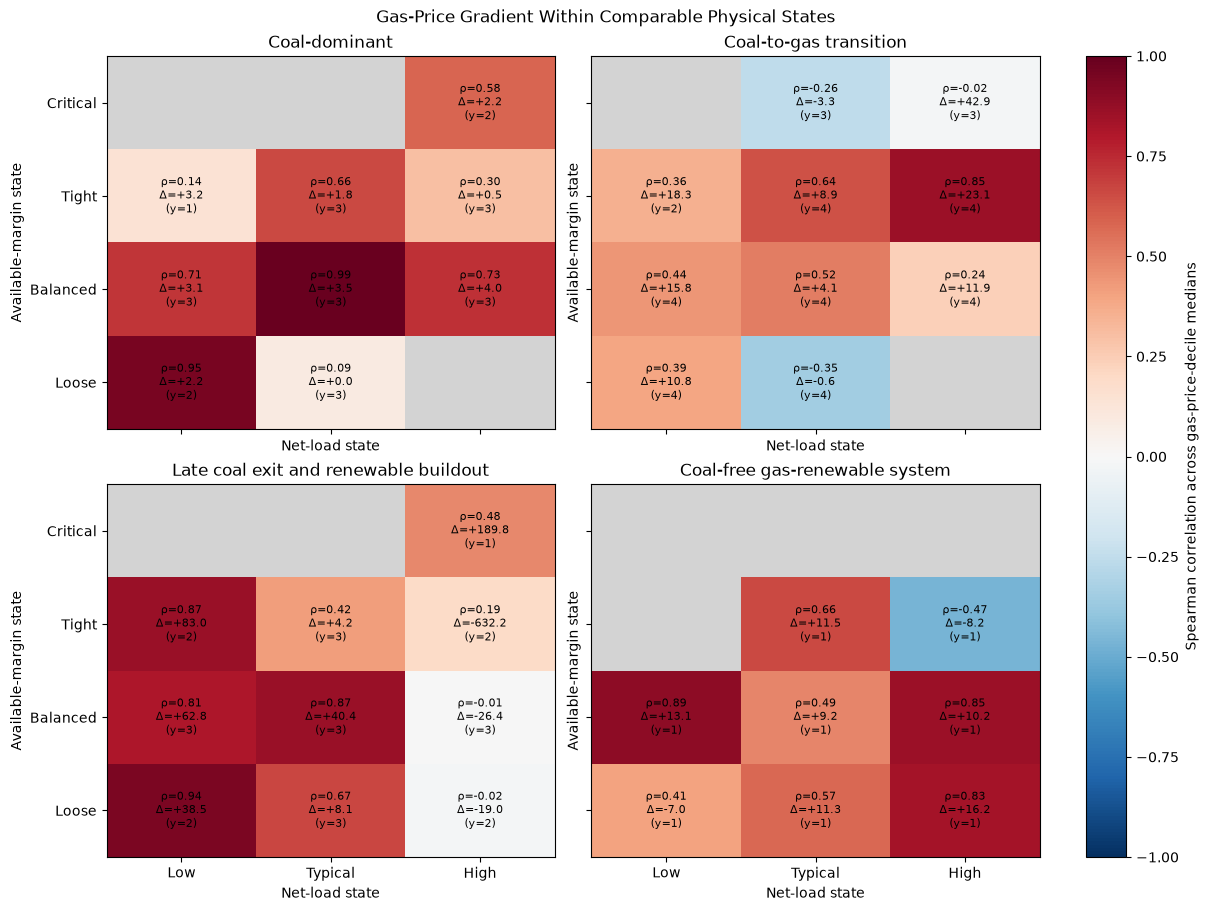

In [25]:
# ---------------------------------------------------------------------
# Test gas-price gradients within comparable physical states
# ---------------------------------------------------------------------

NET_LOAD_STATE_ORDER = [
    "Low",
    "Typical",
    "High",
]

MINIMUM_INCREMENTAL_CELL_HOURS = 30
MINIMUM_INCREMENTAL_CELL_DAYS = 5
MINIMUM_INCREMENTAL_DECILES = 6
MINIMUM_INCREMENTAL_YEARS = 2

price_features["net_load_state"] = pd.cut(
    price_features[
        "net_load_percentile_within_year"
    ],
    bins=[
        0,
        1 / 3,
        2 / 3,
        1,
    ],
    labels=NET_LOAD_STATE_ORDER,
    include_lowest=True,
)

net_load_observed = price_features[
    "net_load_mw"
].notna()

net_load_incrementality_coverage = pd.DataFrame([
    {
        "observed_hours":
            int(net_load_observed.sum()),
        "coverage_pct":
            net_load_observed.mean() * 100,
        "first_reported":
            master.loc[
                net_load_observed,
                "timestamp_alberta",
            ].min(),
        "last_reported":
            master.loc[
                net_load_observed,
                "timestamp_alberta",
            ].max(),
        "years_observed":
            master.loc[
                net_load_observed,
                "year_alberta",
            ].nunique(),
    }
])

print("Net-load coverage for incrementality check")
display(net_load_incrementality_coverage)


incrementality_frame = pd.DataFrame({
    "year_alberta": master["year_alberta"],
    "local_date": master["local_date"],
    "structural_regime": structural_regime,
    "margin_state":
        price_features["margin_state"],
    "net_load_state":
        price_features["net_load_state"],
    "gas_price_decile":
        price_features["gas_price_decile"],
    "pool_price": master["pool_price"],
})

incrementality_cells = (
    incrementality_frame
    .dropna(
        subset=[
            "structural_regime",
            "margin_state",
            "net_load_state",
            "gas_price_decile",
            "pool_price",
        ]
    )
    .groupby(
        [
            "structural_regime",
            "margin_state",
            "net_load_state",
            "gas_price_decile",
        ],
        observed=True,
    )
    .agg(
        hours=("pool_price", "size"),
        days=("local_date", "nunique"),
        years_observed=(
            "year_alberta",
            "nunique",
        ),
        median_pool_price=(
            "pool_price",
            "median",
        ),
    )
    .reset_index()
)

incrementality_cells[
    "cell_supported"
] = (
    incrementality_cells[
        "hours"
    ].ge(MINIMUM_INCREMENTAL_CELL_HOURS)
    & incrementality_cells[
        "days"
    ].ge(MINIMUM_INCREMENTAL_CELL_DAYS)
)

supported_incrementality_cells = (
    incrementality_cells.loc[
        incrementality_cells[
            "cell_supported"
        ]
    ]
)

incremental_gradient_rows = []

for (
    regime,
    margin_state,
    net_load_state,
), group in (
    supported_incrementality_cells
    .groupby(
        [
            "structural_regime",
            "margin_state",
            "net_load_state",
        ],
        observed=True,
    )
):
    group = group.sort_values(
        "gas_price_decile"
    )

    supported_deciles = len(group)
    minimum_years_observed = (
        group["years_observed"].min()
    )

    if supported_deciles >= 3:
        shape_correlation = (
            group[
                "gas_price_decile"
            ]
            .astype(float)
            .corr(
                group[
                    "median_pool_price"
                ],
                method="spearman",
            )
        )
    else:
        shape_correlation = np.nan

    if supported_deciles:
        lowest_row = group.iloc[0]
        highest_row = group.iloc[-1]

        lowest_supported_decile = int(
            lowest_row["gas_price_decile"]
        )
        highest_supported_decile = int(
            highest_row["gas_price_decile"]
        )

        lowest_decile_price = (
            lowest_row["median_pool_price"]
        )
        highest_decile_price = (
            highest_row["median_pool_price"]
        )

        high_minus_low_price = (
            highest_decile_price
            - lowest_decile_price
        )
    else:
        lowest_supported_decile = pd.NA
        highest_supported_decile = pd.NA
        lowest_decile_price = np.nan
        highest_decile_price = np.nan
        high_minus_low_price = np.nan

    shape_available = (
        supported_deciles
        >= MINIMUM_INCREMENTAL_DECILES
    )

    multi_year_supported = (
        shape_available
        and minimum_years_observed
        >= MINIMUM_INCREMENTAL_YEARS
    )

    if multi_year_supported:
        support_status = "Multi-year supported"
    elif shape_available:
        support_status = "Single-year or partial"
    else:
        support_status = "Insufficient deciles"

    incremental_gradient_rows.append({
        "structural_regime": regime,
        "margin_state": margin_state,
        "net_load_state": net_load_state,
        "supported_deciles": supported_deciles,
        "minimum_years_observed":
            minimum_years_observed,
        "lowest_supported_decile":
            lowest_supported_decile,
        "highest_supported_decile":
            highest_supported_decile,
        "lowest_decile_median_price":
            lowest_decile_price,
        "highest_decile_median_price":
            highest_decile_price,
        "high_minus_low_price_mwh":
            high_minus_low_price,
        "decile_shape_spearman":
            shape_correlation,
        "shape_available": shape_available,
        "multi_year_supported":
            multi_year_supported,
        "support_status": support_status,
    })

incremental_gradient_summary = pd.DataFrame(
    incremental_gradient_rows
)

display(
    incremental_gradient_summary.round(3)
)


# Plot conditional gas-price gradients

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

gradient_cmap = plt.get_cmap(
    "RdBu_r"
).copy()
gradient_cmap.set_bad("lightgray")

for axis, regime in zip(
    axes.flatten(),
    STRUCTURAL_REGIME_ORDER,
):
    regime_data = (
        incremental_gradient_summary.loc[
            incremental_gradient_summary[
                "structural_regime"
            ].eq(regime)
        ]
    )

    correlations = (
        regime_data
        .pivot(
            index="margin_state",
            columns="net_load_state",
            values="decile_shape_spearman",
        )
        .reindex(
            index=MARGIN_STATE_ORDER,
            columns=NET_LOAD_STATE_ORDER,
        )
    )

    price_differences = (
        regime_data
        .pivot(
            index="margin_state",
            columns="net_load_state",
            values="high_minus_low_price_mwh",
        )
        .reindex(
            index=MARGIN_STATE_ORDER,
            columns=NET_LOAD_STATE_ORDER,
        )
    )

    shape_available = (
        regime_data
        .pivot(
            index="margin_state",
            columns="net_load_state",
            values="shape_available",
        )
        .reindex(
            index=MARGIN_STATE_ORDER,
            columns=NET_LOAD_STATE_ORDER,
        )
        .fillna(False)
        .astype(bool)
    )

    years_observed = (
        regime_data
        .pivot(
            index="margin_state",
            columns="net_load_state",
            values="minimum_years_observed",
        )
        .reindex(
            index=MARGIN_STATE_ORDER,
            columns=NET_LOAD_STATE_ORDER,
        )
    )

    displayed_correlations = (
        correlations.where(shape_available)
    )

    has_supported_shape = np.isfinite(
        displayed_correlations.to_numpy(
            dtype=float
        )
    ).any()

    image = axis.imshow(
        displayed_correlations,
        aspect="auto",
        cmap=gradient_cmap,
        vmin=-1,
        vmax=1,
    )

    axis.set_title(regime)

    axis.set_xticks(
        range(len(NET_LOAD_STATE_ORDER))
    )
    axis.set_xticklabels(
        NET_LOAD_STATE_ORDER
    )

    axis.set_yticks(
        range(len(MARGIN_STATE_ORDER))
    )
    axis.set_yticklabels(
        MARGIN_STATE_ORDER
    )

    axis.set_xlabel("Net-load state")
    axis.set_ylabel(
        "Available-margin state"
    )

    unsupported_message = (
        "Insufficient supported cells"
    )

    for row in range(
        displayed_correlations.shape[0]
    ):
        for column in range(
            displayed_correlations.shape[1]
        ):
            correlation = (
                displayed_correlations.iloc[
                    row,
                    column,
                ]
            )

            price_difference = (
                price_differences.iloc[
                    row,
                    column,
                ]
            )

            years = years_observed.iloc[
                row,
                column,
            ]

            if np.isfinite(correlation):
                axis.text(
                    column,
                    row,
                    f"ρ={correlation:.2f}\n"
                    f"Δ={price_difference:+.1f}\n"
                    f"(y={years:.0f})",
                    ha="center",
                    va="center",
                    fontsize=8,
                )

fig.suptitle(
    "Gas-Price Gradient Within Comparable "
    "Physical States"
)

fig.colorbar(
    image,
    ax=axes.ravel().tolist(),
    label=(
        "Spearman correlation across "
        "gas-price-decile medians"
    ),
)

plt.show()

#### Within-State Incrementality Interpretation

Gas prices remain positively associated with pool prices in many comparable physical states, especially under balanced conditions. The relationship strengthens during the coal-to-gas transition but becomes irregular during critical, tight, and high-net-load conditions, where scarcity can overwhelm fuel-price rank.

Several later-period cells are non-monotonic, confirming that gas price alone cannot explain stressed-market outcomes. The 2025 results are preliminary because they represent only one year. Overall, fuel costs help anchor ordinary prices, while physical tightness is more strongly associated with extreme price variation.

### 4.5 Non-Extreme Price Formation

The primary purpose of Notebook 3 is to explain ordinary and moderately elevated price variation, not to repeat Notebook 2’s scarcity analysis.

The following comparison therefore excludes hours at or above \$300/MWh as a transparent sensitivity boundary. Results should be compared with the complete sample rather than interpreted as a new definition of normal market operation.

In [26]:
# ---------------------------------------------------------------------
# Compare complete and non-extreme price relationships
# ---------------------------------------------------------------------

gas_price_relationship_rows = []

for sample_name, sample_mask in {
    "Complete sample":
        master["pool_price"].notna(),

    "Pool price below $300/MWh":
        price_features[
            "non_extreme_price_hour"
        ],
}.items():

    sample = pd.DataFrame({
        "gas_price": master.loc[
            sample_mask,
            "gas_price",
        ],
        "pool_price": master.loc[
            sample_mask,
            "pool_price",
        ],
        "reference_fuel_cost_mwh":
            price_features.loc[
                sample_mask,
                "reference_fuel_cost_mwh",
            ],
        "price_cost_wedge_mwh":
            price_features.loc[
                sample_mask,
                "price_cost_wedge_mwh",
            ],
    }).dropna()

    gas_price_relationship_rows.append({
        "sample": sample_name,
        "hours": len(sample),
        "median_pool_price":
            sample["pool_price"].median(),
        "median_reference_fuel_cost":
            sample[
                "reference_fuel_cost_mwh"
            ].median(),
        "median_price_cost_wedge":
            sample[
                "price_cost_wedge_mwh"
            ].median(),
        "gas_pool_spearman_correlation":
            sample["gas_price"].corr(
                sample["pool_price"],
                method="spearman",
            ),
    })

gas_price_relationship = pd.DataFrame(
    gas_price_relationship_rows
)

display(gas_price_relationship.round(3))

,sample,hours,median_pool_price,median_reference_fuel_cost,median_price_cost_wedge,gas_pool_spearman_correlation
0,Complete sample,96432,32.85,17.175,18.050,0.395
1,Pool price below $300/MWh,92385,32.11,16.950,17.165,0.384


#### Non-Extreme Price Formation

Removing hours at or above \$300/MWh changes the gas–pool price relationship very little: the Spearman correlation declines only from 0.395 to 0.384, while median pool price falls from \$32.85 to \$32.11/MWh. The median price-cost wedge also remains substantial at approximately \$17/MWh. This indicates that the modest relationship between gas and pool prices is not being created by extreme-price events; even under non-extreme conditions, fuel cost alone explains only part of ordinary price variation.

### Conditional-Economics Interpretation

The relationship between gas prices and pool prices depends materially on the available-margin state. Under balanced conditions, median pool price increases relatively steadily from \$28.95/MWh in gas-price decile 0 to \$40.41/MWh in decile 9. Tight conditions also retain a positive but less orderly relationship, with the median increasing from \$33.11/MWh to \$53.06/MWh. Critical conditions produce the largest endpoint difference—from \$33.38/MWh to \$76.59/MWh—but prices fluctuate substantially between deciles. Under loose conditions, the pooled relationship disappears: median price declines slightly from \$24.76/MWh in decile 0 to \$23.06/MWh in decile 9.

The structural-regime analysis shows why the pooled relationships require caution. Loose-margin gas-price gradients are positive within every structural regime, despite appearing slightly negative when all years are pooled. Balanced conditions produce positive and generally monotonic gradients across all four regimes. Critical and tight conditions are much less stable. The coal-to-gas critical state has almost no monotonic relationship despite a positive endpoint difference, while tight conditions during the late coal-exit period produce an irregular and negative endpoint comparison. Gas-price exposure is therefore most consistently visible during balanced and otherwise ordinary operating conditions. During stressed conditions, scarcity events and changes in the composition of observations can overwhelm the underlying fuel-price gradient.

Physical tightness shifts both the level and upper tail of the price distribution more strongly than gas-price rank alone. In gas-price decile 9, median pool price is \$76.59/MWh under critical margins, compared with \$53.06/MWh under tight margins, \$40.41/MWh under balanced margins, and \$23.06/MWh under loose margins. The differences are even larger in the upper tail. Across gas-price deciles, 90th-percentile prices range from approximately \$245/MWh to \$886/MWh during critical conditions, compared with roughly \$49/MWh to \$77/MWh during loose conditions. A similar gas-price rank can therefore correspond to substantially different price outcomes depending on the physical operating state.

The price-cost wedge is also concentrated in tighter conditions. Under critical margins, the median wedge ranges from approximately \$18.60/MWh to \$49.07/MWh, while under tight conditions it generally remains between \$20/MWh and \$28/MWh. Balanced-state wedges are lower and comparatively stable at approximately \$17–\$20/MWh. Under loose conditions, the wedge declines as gas-price rank rises, falling from \$16.33/MWh in decile 0 to slightly below zero in decile 9. Higher gas prices therefore do not automatically translate into proportionally higher pool prices when available supply is abundant.

The more detailed comparison across structural regime, margin state, and net-load state reaches a similar conclusion. Positive gas-price gradients remain visible in many balanced-state cells, demonstrating that gas prices retain descriptive information among hours with more comparable physical conditions. The relationship becomes mixed or reverses in several critical, high-net-load, and tight-state cells. Some of these cells are supported by only one year, while others contain highly irregular price distributions. The results therefore do not support one universal conditional pass-through relationship; fuel-price exposure depends on both the physical state and the structural market regime.

Removing hours at or above \$300/MWh does not eliminate the gas-price relationship. The gas–pool-price Spearman correlation declines only slightly, from 0.395 in the complete sample to 0.384 in the non-extreme sample. Median pool price falls from \$32.85/MWh to \$32.11/MWh, while the median price-cost wedge declines from \$18.05/MWh to \$17.17/MWh. The observed fuel-price association is therefore not created solely by extreme scarcity events.

Overall, natural-gas prices are most consistently associated with the centre of Alberta’s pool-price distribution during balanced operating conditions. Physical tightness is much more strongly associated with elevated and upper-tail prices, while critical conditions weaken the monotonic relationship between gas-price rank and pool price. These conditional results describe historical associations and accounting relationships. They do not establish a causal gas-price pass-through coefficient or identify the marginal price-setting unit.

## 5. Why Is Price Near \$60/MWh Instead of \$120/MWh?

### 5.1 Price-Band Comparison

Two narrow price bands are compared:

- \$50–\$70/MWh; and
- \$110–\$130/MWh.

The comparison decomposes the difference in average pool price into:

1. the difference in the 7.5 GJ/MWh fuel-cost proxy; and
2. the remaining difference in the price-cost wedge.

Physical conditions are reported alongside the decomposition. This provides a direct descriptive answer to the notebook’s central question without treating the residual as a single identified economic mechanism.

In [27]:
# ---------------------------------------------------------------------
# Define the two price-comparison bands
# ---------------------------------------------------------------------

PRICE_COMPARISON_ORDER = [
    "$50–$70/MWh",
    "$110–$130/MWh",
]

price_comparison_group = pd.Series(
    pd.NA,
    index=master.index,
    dtype="string",
)

price_comparison_group.loc[
    master["pool_price"].between(
        50,
        70,
        inclusive="both",
    )
] = PRICE_COMPARISON_ORDER[0]

price_comparison_group.loc[
    master["pool_price"].between(
        110,
        130,
        inclusive="both",
    )
] = PRICE_COMPARISON_ORDER[1]

price_comparison_group = pd.Categorical(
    price_comparison_group,
    categories=PRICE_COMPARISON_ORDER,
    ordered=True,
)

In [28]:
# ---------------------------------------------------------------------
# Compare economic and physical conditions across price bands
# ---------------------------------------------------------------------

price_band_frame = pd.DataFrame({
    "price_band":
        price_comparison_group,

    "pool_price":
        master["pool_price"],

    "gas_price":
        master["gas_price"],

    "reference_fuel_cost_mwh":
        price_features[
            "reference_fuel_cost_mwh"
        ],

    "price_cost_wedge_mwh":
        price_features[
            "price_cost_wedge_mwh"
        ],

    "ail_mw":
        master["ail_mw"],

    "net_load_mw":
        price_features["net_load_mw"],

    "domestic_available_margin_mw":
        price_features[
            "domestic_available_margin_mw"
        ],

    "reported_supply_headroom_mw":
        price_features[
            "reported_supply_headroom_mw"
        ],

    "thermal_headroom_mw":
        price_features[
            "thermal_headroom_mw"
        ],

    "total_outage_mw":
        master["total_outage_mw"],

    "net_imports_mw":
        master["net_imports_mw"],

    "reported_gas_generation_share_pct":
        price_features[
            "gas_generation_share_pct"
        ],

    "continuous_gas_generation_share_pct":
        price_features[
            "continuous_gas_generation_share_pct"
        ],
}).dropna(subset=["price_band"])

price_band_summary = (
    price_band_frame
    .groupby(
        "price_band",
        observed=True,
    )
    .agg(
        hours=(
            "pool_price",
            "size",
        ),

        average_pool_price=(
            "pool_price",
            "mean",
        ),

        median_pool_price=(
            "pool_price",
            "median",
        ),

        average_gas_price=(
            "gas_price",
            "mean",
        ),

        average_reference_fuel_cost=(
            "reference_fuel_cost_mwh",
            "mean",
        ),

        average_price_cost_wedge=(
            "price_cost_wedge_mwh",
            "mean",
        ),

        average_load_mw=(
            "ail_mw",
            "mean",
        ),

        average_net_load_mw=(
            "net_load_mw",
            "mean",
        ),

        average_available_margin_mw=(
            "domestic_available_margin_mw",
            "mean",
        ),

        average_supply_headroom_mw=(
            "reported_supply_headroom_mw",
            "mean",
        ),

        average_thermal_headroom_mw=(
            "thermal_headroom_mw",
            "mean",
        ),

        average_total_outage_mw=(
            "total_outage_mw",
            "mean",
        ),

        net_import_observations=(
            "net_imports_mw",
            "count",
        ),

        average_net_imports_mw=(
            "net_imports_mw",
            "mean",
        ),

        average_reported_gas_generation_share_pct=(
            "reported_gas_generation_share_pct",
            "mean",
        ),

        average_continuous_gas_generation_share_pct=(
            "continuous_gas_generation_share_pct",
            "mean",
        ),
    )
    .reindex(PRICE_COMPARISON_ORDER)
)

display(price_band_summary.round(2))

,hours,average_pool_price,median_pool_price,average_gas_price,average_reference_fuel_cost,average_price_cost_wedge,average_load_mw,average_net_load_mw,average_available_margin_mw,average_supply_headroom_mw,average_thermal_headroom_mw,average_total_outage_mw,net_import_observations,average_net_imports_mw,average_reported_gas_generation_share_pct,average_continuous_gas_generation_share_pct
price_band,,,,,,,,,,,,,,,,
$50–$70/MWh,9274,58.80,58.15,3.06,22.99,35.81,9969.33,9035.06,3568.90,6442.67,3631.20,3531.96,8995,234.00,60.88,47.16
$110–$130/MWh,1180,119.05,118.74,3.75,28.09,90.96,9958.97,9298.47,3638.02,6557.11,3276.84,3677.14,1163,311.41,67.46,48.17


In [29]:
# ---------------------------------------------------------------------
# Decompose the average price difference
# ---------------------------------------------------------------------

lower_price_band = price_band_summary.loc[
    PRICE_COMPARISON_ORDER[0]
]

higher_price_band = price_band_summary.loc[
    PRICE_COMPARISON_ORDER[1]
]

price_gap_decomposition = pd.DataFrame([
    {
        "component":
            "Observed pool-price difference",
        "difference_per_mwh": (
            higher_price_band[
                "average_pool_price"
            ]
            - lower_price_band[
                "average_pool_price"
            ]
        ),
    },
    {
        "component":
            "Reference fuel-cost difference",
        "difference_per_mwh": (
            higher_price_band[
                "average_reference_fuel_cost"
            ]
            - lower_price_band[
                "average_reference_fuel_cost"
            ]
        ),
    },
    {
        "component":
            "Price-cost wedge difference",
        "difference_per_mwh": (
            higher_price_band[
                "average_price_cost_wedge"
            ]
            - lower_price_band[
                "average_price_cost_wedge"
            ]
        ),
    },
])

decomposition_error = (
    price_gap_decomposition.loc[
        price_gap_decomposition[
            "component"
        ].eq(
            "Observed pool-price difference"
        ),
        "difference_per_mwh",
    ].iloc[0]
    - price_gap_decomposition.loc[
        price_gap_decomposition[
            "component"
        ].ne(
            "Observed pool-price difference"
        ),
        "difference_per_mwh",
    ].sum()
)

assert np.isclose(
    decomposition_error,
    0,
    atol=1e-8,
)

display(price_gap_decomposition.round(2))

,component,difference_per_mwh
0,Observed pool-price difference,60.26
1,Reference fuel-cost difference,5.10
2,Price-cost wedge difference,55.15


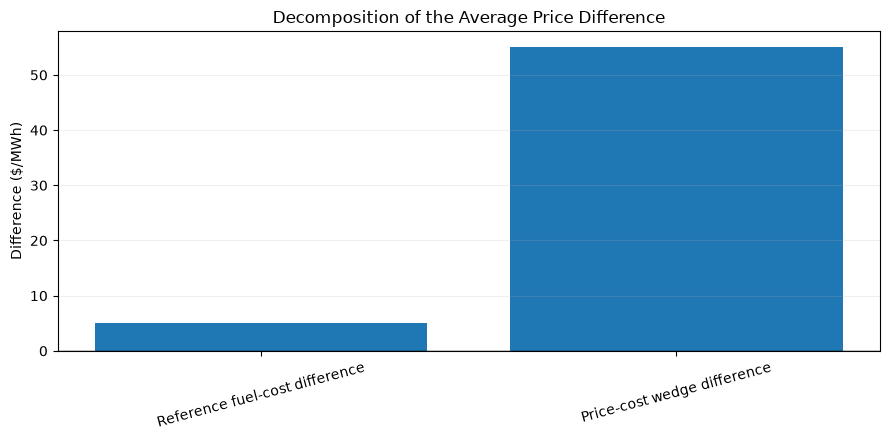

In [30]:
# ---------------------------------------------------------------------
# Plot the economic decomposition of the price difference
# ---------------------------------------------------------------------

plot_data = price_gap_decomposition.loc[
    price_gap_decomposition[
        "component"
    ].ne("Observed pool-price difference")
]

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.bar(
    plot_data["component"],
    plot_data["difference_per_mwh"],
)

ax.axhline(
    0,
    color="black",
    linewidth=1,
)

ax.set_title(
    "Decomposition of the Average Price Difference"
)
ax.set_ylabel("Difference ($/MWh)")
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.20)

plt.tight_layout()
plt.show()

#### Price-Band Comparison

The difference between the two price bands is overwhelmingly associated with the price-cost wedge rather than fuel cost. Moving from the \$50–\$70/MWh band to the \$110–\$130/MWh band raises average pool price by \$60.26/MWh, while the reference gas fuel cost increases by only \$5.10/MWh. The remaining \$55.15/MWh—approximately 92% of the price difference—appears in the wedge.

Average load and available margin are nearly unchanged, but the higher-price band has greater net load, lower thermal headroom, more outages, and higher net imports. Its reported gas-generation share is also higher, although the increase is much smaller when the comparison is restricted to continuously reported gas technologies. Prices near \$120/MWh therefore coincide with tighter thermal operating conditions rather than a proportional increase in gas prices alone.

### Price-Level Interpretation

The comparison provides a direct accounting answer to why the market clears near \$120/MWh rather than \$60/MWh. Average pool price increases by \$60.26/MWh between the two price bands, from \$58.80/MWh to \$119.05/MWh. The selected 7.5 GJ/MWh reference fuel-cost proxy increases by only \$5.10/MWh, from \$22.99/MWh to \$28.09/MWh. The selected fuel-cost difference represents approximately 8.5% of the accounting decomposition.

The remaining \$55.15/MWh, or approximately 91.5% of the difference, appears in the price-cost wedge. The average wedge increases from \$35.81/MWh in the \$50–\$70/MWh band to \$90.96/MWh in the \$110–\$130/MWh band. This does not mean the difference represents an offer markup, profit margin, or identified scarcity rent. It is the portion not captured by the fixed fuel-only benchmark and may contain carbon and operating costs, unit constraints, scarcity conditions, transmission effects, offer behaviour, market rules, and other unobserved mechanisms.

Gross load is almost identical across the two groups and is slightly lower in the higher-price band. Net load, however, increases by approximately 263 MW, from 9,035 MW to 9,298 MW. The higher-price observations therefore occur when more demand remains to be served after wind and solar generation are removed, even though total Alberta load is not higher.

The system-wide availability measures do not indicate a lower overall available margin. Average domestic available margin increases slightly from 3,569 MW to 3,638 MW, while reported supply headroom rises from 6,443 MW to 6,557 MW. Thermal headroom moves in the opposite direction, declining by approximately 354 MW from 3,631 MW to 3,277 MW. The distinction is important: prices near \$120/MWh are not associated with a smaller reported system-wide available margin, but they are associated with less unused availability in the thermal fleet.

Outages and intertie flows also differ. Average total outages increase by approximately 145 MW, from 3,532 MW to 3,677 MW. Average net imports rise from 234 MW to 311 MW, an increase of approximately 77 MW. Net-import averages exclude hours with unreported intertie flows: they use 8,995 of 9,274 lower-band hours and 1,163 of 1,180 upper-band hours. Higher imports should not be interpreted as causing the higher price; they may represent external supply responding contemporaneously to tighter Alberta conditions.

Reported gas generation increases from 60.88% to 67.46% of total system generation, but the continuously reported technology measure rises only from 47.16% to 48.17%. The direction is consistent, while the magnitude is sensitive to changing technology coverage. Combined with the reduction in thermal headroom, the results indicate greater thermal-fleet utilization when prices are near \$120/MWh. Because generation is observed after dispatch, both measures remain operating-state indicators rather than independently causal price drivers.

Overall, the difference between prices near \$60/MWh and \$120/MWh is not primarily associated with a proportional increase in natural-gas fuel cost. Fuel cost accounts for only about \$5/MWh of the \$60/MWh difference. The much larger wedge coincides with higher net load, reduced thermal headroom, greater outages, increased import support, and greater thermal-fleet utilization. These results describe the operating conditions accompanying the two price levels but do not identify the marginal unit or establish the causal contribution of any individual mechanism.

## 6. Gas-Fleet Context and Evidence Limits

### 6.1 Gas-Generation Intensity

Gas-generation output helps establish whether higher prices occur when Alberta relies more heavily on gas-fired technologies.

Actual generation is contemporaneous and partly reflects the dispatch response to price. It therefore provides historical context but is not automatically forecast eligible.

The available data do not identify the marginal generating unit. A high gas-generation share should not be described as proof that a particular gas unit set price.

In [31]:
# ---------------------------------------------------------------------
# Compare gas-technology generation across price bands
# ---------------------------------------------------------------------

gas_technology_price_band = (
    pd.concat(
        [
            pd.Series(
                price_comparison_group,
                name="price_band",
            ),
            master[GAS_GENERATION_COLUMNS],
        ],
        axis=1,
    )
    .dropna(subset=["price_band"])
    .groupby(
        "price_band",
        observed=True,
    )
    .mean()
    .reindex(PRICE_COMPARISON_ORDER)
)

gas_technology_price_band.columns = [
    column.replace(
        "_system_generation",
        "",
    )
    for column
    in gas_technology_price_band.columns
]

display(
    gas_technology_price_band.round(2)
)

,cogeneration,combined_cycle,dual_fuel,gas_fired_steam,simple_cycle
price_band,,,,,
$50–$70/MWh,1658.40,1330.44,283.22,941.69,359.25
$110–$130/MWh,1595.38,1356.23,383.40,1280.08,439.87


In [32]:
# ---------------------------------------------------------------------
# Examine price across gas-generation-share deciles
# ---------------------------------------------------------------------

gas_share_frame = pd.DataFrame({
    "year_alberta": master["year_alberta"],
    "gas_generation_share_pct":
        price_features[
            "gas_generation_share_pct"
        ],
    "pool_price": master["pool_price"],
    "price_cost_wedge_mwh":
        price_features[
            "price_cost_wedge_mwh"
        ],
}).dropna()

gas_share_frame[
    "gas_share_percentile_within_year"
] = (
    gas_share_frame
    .groupby("year_alberta")[
        "gas_generation_share_pct"
    ]
    .rank(method="average", pct=True)
)

gas_share_frame["gas_share_decile"] = (
    np.floor(
        gas_share_frame[
            "gas_share_percentile_within_year"
        ]
        * 10
    )
    .clip(upper=9)
    .astype("Int64")
)

gas_share_decile_summary = (
    gas_share_frame
    .groupby(
        "gas_share_decile",
        observed=True,
    )
    .agg(
        hours=("pool_price", "size"),
        average_gas_share_pct=(
            "gas_generation_share_pct",
            "mean",
        ),
        median_pool_price=(
            "pool_price",
            "median",
        ),
        price_90th_percentile=(
            "pool_price",
            lambda series:
                series.quantile(0.90),
        ),
        median_price_cost_wedge=(
            "price_cost_wedge_mwh",
            "median",
        ),
    )
)

display(gas_share_decile_summary.round(2))

,hours,average_gas_share_pct,median_pool_price,price_90th_percentile,median_price_cost_wedge
gas_share_decile,,,,,
0,9634,39.18,24.99,50.30,6.95
1,9642,42.95,29.19,55.59,12.30
2,9645,45.22,30.44,65.68,14.08
3,9642,47.23,31.74,74.05,15.76
4,9642,49.18,32.78,84.31,17.41
5,9645,51.04,33.21,94.77,19.03
6,9642,52.96,33.65,120.38,20.35
7,9645,55.08,35.20,173.99,22.46
8,9642,57.70,38.11,257.25,25.01


In [33]:
# ---------------------------------------------------------------------
# Test sensitivity to changing gas-technology reporting
# ---------------------------------------------------------------------

def summarize_gas_share_deciles(
    values,
    measure,
):
    frame = pd.DataFrame({
        "year_alberta":
            master["year_alberta"],
        "gas_generation_share_pct":
            values,
        "pool_price":
            master["pool_price"],
        "price_cost_wedge_mwh":
            price_features[
                "price_cost_wedge_mwh"
            ],
    }).dropna()

    frame[
        "gas_share_percentile_within_year"
    ] = (
        frame
        .groupby("year_alberta")[
            "gas_generation_share_pct"
        ]
        .rank(method="average", pct=True)
    )

    frame["gas_share_decile"] = (
        np.floor(
            frame[
                "gas_share_percentile_within_year"
            ]
            * 10
        )
        .clip(upper=9)
        .astype("Int64")
    )

    summary = (
        frame
        .groupby(
            "gas_share_decile",
            observed=True,
        )
        .agg(
            hours=("pool_price", "size"),

            average_gas_share_pct=(
                "gas_generation_share_pct",
                "mean",
            ),

            median_pool_price=(
                "pool_price",
                "median",
            ),

            price_90th_percentile=(
                "pool_price",
                lambda series:
                    series.quantile(0.90),
            ),

            median_price_cost_wedge=(
                "price_cost_wedge_mwh",
                "median",
            ),
        )
        .reset_index()
    )

    summary.insert(
        0,
        "measure",
        measure,
    )

    return summary


gas_share_reporting_sensitivity = pd.concat(
    [
        summarize_gas_share_deciles(
            price_features[
                "gas_generation_share_pct"
            ],
            "All reported gas technologies",
        ),

        summarize_gas_share_deciles(
            price_features[
                "continuous_gas_generation_share_pct"
            ],
            "Continuously reported technologies",
        ),
    ],
    ignore_index=True,
)

display(
    gas_share_reporting_sensitivity.round(2)
)

,measure,gas_share_decile,hours,average_gas_share_pct,median_pool_price,price_90th_percentile,median_price_cost_wedge
0,All reported gas technologies,0,9634,39.18,24.99,50.30,6.95
1,All reported gas technologies,1,9642,42.95,29.19,55.59,12.30
2,All reported gas technologies,2,9645,45.22,30.44,65.68,14.08
3,All reported gas technologies,3,9642,47.23,31.74,74.05,15.76
4,All reported gas technologies,4,9642,49.18,32.78,84.31,17.41
5,All reported gas technologies,5,9645,51.04,33.21,94.77,19.03
6,All reported gas technologies,6,9642,52.96,33.65,120.38,20.35
7,All reported gas technologies,7,9645,55.08,35.20,173.99,22.46
8,All reported gas technologies,8,9642,57.70,38.11,257.25,25.01
9,All reported gas technologies,9,9653,61.83,43.28,442.06,28.64


In [34]:
# ---------------------------------------------------------------------
# Compare lowest and highest gas-share deciles
# ---------------------------------------------------------------------

gas_share_sensitivity_rows = []

for measure, group in (
    gas_share_reporting_sensitivity
    .groupby("measure")
):
    group = group.set_index(
        "gas_share_decile"
    )

    gas_share_sensitivity_rows.append({
        "measure": measure,

        "decile_0_median_price":
            group.loc[
                0,
                "median_pool_price",
            ],

        "decile_9_median_price":
            group.loc[
                9,
                "median_pool_price",
            ],

        "median_price_difference":
            (
                group.loc[
                    9,
                    "median_pool_price",
                ]
                - group.loc[
                    0,
                    "median_pool_price",
                ]
            ),

        "decile_0_price_90th_percentile":
            group.loc[
                0,
                "price_90th_percentile",
            ],

        "decile_9_price_90th_percentile":
            group.loc[
                9,
                "price_90th_percentile",
            ],

        "upper_tail_difference":
            (
                group.loc[
                    9,
                    "price_90th_percentile",
                ]
                - group.loc[
                    0,
                    "price_90th_percentile",
                ]
            ),
    })

gas_share_sensitivity_summary = pd.DataFrame(
    gas_share_sensitivity_rows
)

display(
    gas_share_sensitivity_summary.round(2)
)

,measure,decile_0_median_price,decile_9_median_price,median_price_difference,decile_0_price_90th_percentile,decile_9_price_90th_percentile,upper_tail_difference
0,All reported gas technologies,24.99,43.28,18.29,50.30,442.06,391.75
1,Continuously reported technologies,27.86,38.03,10.16,70.98,231.48,160.51


#### Gas-Generation Intensity

Pool prices increase with reported gas-generation share. From the lowest to highest decile, median pool price rises from \$24.99/MWh to \$43.26/MWh, while the 90th percentile increases from \$50.30/MWh to \$442.06/MWh.

The relationship remains positive when restricted to cogeneration, combined cycle, and simple cycle, which are reported continuously: median price rises from \$27.86/MWh to \$38.04/MWh and the 90th percentile from \$70.98/MWh to \$231.50/MWh. The direction is therefore robust, although changing technology coverage amplifies its magnitude.

Gas-generation share remains a descriptive operating-state indicator, not an independently causal or automatically forecast-eligible driver.

## 7. Offer-Stack Evidence and Market Price Formation

The AESO API data permit a more direct examination of how the available energy offer stack, dispatch position, System Marginal Price, offer control, and operating-reserve conditions relate to hourly pool prices.

This section asks:

1. Does the pool price rise when low-priced available supply becomes exhausted?
2. Is the relationship still visible within comparable physical-margin states?
3. Does the marginal-price record reconcile with the hourly pool price?
4. Is offer-control concentration associated with additional price separation?
5. Do the relationships persist across years and structural regimes?
6. What changes around the onset of high-price events?
7. Do operating-reserve conditions or unit-commitment directives add useful context?
8. Which fields are descriptive, timing-dependent, or potentially forecast eligible?

The analysis is descriptive. Most merit-order, SMP, reserve, and dispatch fields describe the target hour and were released publicly after the fact. They explain price formation but must not automatically be treated as ex-ante predictors.

In [35]:
# ---------------------------------------------------------------------
# Define the AESO API analysis contract
# ---------------------------------------------------------------------

TAIL_PRICE_THRESHOLD = 500
MINIMUM_CELL_HOURS = 100
MINIMUM_CELL_DAYS = 10
MINIMUM_MATCHED_CELL_HOURS = 50
EVENT_WINDOW_HOURS = 12
MINIMUM_EVENT_SEPARATION_HOURS = 24

MERIT_CUMULATIVE_COLUMNS = [
    "aeso_merit_available_mw_at_or_below_0",
    "aeso_merit_available_mw_at_or_below_50",
    "aeso_merit_available_mw_at_or_below_100",
    "aeso_merit_available_mw_at_or_below_250",
    "aeso_merit_available_mw_at_or_below_500",
]

MERIT_REQUIRED_COLUMNS = [
    "aeso_merit_block_count",
    "aeso_merit_asset_count",
    "aeso_merit_offer_controller_count",
    "aeso_merit_available_mw",
    "aeso_merit_dispatched_mw",
    "aeso_merit_import_available_mw",
    "aeso_merit_flexible_available_mw",
    "aeso_merit_available_price_weighted_mean",
    "aeso_merit_available_price_p50",
    "aeso_merit_available_price_p90",
    "aeso_merit_dispatched_price_weighted_mean",
    "aeso_merit_highest_dispatched_offer",
    "aeso_merit_offer_control_hhi",
    "aeso_merit_order_archive_available",
    *MERIT_CUMULATIVE_COLUMNS,
]

SMP_REQUIRED_COLUMNS = [
    "aeso_smp_observed_minutes",
    "aeso_smp_minimum_cad_mwh",
    "aeso_smp_maximum_cad_mwh",
    "aeso_smp_last_cad_mwh",
    "aeso_smp_interval_count",
    "aeso_smp_time_weighted_mean_cad_mwh",
    "aeso_smp_archive_available",
]

RESERVE_REQUIRED_COLUMNS = [
    "aeso_or_active_volume_mw",
    "aeso_or_standby_volume_mw",
    "aeso_or_active_price_weighted_mean",
    "aeso_or_standby_premium_weighted_mean",
    "aeso_or_standby_activation_price_weighted_mean",
    "aeso_operating_reserve_archive_available",
]

CAPACITY_REQUIRED_COLUMNS = [
    "aeso_gen_system_maximum_capability_mw",
    "aeso_gen_system_operating_outage_mw",
    "aeso_gen_system_available_capability_mw",
    "aeso_gen_system_total_unavailable_mw",
    "aeso_generation_capacity_archive_available",
]

UNIT_COMMITMENT_COLUMNS = [
    "aeso_unit_commitment_directives_issued",
    "aeso_unit_commitment_assets_issued",
    "aeso_unit_commitment_median_lead_hours",
    "aeso_unit_commitment_active_directives",
    "aeso_unit_commitment_active_assets",
    "aeso_unit_commitment_archive_available",
]

API_REQUIRED_COLUMNS = [
    *MERIT_REQUIRED_COLUMNS,
    *SMP_REQUIRED_COLUMNS,
    *RESERVE_REQUIRED_COLUMNS,
    *CAPACITY_REQUIRED_COLUMNS,
    *UNIT_COMMITMENT_COLUMNS,
]

missing_api_columns = sorted(
    set(API_REQUIRED_COLUMNS) - set(master.columns)
)

if missing_api_columns:
    raise ValueError(
        "Notebook 3 is missing required AESO API columns: "
        f"{missing_api_columns}"
    )

print(
    "AESO API contract passed: "
    f"{len(API_REQUIRED_COLUMNS)} required fields present."
)

AESO API contract passed: 43 required fields present.


### 7.1 Coverage, Definitions, and Information Timing

Missing API values are not automatically zeros. A zero is interpreted as an observed zero only when the corresponding archive-availability flag is active.

The energy merit-order archive is nearly complete but has three missing hours in the current study period. These hours remain missing and are excluded from calculations requiring merit-order data.

The available-price median is also examined for degeneracy. A feature that is constant or nearly constant should not be retained merely because it has an economically meaningful name.

In [36]:
# ---------------------------------------------------------------------
# Audit coverage and information timing
# ---------------------------------------------------------------------

api_family_contract = {
    "Energy merit order": {
        "availability": "aeso_merit_order_archive_available",
        "features": MERIT_REQUIRED_COLUMNS,
        "timing": "Same-hour ex-post snapshot; public release is delayed",
        "notebook_role": "Primary price-formation evidence",
    },
    "System marginal price": {
        "availability": "aeso_smp_archive_available",
        "features": SMP_REQUIRED_COLUMNS,
        "timing": "Realized intra-hour marginal-price record",
        "notebook_role": "Settlement-price reconciliation",
    },
    "Operating reserve": {
        "availability": "aeso_operating_reserve_archive_available",
        "features": RESERVE_REQUIRED_COLUMNS,
        "timing": "Same-hour reserve offer outcome; delayed publication",
        "notebook_role": "Conditional operating context",
    },
    "Generation capacity": {
        "availability": "aeso_generation_capacity_archive_available",
        "features": CAPACITY_REQUIRED_COLUMNS,
        "timing": "Target-hour record without a preserved forecast vintage",
        "notebook_role": "Reconciliation and physical control",
    },
    "Unit commitment": {
        "availability": "aeso_unit_commitment_archive_available",
        "features": UNIT_COMMITMENT_COLUMNS,
        "timing": "Issued time is observed, but archive begins in 2024",
        "notebook_role": "Short-history sensitivity only",
    },
}

coverage_rows = []

for family, contract in api_family_contract.items():
    availability = master[contract["availability"]].eq(1)

    analysis_columns = [
        column for column in contract["features"]
        if not column.endswith("_archive_available")
    ]

    coverage_rows.append({
        "family": family,
        "available_hours": int(availability.sum()),
        "coverage_pct": availability.mean() * 100,
        "first_available": master.loc[availability, "timestamp_alberta"].min(),
        "last_available": master.loc[availability, "timestamp_alberta"].max(),
        "missing_values_during_coverage": int(master.loc[availability, analysis_columns].isna().sum().sum()
        ),
        "timing": contract["timing"],
        "notebook_role": contract["notebook_role"],
    })

api_coverage = pd.DataFrame(coverage_rows)

display(api_coverage.round(2))

merit_missing_hours = master.loc[
    master["aeso_merit_order_archive_available"].eq(0),
    ["timestamp_utc", "timestamp_alberta", "pool_price"],
]

print("Hours without a merit-order snapshot")
display(merit_missing_hours)

/var/folders/8n/b2fxypd96y51y569zlb4_f1w0000gn/T/ipykernel_76212/4087023081.py:62: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(api_coverage.round(2))


,family,available_hours,coverage_pct,first_available,last_available,missing_values_during_coverage,timing,notebook_role
0,Energy merit order,96429,100.00,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00,0,Same-hour ex-post snapshot; public release is ...,Primary price-formation evidence
1,System marginal price,96432,100.00,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00,0,Realized intra-hour marginal-price record,Settlement-price reconciliation
2,Operating reserve,96432,100.00,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00,0,Same-hour reserve offer outcome; delayed publi...,Conditional operating context
3,Generation capacity,96432,100.00,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00,0,Target-hour record without a preserved forecas...,Reconciliation and physical control
4,Unit commitment,13183,13.67,2024-06-30 18:00:00-06:00,2025-12-31 23:00:00-07:00,13036,"Issued time is observed, but archive begins in...",Short-history sensitivity only


Hours without a merit-order snapshot


,timestamp_utc,timestamp_alberta,pool_price
282,2015-01-13 01:00:00+00:00,2015-01-12 18:00:00-07:00,792.32
283,2015-01-13 02:00:00+00:00,2015-01-12 19:00:00-07:00,312.89
74189,2023-06-19 12:00:00+00:00,2023-06-19 06:00:00-06:00,15.60


In [37]:
# ---------------------------------------------------------------------
# Identify degenerate or low-information API fields
# ---------------------------------------------------------------------

api_information_audit = pd.DataFrame([
    {
        "feature": column,
        "non_missing": int(master[column].notna().sum()),
        "missing_pct": master[column].isna().mean() * 100,
        "unique_values": master[column].nunique(dropna=True),
        "minimum": master[column].min(skipna=True),
        "maximum": master[column].max(skipna=True),
    }
    for column in [
        "aeso_merit_available_price_p50",
        "aeso_merit_available_price_p90",
        "aeso_merit_offer_control_hhi",
        "aeso_smp_observed_minutes",
        "aeso_smp_interval_count",
    ]
])

api_information_audit["retain_for_analysis"] = (
    api_information_audit["unique_values"].gt(1)
)

display(api_information_audit.round(4))

,feature,non_missing,missing_pct,unique_values,minimum,maximum,retain_for_analysis
0,aeso_merit_available_price_p50,96429,0.0031,1,0.0000,0.0000,False
1,aeso_merit_available_price_p90,96429,0.0031,17957,0.0000,999.9900,True
2,aeso_merit_offer_control_hhi,96429,0.0031,96298,0.0245,0.1133,True
3,aeso_smp_observed_minutes,96432,0.0000,1,60.0000,60.0000,False
4,aeso_smp_interval_count,96432,0.0000,24,1.0000,28.0000,True


In [38]:
# ---------------------------------------------------------------------
# Construct offer-stack variables without modifying master
# ---------------------------------------------------------------------

offer_features = pd.DataFrame(index=master.index)

offer_features["tail_price_hour"] = master["pool_price"].ge(TAIL_PRICE_THRESHOLD)
offer_features["merit_residual_supply_mw"] = master["aeso_merit_available_mw"] - master["aeso_merit_dispatched_mw"]
offer_features["merit_utilization_pct"] = master["aeso_merit_dispatched_mw"] / master["aeso_merit_available_mw"].replace(0, np.nan) * 100
offer_features["cheap_supply_headroom_50_mw"] = master["aeso_merit_available_mw_at_or_below_50"] - master["aeso_merit_dispatched_mw"]
offer_features["cheap_supply_headroom_100_mw"] = master["aeso_merit_available_mw_at_or_below_100"] - master["aeso_merit_dispatched_mw"]

offer_features["available_mw_below_or_at_zero"] = master["aeso_merit_available_mw_at_or_below_0"]
offer_features["available_mw_0_to_50"] = master["aeso_merit_available_mw_at_or_below_50"] - master["aeso_merit_available_mw_at_or_below_0"]
offer_features["available_mw_50_to_100"] = master["aeso_merit_available_mw_at_or_below_100"] - master["aeso_merit_available_mw_at_or_below_50"]
offer_features["available_mw_100_to_250"] = master["aeso_merit_available_mw_at_or_below_250"] - master["aeso_merit_available_mw_at_or_below_100"]
offer_features["available_mw_250_to_500"] = master["aeso_merit_available_mw_at_or_below_500"] - master["aeso_merit_available_mw_at_or_below_250"]
offer_features["available_mw_above_500"] = master["aeso_merit_available_mw"] - master["aeso_merit_available_mw_at_or_below_500"]

offer_features["smp_range_cad_mwh"] = master["aeso_smp_maximum_cad_mwh"] - master["aeso_smp_minimum_cad_mwh"]
offer_features["pool_minus_weighted_smp"] = master["pool_price"] - master["aeso_smp_time_weighted_mean_cad_mwh"]
offer_features["total_reserve_offer_volume_mw"] = master["aeso_or_active_volume_mw"] + master["aeso_or_standby_volume_mw"]

band_columns = [
    "available_mw_below_or_at_zero", "available_mw_0_to_50", "available_mw_50_to_100",
    "available_mw_100_to_250", "available_mw_250_to_500", "available_mw_above_500",
]

negative_band_values = offer_features[band_columns].lt(-1e-9).sum()
assert negative_band_values.eq(0).all(), "Cumulative merit-order quantities are not monotonic."

offer_feature_audit = pd.DataFrame([
    {"check": "Negative offer-band quantities", "observed": int(offer_features[band_columns].lt(-1e-9).sum().sum()), "expected": 0},
    {"check": "Dispatch greater than available merit-order MW", "observed": int(offer_features["merit_residual_supply_mw"].lt(0).sum()), "expected": "Recorded, not silently removed"},
    {"check": "Merit-order missing hours", "observed": int(master["aeso_merit_order_archive_available"].eq(0).sum()), "expected": "Recorded and excluded where required"},
])

display(offer_feature_audit)

,check,observed,expected
0,Negative offer-band quantities,0,0
1,Dispatch greater than available merit-order MW,12,"Recorded, not silently removed"
2,Merit-order missing hours,3,Recorded and excluded where required


In [39]:
# ---------------------------------------------------------------------
# Create reusable within-year rank states
# ---------------------------------------------------------------------

def within_year_percentile(values: pd.Series) -> pd.Series:
    return pd.DataFrame({"year_alberta": master["year_alberta"], "value": values}).groupby("year_alberta")["value"].rank(method="average", pct=True)

def percentile_to_decile(percentile: pd.Series) -> pd.Series:
    return np.floor(percentile.clip(0, 1 - 1e-12) * 10).astype("Int64")

offer_features["cheap_headroom_percentile_within_year"] = within_year_percentile(offer_features["cheap_supply_headroom_100_mw"])
offer_features["cheap_headroom_decile"] = percentile_to_decile(offer_features["cheap_headroom_percentile_within_year"])

CHEAP_HEADROOM_STATE_ORDER = ["Most exhausted", "Middle", "Most abundant"]
offer_features["cheap_headroom_state"] = pd.cut(
    offer_features["cheap_headroom_percentile_within_year"],
    bins=[0, 0.20, 0.80, 1.00], labels=CHEAP_HEADROOM_STATE_ORDER, include_lowest=True,
)

offer_features["offer_control_hhi_percentile_within_year"] = within_year_percentile(master["aeso_merit_offer_control_hhi"])

HHI_STATE_ORDER = ["Low concentration", "Middle", "High concentration"]
offer_features["offer_control_hhi_state"] = pd.cut(
    offer_features["offer_control_hhi_percentile_within_year"],
    bins=[0, 1 / 3, 2 / 3, 1], labels=HHI_STATE_ORDER, include_lowest=True,
)

#### Coverage, Definitions and Information Timing

The core merit-order, SMP, operating-reserve, and generation-capacity datasets cover the full 2015–2025 study period. Unit-commitment data are much more limited, beginning in July 2024, so they are used only as a recent-period sensitivity.

The merit-order archive is complete for all but three study hours. Two of the missing snapshots occurred during elevated-price hours on January 12, 2015, including one hour at $792.32/MWh. These hours are retained in the master dataset but excluded from analyses requiring merit-order information.

The offer-stack construction also passes its internal monotonicity check, with no negative quantities in the derived price bands. Twelve hours report dispatched merit-order volume above available volume. These observations are preserved and flagged rather than silently removed.

Because the merit order, SMP, and operating-reserve records describe realized same-hour market conditions, they are treated primarily as ex-post price-formation evidence rather than forecast-origin-safe predictors.

### 7.2 Reconciliation With Existing Market Fields

Before drawing economic conclusions, the API fields must be reconciled with the existing canonical data.

The hourly pool price should closely match the time-weighted mean SMP because the pool price is constructed from the intra-hour SMP intervals. By contrast, the highest block marked as dispatched in the end-of-hour merit-order snapshot should not be assumed to equal the hourly pool price. The snapshot and the settlement calculation represent different objects.

Generation-capacity comparisons are treated as definition and redundancy checks. A strong correlation does not establish that two fields are interchangeable.

In [40]:
# ---------------------------------------------------------------------
# Reconcile hourly pool price with SMP and dispatch measures
# ---------------------------------------------------------------------

price_reconciliation_rows = []

for label, column in {
    "Time-weighted mean SMP": "aeso_smp_time_weighted_mean_cad_mwh",
    "Last SMP": "aeso_smp_last_cad_mwh",
    "Maximum SMP": "aeso_smp_maximum_cad_mwh",
    "Highest dispatched offer in snapshot": "aeso_merit_highest_dispatched_offer",
}.items():
    comparison = pd.DataFrame({"pool_price": master["pool_price"], "comparison_value": master[column]}).dropna()
    absolute_error = (comparison["pool_price"] - comparison["comparison_value"]).abs()

    price_reconciliation_rows.append({
        "measure": label, "hours": len(comparison),
        "mean_absolute_difference": absolute_error.mean(),
        "median_absolute_difference": absolute_error.median(),
        "within_one_cent_pct": absolute_error.le(0.01).mean() * 100,
        "spearman_correlation": comparison["pool_price"].corr(comparison["comparison_value"], method="spearman"),
    })

price_reconciliation = pd.DataFrame(price_reconciliation_rows)
display(price_reconciliation.round(4))

,measure,hours,mean_absolute_difference,median_absolute_difference,within_one_cent_pct,spearman_correlation
0,Time-weighted mean SMP,96432,0.0021,0.002,99.9990,1.0000
1,Last SMP,96432,11.0319,0.750,21.2699,0.9842
2,Maximum SMP,96432,15.3084,1.010,20.8479,0.9892
3,Highest dispatched offer in snapshot,96429,437.3714,28.450,11.9279,0.1399


In [41]:
# ---------------------------------------------------------------------
# Compare API capacity measures with existing canonical measures
# ---------------------------------------------------------------------

capacity_comparisons = {
    "Available capability": ("total_system_available", "aeso_gen_system_available_capability_mw"),
    "Operating outages": ("total_outage_mw", "aeso_gen_system_operating_outage_mw"),
}

capacity_reconciliation_rows = []

for label, (existing_column, api_column) in capacity_comparisons.items():
    comparison = master[[existing_column, api_column]].dropna()
    difference = comparison[api_column] - comparison[existing_column]

    capacity_reconciliation_rows.append({
        "measure": label, "hours": len(comparison),
        "mean_api_value": comparison[api_column].mean(),
        "mean_existing_value": comparison[existing_column].mean(),
        "mean_difference_api_minus_existing": difference.mean(),
        "mean_absolute_difference": difference.abs().mean(),
        "maximum_absolute_difference": difference.abs().max(),
        "spearman_correlation": comparison[api_column].corr(comparison[existing_column], method="spearman"),
    })

capacity_reconciliation = pd.DataFrame(capacity_reconciliation_rows)
display(capacity_reconciliation.round(3))

,measure,hours,mean_api_value,mean_existing_value,mean_difference_api_minus_existing,mean_absolute_difference,maximum_absolute_difference,spearman_correlation
0,Available capability,96432,13713.533,13422.578,290.955,290.979,1463.0,0.988
1,Operating outages,96432,4029.128,3550.825,478.303,487.307,2053.7,0.915


#### 7.2

The time-weighted mean SMP almost exactly reconstructs the hourly pool price. Across 96,432 hours, the mean absolute difference is only $0.0021/MWh, with 99.999% of observations agreeing within one cent. The last and maximum SMP remain strongly correlated with pool price but differ materially in level, reflecting intra-hour price movement.

The highest dispatched offer in the merit-order snapshot does not reproduce the hourly settlement price. Its correlation with pool price is only 0.14 and its median absolute difference is $28.45/MWh, reinforcing that the merit-order file is a snapshot of the offer stack rather than a direct record of the sequence of marginal prices used to settle the hour.

The API generation-capacity measures track the existing canonical series closely but are not identical. Available capability has a Spearman correlation of 0.988 with the existing measure, while operating outages correlate at 0.915. The API series average roughly 291 MW higher for available capability and 478 MW higher for operating outages. These differences are large enough that the two sources should not be treated as interchangeable, so the API capacity data are used for reconciliation and supplementary detail rather than replacing the established physical-state variables.

### 7.3 Exhaustion of Low-Priced Supply

The central merit-order indicator is the quantity of available supply priced at or below $100/MWh minus total dispatched merit-order volume.

A lower value means that dispatch is closer to exhausting the recorded low-priced portion of the stack. A negative value indicates that dispatched volume exceeds the quantity offered at or below the threshold, not that total physical supply is necessarily exhausted.

Within-year ranks are used so that long-run changes in installed capacity, offer conventions, and market structure do not mechanically determine the result.

In [42]:
# ---------------------------------------------------------------------
# Summarize price across cheap-supply-headroom deciles
# ---------------------------------------------------------------------

offer_decile_frame = pd.DataFrame({
    "year_alberta": master["year_alberta"], "local_date": master["local_date"],
    "cheap_headroom_decile": offer_features["cheap_headroom_decile"],
    "cheap_supply_headroom_100_mw": offer_features["cheap_supply_headroom_100_mw"],
    "merit_residual_supply_mw": offer_features["merit_residual_supply_mw"],
    "available_price_p90": master["aeso_merit_available_price_p90"],
    "pool_price": master["pool_price"], "tail_price_hour": offer_features["tail_price_hour"],
}).dropna()

offer_decile_summary = offer_decile_frame.groupby("cheap_headroom_decile", observed=True).agg(
    hours=("pool_price", "size"), days=("local_date", "nunique"), years_observed=("year_alberta", "nunique"),
    average_cheap_headroom_mw=("cheap_supply_headroom_100_mw", "mean"),
    average_residual_supply_mw=("merit_residual_supply_mw", "mean"),
    median_available_price_p90=("available_price_p90", "median"),
    median_pool_price=("pool_price", "median"),
    pool_price_90th_percentile=("pool_price", lambda s: s.quantile(0.90)),
    tail_price_rate_pct=("tail_price_hour", lambda s: s.mean() * 100),
)

display(offer_decile_summary.round(2))

,hours,days,years_observed,average_cheap_headroom_mw,average_residual_supply_mw,median_available_price_p90,median_pool_price,pool_price_90th_percentile,tail_price_rate_pct
cheap_headroom_decile,,,,,,,,,
0,9635,1805,11,-191.03,1000.50,67.85,76.91,743.14,17.49
1,9637,2492,11,213.09,1248.02,48.01,46.04,292.46,4.98
2,9643,2879,11,418.13,1415.64,46.95,38.38,165.63,1.94
3,9650,3092,11,588.87,1569.59,46.69,34.97,106.61,0.64
4,9650,3131,11,750.45,1729.35,46.85,33.26,85.07,0.11
5,9643,3189,11,915.60,1893.55,47.36,32.27,73.88,0.04
6,9634,3121,11,1097.99,2078.75,47.50,30.40,64.22,0.00
7,9645,2926,11,1308.30,2297.86,48.89,28.68,58.00,0.00
8,9641,2559,11,1576.12,2577.24,49.99,26.12,50.27,0.00


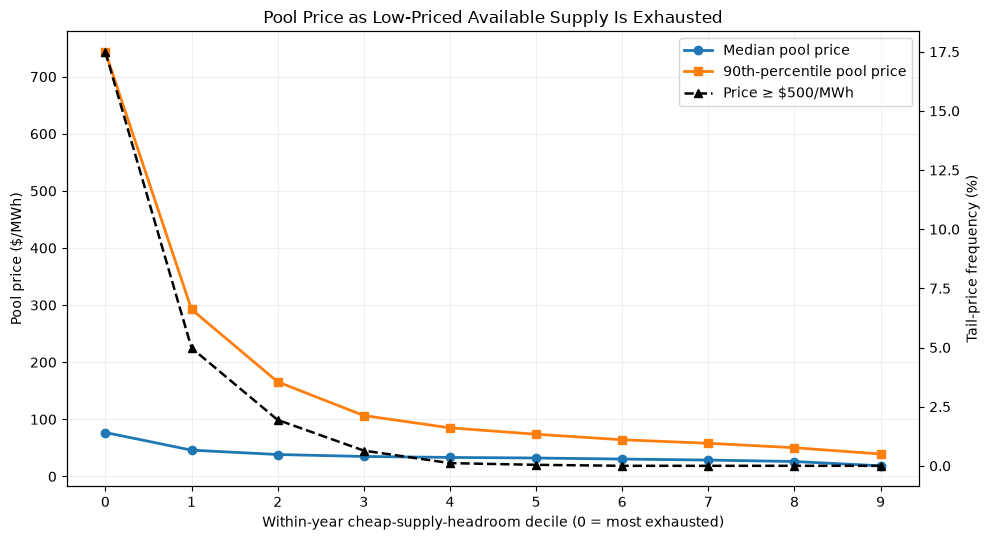

In [43]:
# ---------------------------------------------------------------------
# Visualize the merit-order exhaustion relationship
# ---------------------------------------------------------------------

fig, ax_price = plt.subplots(figsize=(10, 5.5))
ax_tail = ax_price.twinx()

ax_price.plot(offer_decile_summary.index, offer_decile_summary["median_pool_price"], marker="o", linewidth=2, label="Median pool price")
ax_price.plot(offer_decile_summary.index, offer_decile_summary["pool_price_90th_percentile"], marker="s", linewidth=2, label="90th-percentile pool price")
ax_tail.plot(
    offer_decile_summary.index, offer_decile_summary["tail_price_rate_pct"],
    color="black", marker="^", linestyle="--", linewidth=1.8,
    label=f"Price ≥ ${TAIL_PRICE_THRESHOLD}/MWh",
)

ax_price.set(
    title="Pool Price as Low-Priced Available Supply Is Exhausted",
    xlabel="Within-year cheap-supply-headroom decile (0 = most exhausted)",
    ylabel="Pool price ($/MWh)", xticks=range(10),
)
ax_tail.set_ylabel("Tail-price frequency (%)")
ax_price.grid(alpha=0.20)

price_handles, price_labels = ax_price.get_legend_handles_labels()
tail_handles, tail_labels = ax_tail.get_legend_handles_labels()
ax_price.legend(price_handles + tail_handles, price_labels + tail_labels, loc="upper right")

plt.tight_layout()
plt.show()

#### 7.3 

Pool prices rise sharply as low-priced available supply is exhausted. In the most exhausted within-year decile, cheap-supply headroom averages **−191 MW**, compared with more than **2,100 MW** in the most abundant decile. Median pool price rises from **$18.60/MWh** to **$76.91/MWh** across these endpoints.

The relationship is much stronger in the upper tail. The 90th-percentile pool price increases from **$39.30/MWh** in the most abundant decile to **$743.14/MWh** in the most exhausted decile. Hours above **$500/MWh** are essentially absent from deciles 6–9, but reach **17.49%** of hours in decile 0.

The steepest change occurs near the exhausted end of the stack rather than uniformly across all deciles. This is consistent with a nonlinear price response as the system moves through its remaining low-priced offers and increasingly relies on higher-priced supply.

### 7.4 Annual Stability

A pooled relationship can be produced by structural change rather than a stable within-period mechanism. The following heatmap therefore reports tail-price lift by year and within-year cheap-headroom decile.

Lift is the cell's tail-price rate divided by that year's overall tail-price rate. Values above one indicate greater-than-normal tail-price frequency for that year.

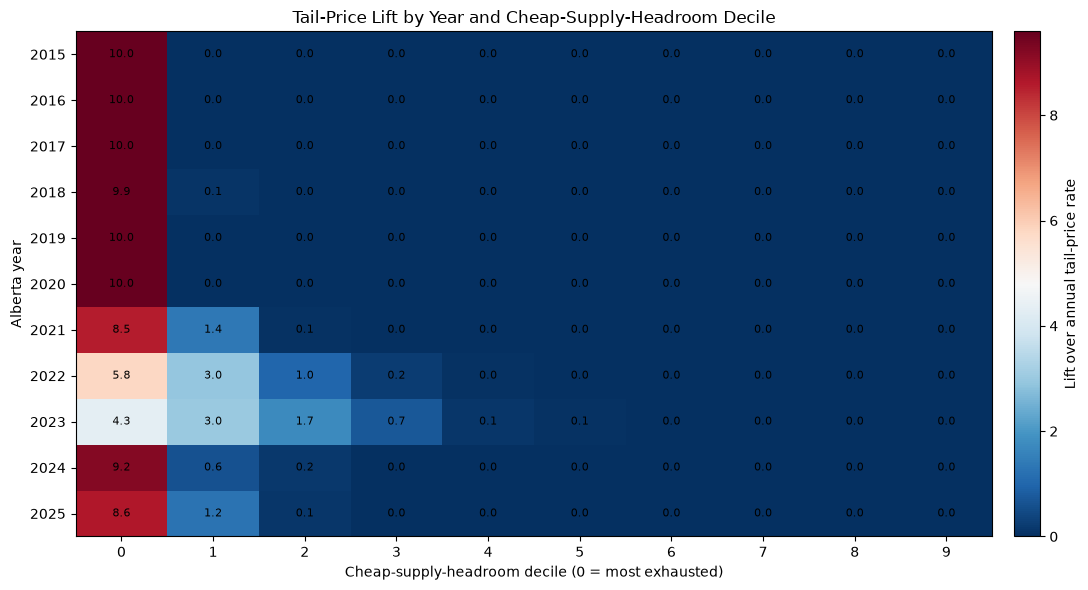

In [44]:
# ---------------------------------------------------------------------
# Test annual stability using tail-price lift
# ---------------------------------------------------------------------

annual_offer_summary = (
    offer_decile_frame.groupby(["year_alberta", "cheap_headroom_decile"], observed=True)
    .agg(
        hours=("pool_price", "size"),
        days=("local_date", "nunique"),
        tail_price_rate=("tail_price_hour", "mean"),
    )
    .reset_index()
)

annual_tail_base_rate = offer_decile_frame.groupby("year_alberta")["tail_price_hour"].mean().rename("annual_tail_base_rate")

annual_offer_summary = annual_offer_summary.merge(
    annual_tail_base_rate, on="year_alberta", how="left", validate="many_to_one",
)
annual_offer_summary["tail_price_lift"] = annual_offer_summary["tail_price_rate"] / annual_offer_summary["annual_tail_base_rate"].replace(0, np.nan)
annual_offer_summary["supported"] = annual_offer_summary["hours"].ge(MINIMUM_CELL_HOURS) & annual_offer_summary["days"].ge(MINIMUM_CELL_DAYS)

annual_offer_lift_matrix = (
    annual_offer_summary.loc[annual_offer_summary["supported"]]
    .pivot(index="year_alberta", columns="cheap_headroom_decile", values="tail_price_lift")
    .reindex(index=sorted(master["year_alberta"].unique()), columns=range(10))
)

fig, ax = plt.subplots(figsize=(12, 6))
image = ax.imshow(
    annual_offer_lift_matrix, aspect="auto", cmap="RdBu_r",
    vmin=0, vmax=np.nanquantile(annual_offer_lift_matrix.to_numpy(), 0.95),
)

for row, year in enumerate(annual_offer_lift_matrix.index):
    for col, decile in enumerate(annual_offer_lift_matrix.columns):
        value = annual_offer_lift_matrix.loc[year, decile]
        if pd.notna(value):
            ax.text(col, row, f"{value:.1f}", ha="center", va="center", fontsize=8)

ax.set(
    title="Tail-Price Lift by Year and Cheap-Supply-Headroom Decile",
    xlabel="Cheap-supply-headroom decile (0 = most exhausted)",
    ylabel="Alberta year",
    xticks=range(10),
    yticks=range(len(annual_offer_lift_matrix.index)),
)
ax.set_xticklabels(range(10))
ax.set_yticklabels(annual_offer_lift_matrix.index)

colorbar = fig.colorbar(image, ax=ax, pad=0.02)
colorbar.set_label("Lift over annual tail-price rate")

plt.tight_layout()
plt.show()

In [45]:
# ---------------------------------------------------------------------
# Quantify direction consistency across years
# ---------------------------------------------------------------------

annual_endpoint_comparison = (
    annual_offer_summary.loc[
        annual_offer_summary["cheap_headroom_decile"].isin([0, 9])
        & annual_offer_summary["supported"]
    ]
    .pivot(
        index="year_alberta",
        columns="cheap_headroom_decile",
        values=["tail_price_rate", "tail_price_lift"],
    )
    .dropna()
)

annual_endpoint_comparison["most_exhausted_has_higher_tail_rate"] = (
    annual_endpoint_comparison[("tail_price_rate", 0)]
    > annual_endpoint_comparison[("tail_price_rate", 9)]
)

expected_direction = annual_endpoint_comparison["most_exhausted_has_higher_tail_rate"]

direction_consistency = pd.DataFrame([{
    "comparable_years": len(annual_endpoint_comparison),
    "years_with_expected_direction": int(expected_direction.sum()),
    "direction_consistency_pct": expected_direction.mean() * 100,
    "median_decile_0_tail_lift": annual_endpoint_comparison[("tail_price_lift", 0)].median(),
    "median_decile_9_tail_lift": annual_endpoint_comparison[("tail_price_lift", 9)].median(),
}])

display(direction_consistency.round(2))

,comparable_years,years_with_expected_direction,direction_consistency_pct,median_decile_0_tail_lift,median_decile_9_tail_lift
0,11,11,100.0,9.9,0.0


#### 7.4

The relationship between cheap-supply exhaustion and extreme prices is stable across the full study period. In **all 11 years**, the most exhausted headroom decile has a higher tail-price rate than the most abundant decile.

The concentration of extreme prices in decile 0 is particularly strong. Its median annual tail-price lift is **9.9×** the corresponding annual base rate, while the most abundant decile records essentially no tail-price exposure.

The strength of the relationship varies by market regime. Tail-price risk spreads further into deciles 1–3 during 2021–2023, while most other years concentrate almost entirely in decile 0. Despite this variation, the direction of the relationship does not reverse in any year.

### 7.5 Conditional Relationship Within Comparable Physical States

Cheap-supply headroom is related to overall system tightness, so its pooled association with price is not necessarily incremental.

The next comparison conditions on the available-margin state already constructed earlier in the notebook. It asks whether merit-order exhaustion still separates price outcomes among hours with broadly similar physical margins.

This remains a stratified descriptive comparison rather than a causal estimate.

In [46]:
# ---------------------------------------------------------------------
# Compare merit-order exhaustion within margin states
# ---------------------------------------------------------------------

conditional_offer_frame = pd.DataFrame({
    "margin_state": price_features["margin_state"],
    "cheap_headroom_state": offer_features["cheap_headroom_state"],
    "local_date": master["local_date"],
    "pool_price": master["pool_price"],
    "tail_price_hour": offer_features["tail_price_hour"],
}).dropna()

conditional_offer_summary = (
    conditional_offer_frame
    .groupby(["margin_state", "cheap_headroom_state"], observed=True)
    .agg(
        hours=("pool_price", "size"),
        days=("local_date", "nunique"),
        median_pool_price=("pool_price", "median"),
        pool_price_90th_percentile=("pool_price", lambda s: s.quantile(0.90)),
        tail_price_rate_pct=("tail_price_hour", lambda s: s.mean() * 100),
    )
    .reset_index()
)

conditional_offer_summary["supported"] = (
    conditional_offer_summary["hours"].ge(MINIMUM_CELL_HOURS)
    & conditional_offer_summary["days"].ge(MINIMUM_CELL_DAYS)
)

display(conditional_offer_summary.round(2))

,margin_state,cheap_headroom_state,hours,days,median_pool_price,pool_price_90th_percentile,tail_price_rate_pct,supported
0,Critical,Most exhausted,2655,519,78.15,812.50,22.00,True
1,Critical,Middle,1959,465,38.04,105.34,1.17,True
2,Critical,Most abundant,204,68,42.52,60.85,0.00,True
3,Tight,Most exhausted,5334,1235,57.89,564.12,11.57,True
4,Tight,Middle,8181,1577,35.39,88.63,0.82,True
5,Tight,Most abundant,946,296,30.88,59.78,0.00,True
6,Balanced,Most exhausted,10134,2053,53.63,466.69,9.15,True
7,Balanced,Middle,38587,3812,32.80,80.21,0.44,True
8,Balanced,Most abundant,9136,1970,24.83,47.10,0.00,True
9,Loose,Most exhausted,1156,358,54.49,258.48,3.20,True


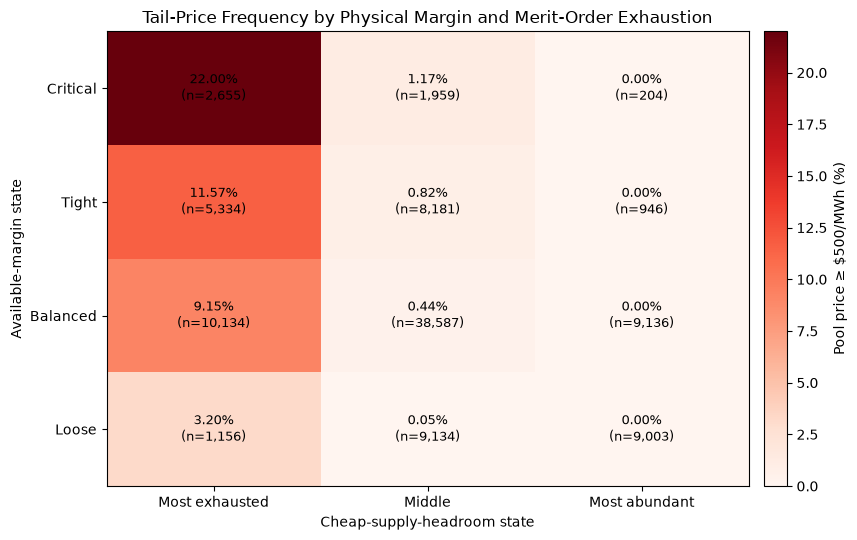

In [47]:
# ---------------------------------------------------------------------
# Visualize conditional tail-price frequency and sample size
# ---------------------------------------------------------------------

conditional_rate_matrix = (
    conditional_offer_summary.loc[conditional_offer_summary["supported"]]
    .pivot(index="margin_state", columns="cheap_headroom_state", values="tail_price_rate_pct")
    .reindex(index=MARGIN_STATE_ORDER, columns=CHEAP_HEADROOM_STATE_ORDER)
)

conditional_count_matrix = (
    conditional_offer_summary
    .pivot(index="margin_state", columns="cheap_headroom_state", values="hours")
    .reindex(index=MARGIN_STATE_ORDER, columns=CHEAP_HEADROOM_STATE_ORDER)
)

fig, ax = plt.subplots(figsize=(9, 5.5))
image = ax.imshow(conditional_rate_matrix, aspect="auto", cmap="Reds")

for row, margin_state in enumerate(conditional_rate_matrix.index):
    for col, headroom_state in enumerate(conditional_rate_matrix.columns):
        rate = conditional_rate_matrix.loc[margin_state, headroom_state]
        hours = conditional_count_matrix.loc[margin_state, headroom_state]
        if pd.notna(rate):
            ax.text(col, row, f"{rate:.2f}%\n(n={hours:,.0f})", ha="center", va="center", fontsize=9)

ax.set(
    title="Tail-Price Frequency by Physical Margin and Merit-Order Exhaustion",
    xlabel="Cheap-supply-headroom state",
    ylabel="Available-margin state",
    xticks=range(len(CHEAP_HEADROOM_STATE_ORDER)),
    yticks=range(len(MARGIN_STATE_ORDER)),
)
ax.set_xticklabels(CHEAP_HEADROOM_STATE_ORDER)
ax.set_yticklabels(MARGIN_STATE_ORDER)

colorbar = fig.colorbar(image, ax=ax, pad=0.02)
colorbar.set_label(f"Pool price ≥ ${TAIL_PRICE_THRESHOLD}/MWh (%)")

plt.tight_layout()
plt.show()

#### 7.5 

Cheap-supply exhaustion remains strongly associated with high prices after conditioning on physical available margin. Within every margin state, the most exhausted offer-stack hours have substantially higher prices and tail-price frequencies than middle or abundant-headroom hours.

The distinction is strongest under already tight system conditions. Tail-price frequency reaches **22.00%** when the physical margin is critical and cheap supply is most exhausted, compared with **1.17%** in the middle headroom state and **0%** when cheap supply is most abundant. Under tight margins, the corresponding rates are **11.57%**, **0.82%**, and **0%**.

The same ordering persists even when the physical system is balanced or loose. Most-exhausted hours retain tail-price rates of **9.15%** and **3.20%**, respectively, while abundant-headroom hours record no $500/MWh events in any margin state.

Physical tightness and offer-stack exhaustion therefore capture related but distinct dimensions of market state. Available margin describes the quantity of remaining physical supply, while cheap-supply headroom adds information about where dispatch sits within the price structure of that supply.

### 7.6 Offer Control and Concentration

The offer-control HHI measures concentration in available merit-order volume across reported offer-control parties.

It is not a finding of market power, withholding, or misconduct. A concentrated offer stack may reflect ownership structure, outages, asset availability, technology mix, imports, or other market conditions.

To reduce confounding, high- and low-concentration observations are compared within the same structural regime, margin state, and cheap-headroom state. The result should be described as conditional association only.

In [48]:
# ---------------------------------------------------------------------
# Compare low and high offer concentration in matched state cells
# ---------------------------------------------------------------------

concentration_frame = pd.DataFrame({
    "structural_regime": structural_regime,
    "margin_state": price_features["margin_state"],
    "cheap_headroom_state": offer_features["cheap_headroom_state"],
    "hhi_state": offer_features["offer_control_hhi_state"],
    "local_date": master["local_date"],
    "pool_price": master["pool_price"],
    "tail_price_hour": offer_features["tail_price_hour"],
}).dropna()

concentration_cells = (
    concentration_frame
    .groupby(["structural_regime", "margin_state", "cheap_headroom_state", "hhi_state"], observed=True)
    .agg(
        hours=("pool_price", "size"),
        days=("local_date", "nunique"),
        median_pool_price=("pool_price", "median"),
        tail_price_rate_pct=("tail_price_hour", lambda s: s.mean() * 100),
    )
    .reset_index()
)

match_keys = ["structural_regime", "margin_state", "cheap_headroom_state"]
metrics = ["hours", "days", "median_pool_price", "tail_price_rate_pct"]

low_concentration = (
    concentration_cells.loc[concentration_cells["hhi_state"].eq("Low concentration")]
    .drop(columns="hhi_state")
    .rename(columns={c: f"low_hhi_{c}" for c in metrics})
)

high_concentration = (
    concentration_cells.loc[concentration_cells["hhi_state"].eq("High concentration")]
    .drop(columns="hhi_state")
    .rename(columns={c: f"high_hhi_{c}" for c in metrics})
)

matched_concentration_cells = (
    low_concentration
    .merge(high_concentration, on=match_keys, how="inner", validate="one_to_one")
    .loc[lambda df:
        df["low_hhi_hours"].ge(MINIMUM_MATCHED_CELL_HOURS)
        & df["high_hhi_hours"].ge(MINIMUM_MATCHED_CELL_HOURS)
    ]
    .copy()
)

matched_concentration_cells["median_price_difference_high_minus_low"] = (
    matched_concentration_cells["high_hhi_median_pool_price"]
    - matched_concentration_cells["low_hhi_median_pool_price"]
)

matched_concentration_cells["tail_rate_difference_high_minus_low"] = (
    matched_concentration_cells["high_hhi_tail_price_rate_pct"]
    - matched_concentration_cells["low_hhi_tail_price_rate_pct"]
)

concentration_regime_summary = (
    matched_concentration_cells
    .groupby("structural_regime", observed=True)
    .agg(
        matched_state_cells=("median_price_difference_high_minus_low", "size"),
        median_price_difference=("median_price_difference_high_minus_low", "median"),
        median_tail_rate_difference_pct_points=("tail_rate_difference_high_minus_low", "median"),
        cells_with_higher_price_under_high_hhi=("median_price_difference_high_minus_low", lambda s: s.gt(0).mean() * 100),
    )
    .reindex(STRUCTURAL_REGIME_ORDER)
)

display(concentration_regime_summary.round(3))

,matched_state_cells,median_price_difference,median_tail_rate_difference_pct_points,cells_with_higher_price_under_high_hhi
structural_regime,,,,
Coal-dominant,9,-0.25,0.000,22.222
Coal-to-gas transition,9,-0.01,0.000,44.444
Late coal exit and renewable buildout,11,-0.45,-2.201,45.455
Coal-free gas-renewable system,9,4.30,0.000,77.778


#### 7.6

Offer-control concentration shows little consistent relationship with price once structural regime, physical margin, and cheap-supply-headroom state are held approximately constant.

In the coal-dominant, coal-to-gas transition, and late coal-exit regimes, high-HHI cells do not systematically produce higher prices. Median high-minus-low concentration price differences are close to zero or slightly negative, and fewer than half of matched cells have higher prices under high concentration.

The coal-free gas-renewable regime is different. High-concentration states have a **$4.30/MWh** higher median price, with higher prices in **77.8%** of matched cells. The short history of this regime and the absence of a corresponding median increase in $500/MWh tail frequency make this suggestive rather than conclusive.

Overall, offer-control HHI is retained as market-structure context rather than evidence that concentration independently drives high prices.

### 7.7 Revisiting the $60/MWh–$120/MWh Comparison

The existing price-band comparison established that only a small part of the difference is associated with the selected gas fuel-cost benchmark.

The merit-order extension asks whether the higher-price band also exhibits:

- less low-priced supply remaining above dispatch;
- a higher upper portion of the available offer stack;
- a tighter position within the recorded merit order;
- more intra-hour marginal-price movement;
- different offer-control concentration; or
- different reserve-offer conditions.

This table extends the existing comparison and should replace, rather than duplicate, a second narrative discussion of the same price bands.

In [49]:
# ---------------------------------------------------------------------
# Extend the price-band comparison with offer-stack evidence
# ---------------------------------------------------------------------

price_band_offer_frame = pd.DataFrame({
    "price_band": price_comparison_group,
    "pool_price": master["pool_price"],
    "cheap_supply_headroom_100_mw": offer_features["cheap_supply_headroom_100_mw"],
    "merit_residual_supply_mw": offer_features["merit_residual_supply_mw"],
    "merit_utilization_pct": offer_features["merit_utilization_pct"],
    "available_offer_price_p90": master["aeso_merit_available_price_p90"],
    "offer_control_hhi": master["aeso_merit_offer_control_hhi"],
    "smp_range_cad_mwh": offer_features["smp_range_cad_mwh"],
    "smp_interval_count": master["aeso_smp_interval_count"],
    "active_reserve_volume_mw": master["aeso_or_active_volume_mw"],
    "active_reserve_price": master["aeso_or_active_price_weighted_mean"],
}).dropna(subset=["price_band"])

price_band_offer_summary = (
    price_band_offer_frame
    .groupby("price_band", observed=True)
    .agg(
        hours=("pool_price", "size"),
        average_pool_price=("pool_price", "mean"),
        average_cheap_supply_headroom_mw=("cheap_supply_headroom_100_mw", "mean"),
        average_merit_residual_supply_mw=("merit_residual_supply_mw", "mean"),
        average_merit_utilization_pct=("merit_utilization_pct", "mean"),
        median_available_offer_price_p90=("available_offer_price_p90", "median"),
        average_offer_control_hhi=("offer_control_hhi", "mean"),
        median_smp_range_cad_mwh=("smp_range_cad_mwh", "median"),
        average_smp_interval_count=("smp_interval_count", "mean"),
        average_active_reserve_volume_mw=("active_reserve_volume_mw", "mean"),
        median_active_reserve_price=("active_reserve_price", "median"),
    )
    .reindex(PRICE_COMPARISON_ORDER)
)

display(price_band_offer_summary.round(3))

,hours,average_pool_price,average_cheap_supply_headroom_mw,average_merit_residual_supply_mw,average_merit_utilization_pct,median_available_offer_price_p90,average_offer_control_hhi,median_smp_range_cad_mwh,average_smp_interval_count,average_active_reserve_volume_mw,median_active_reserve_price
price_band,,,,,,,,,,,
$50–$70/MWh,9274,58.797,332.300,1567.342,87.782,86.390,0.046,7.135,4.138,636.152,-84.781
$110–$130/MWh,1180,119.053,-147.267,1232.953,90.524,109.765,0.045,65.03,4.425,643.751,-104.470


### Revisiting the $60/MWh–$120/MWh Price Difference

The offer stack provides a clearer distinction between the two price states identified in Notebook 3. Hours around **$120/MWh** occur with substantially less low-priced supply remaining: average cheap-supply headroom falls from **332 MW** in the $50–$70/MWh band to **−147 MW** in the $110–$130/MWh band. Merit-order utilization also rises from **87.8%** to **90.5%**, while residual available supply falls by roughly **334 MW**.

The price structure of the remaining stack changes as well. The median 90th-percentile available offer rises from **$86.39/MWh** to **$109.77/MWh**, while the median intra-hour SMP range increases sharply from **$7.14/MWh** to **$65.03/MWh**.

Offer-control concentration and reserve volume are nearly unchanged between the two groups. The comparison therefore points primarily toward deeper merit-order exhaustion and a more expensive, volatile marginal portion of the energy stack rather than a broad change in concentration or reserve procurement.

### 7.8 Offer-Stack Conditions Around High-Price Onset

Event alignment examines whether offer-stack conditions deteriorate before the first hour of a high-price episode, change primarily during the event, or merely reflect the same-hour price outcome.

Events beginning within 24 hours of an earlier selected onset are omitted to reduce overlapping windows. The resulting profiles report medians and interquartile ranges across events.

These trajectories are descriptive. They do not establish that a variable was known before the event or could have generated an operational warning.

In [50]:
# ---------------------------------------------------------------------
# Construct non-overlapping high-price onset windows
# ---------------------------------------------------------------------

event_source = pd.DataFrame({
    "timestamp_utc": master["timestamp_utc"],
    "pool_price": master["pool_price"],
    "cheap_supply_headroom_100_mw": offer_features["cheap_supply_headroom_100_mw"],
    "merit_available_price_p90": master["aeso_merit_available_price_p90"],
    "offer_control_hhi": master["aeso_merit_offer_control_hhi"],
    "smp_range_cad_mwh": offer_features["smp_range_cad_mwh"],
    "active_reserve_price": master["aeso_or_active_price_weighted_mean"],
}).set_index("timestamp_utc")

tail_state = event_source["pool_price"].ge(TAIL_PRICE_THRESHOLD)
candidate_onsets = event_source.index[tail_state & ~tail_state.shift(1, fill_value=False)]

selected_onsets = []
for onset in candidate_onsets:
    if not selected_onsets or onset - selected_onsets[-1] >= pd.Timedelta(hours=MINIMUM_EVENT_SEPARATION_HOURS):
        selected_onsets.append(onset)

event_rows = []
for event_id, onset in enumerate(selected_onsets, start=1):
    for offset in range(-EVENT_WINDOW_HOURS, EVENT_WINDOW_HOURS + 1):
        timestamp = onset + pd.Timedelta(hours=offset)
        if timestamp not in event_source.index:
            continue

        row = event_source.loc[timestamp].to_dict()
        row.update({"event_id": event_id, "event_onset_utc": onset, "relative_hour": offset})
        event_rows.append(row)

offer_event_panel = pd.DataFrame(event_rows)

print(f"Selected high-price onsets: {len(selected_onsets):,}")
print(f"Event-window observations: {len(offer_event_panel):,}")

Selected high-price onsets: 467
Event-window observations: 11,675


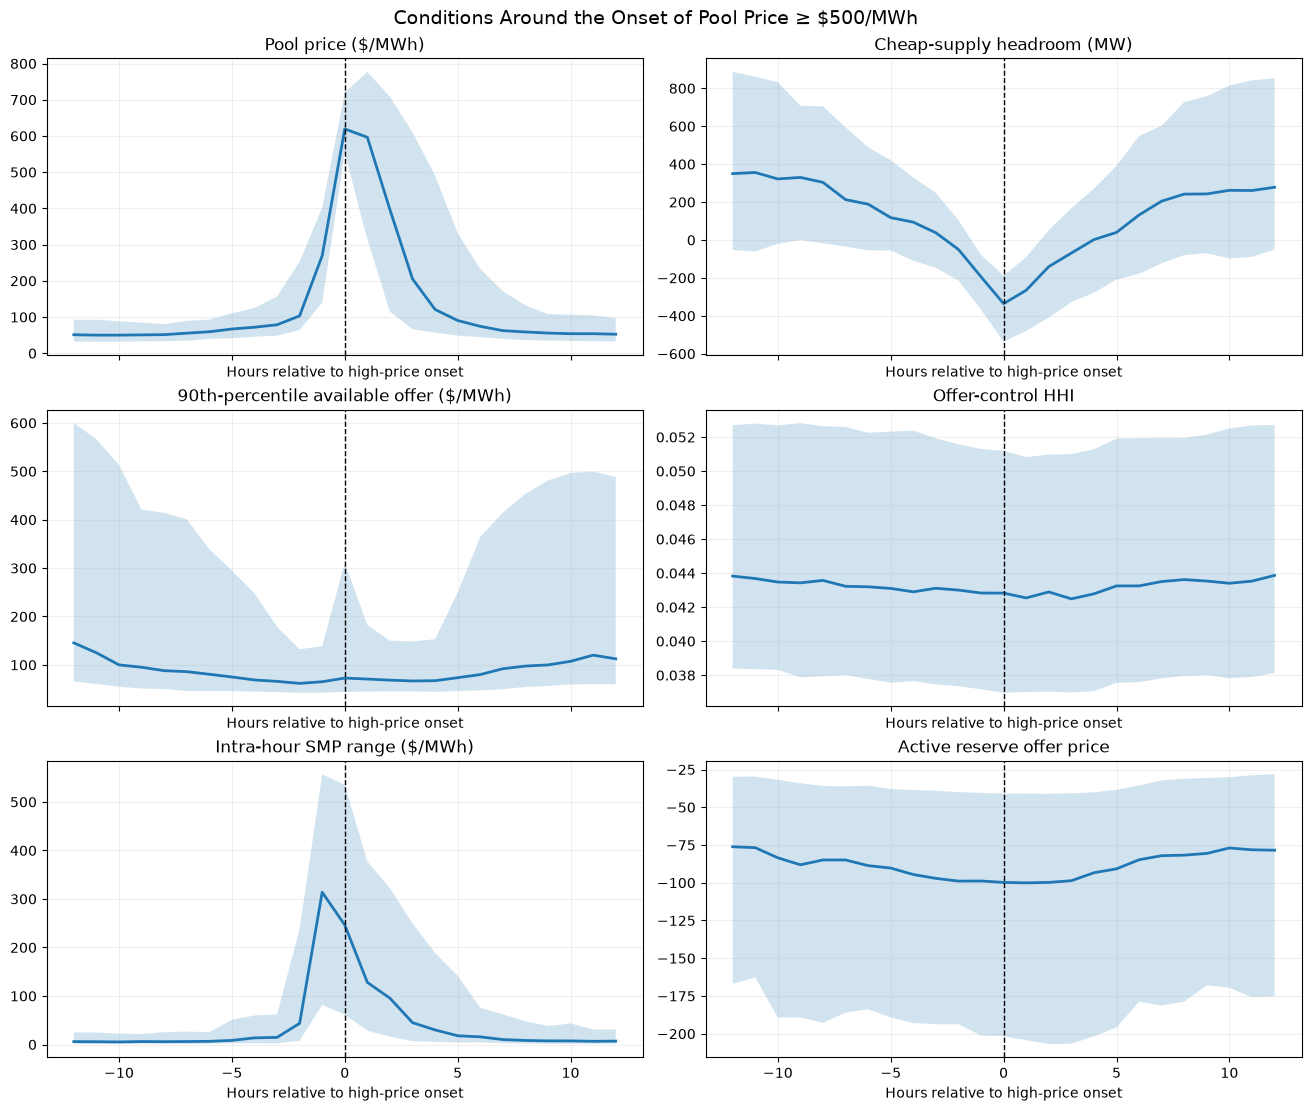

In [51]:
# ---------------------------------------------------------------------
# Plot event-aligned medians and interquartile ranges
# ---------------------------------------------------------------------

EVENT_PROFILE_COLUMNS = {
    "pool_price": "Pool price ($/MWh)",
    "cheap_supply_headroom_100_mw": "Cheap-supply headroom (MW)",
    "merit_available_price_p90": "90th-percentile available offer ($/MWh)",
    "offer_control_hhi": "Offer-control HHI",
    "smp_range_cad_mwh": "Intra-hour SMP range ($/MWh)",
    "active_reserve_price": "Active reserve offer price",
}

fig, axes = plt.subplots(3, 2, figsize=(13, 11), sharex=True, constrained_layout=True)

for ax, (column, label) in zip(axes.flat, EVENT_PROFILE_COLUMNS.items()):
    profile = offer_event_panel.groupby("relative_hour")[column].agg(
        median="median",
        lower=lambda s: s.quantile(0.25),
        upper=lambda s: s.quantile(0.75),
        observations="count",
    )

    ax.plot(profile.index, profile["median"], linewidth=2)
    ax.fill_between(profile.index, profile["lower"], profile["upper"], alpha=0.20)
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set(title=label, xlabel="Hours relative to high-price onset")
    ax.grid(alpha=0.20)

fig.suptitle(f"Conditions Around the Onset of Pool Price ≥ ${TAIL_PRICE_THRESHOLD}/MWh", fontsize=14)
plt.show()

### Conditions Around High-Price Onset

Across **467 non-overlapping high-price onsets**, cheap-supply headroom compresses steadily in the hours leading into the event. Median headroom falls from several hundred MW roughly 12 hours beforehand to about **−330 MW** at onset, before recovering over the following hours.

Pool-price escalation is accompanied by a sharp increase in intra-hour marginal-price volatility. The median SMP range begins rising immediately before onset, peaks above **$300/MWh** just before the $500/MWh threshold is crossed, and then declines rapidly afterward.

Other offer-stack measures move much less. The median 90th-percentile available offer remains relatively stable around onset, while offer-control HHI shows no comparable increase. Reserve offer prices also change gradually rather than displaying a discrete onset response.

The event profile therefore reinforces the decile results: high-price episodes are characterized most clearly by the **exhaustion of low-priced available supply and abrupt marginal-price movement**, rather than a contemporaneous jump in overall offer concentration or the upper portion of the available offer distribution.

### 7.9 Operating-Reserve Context

Operating-reserve offer prices and volumes describe a related but distinct market. They may respond to scarcity, opportunity cost, procurement requirements, and the composition of available assets.

The analysis therefore tests whether reserve-offer conditions coincide with expensive energy-market outcomes, but does not interpret the relationship as an independent causal effect.

In [52]:
# ---------------------------------------------------------------------
# Examine energy prices across reserve-price deciles
# ---------------------------------------------------------------------

offer_features["active_reserve_price_percentile_within_year"] = within_year_percentile(master["aeso_or_active_price_weighted_mean"])
offer_features["active_reserve_price_decile"] = percentile_to_decile(offer_features["active_reserve_price_percentile_within_year"])

reserve_decile_frame = pd.DataFrame({
    "year_alberta": master["year_alberta"], "local_date": master["local_date"],
    "reserve_price_decile": offer_features["active_reserve_price_decile"],
    "active_reserve_price": master["aeso_or_active_price_weighted_mean"],
    "active_reserve_volume_mw": master["aeso_or_active_volume_mw"],
    "standby_reserve_volume_mw": master["aeso_or_standby_volume_mw"],
    "pool_price": master["pool_price"], "tail_price_hour": offer_features["tail_price_hour"],
}).dropna()

reserve_decile_summary = (
    reserve_decile_frame
    .groupby("reserve_price_decile", observed=True)
    .agg(
        hours=("pool_price", "size"), days=("local_date", "nunique"),
        average_active_reserve_price=("active_reserve_price", "mean"),
        average_active_reserve_volume_mw=("active_reserve_volume_mw", "mean"),
        average_standby_reserve_volume_mw=("standby_reserve_volume_mw", "mean"),
        median_pool_price=("pool_price", "median"),
        pool_price_90th_percentile=("pool_price", lambda s: s.quantile(0.90)),
        tail_price_rate_pct=("tail_price_hour", lambda s: s.mean() * 100),
    )
)

display(reserve_decile_summary.round(2))

,hours,days,average_active_reserve_price,average_active_reserve_volume_mw,average_standby_reserve_volume_mw,median_pool_price,pool_price_90th_percentile,tail_price_rate_pct
reserve_price_decile,,,,,,,,
0,9629,726,-178.43,625.47,170.24,35.85,166.27,4.13
1,9649,860,-115.45,630.45,170.08,35.60,124.70,3.29
2,9638,979,-93.97,641.25,172.83,33.26,130.81,3.23
3,9656,1024,-73.58,633.59,171.57,34.62,138.56,3.25
4,9632,1126,-59.60,632.91,170.35,33.89,119.32,2.51
5,9659,1207,-50.57,628.73,169.75,32.96,96.17,2.01
6,9632,1280,-42.28,633.94,174.57,32.28,96.12,2.68
7,9643,1313,-34.28,636.60,174.94,30.93,83.79,1.47
8,9644,1327,-26.37,629.68,175.22,28.82,77.11,1.37


### Operating-Reserve Context

Reserve-price conditions do not show the same relationship with energy prices as merit-order exhaustion. Higher active-reserve offer prices are associated with **lower**, rather than higher, pool prices. Median pool price falls from **$35.85/MWh** in the lowest reserve-price decile to **$27.06/MWh** in the highest, while $500/MWh frequency declines from **4.13%** to **1.26%**.

Active and standby reserve volumes remain relatively stable across the deciles, suggesting that the pattern is not primarily driven by large changes in the quantity of reserve offers represented in each state.

The reserve-price relationship is therefore not evidence of reserve-market tightness independently amplifying energy prices. Reserve offers appear to capture a different set of operating and opportunity-cost conditions, and are retained as adjacent market context rather than a primary price-formation signal.

### 7.10 Unit Commitment: Limited Recent Evidence

The unit-commitment archive begins in July 2024 and contains relatively few directives. It cannot support a decade-wide stability conclusion.

The issued timestamp makes the data potentially useful for future forecasting work, but forecast eligibility still depends on constructing only information that had been issued before the forecast origin. Here, directives are used only as recent-period descriptive context.

In [53]:
# ---------------------------------------------------------------------
# Compare prices with and without unit-commitment activity
# ---------------------------------------------------------------------

commitment_coverage = master["aeso_unit_commitment_archive_available"].eq(1)

commitment_frame = pd.DataFrame({
    "pool_price": master.loc[commitment_coverage, "pool_price"],
    "tail_price_hour": offer_features.loc[commitment_coverage, "tail_price_hour"],
    "directives_issued": master.loc[commitment_coverage, "aeso_unit_commitment_directives_issued"].fillna(0),
    "active_directives": master.loc[commitment_coverage, "aeso_unit_commitment_active_directives"].fillna(0),
    "median_lead_hours": master.loc[commitment_coverage, "aeso_unit_commitment_median_lead_hours"],
})

commitment_frame["issued_state"] = np.where(commitment_frame["directives_issued"].gt(0), "Directive issued", "No directive issued")
commitment_frame["active_state"] = np.where(commitment_frame["active_directives"].gt(0), "Active directive", "No active directive")

commitment_comparisons = []

for state_column, comparison_name in {
    "issued_state": "Issued during hour",
    "active_state": "Active during hour",
}.items():
    summary = (
        commitment_frame.groupby(state_column)
        .agg(
            hours=("pool_price", "size"),
            median_pool_price=("pool_price", "median"),
            pool_price_90th_percentile=("pool_price", lambda s: s.quantile(0.90)),
            tail_price_rate_pct=("tail_price_hour", lambda s: s.mean() * 100),
            median_directive_lead_hours=("median_lead_hours", "median"),
        )
        .reset_index()
        .rename(columns={state_column: "state"})
    )
    summary.insert(0, "comparison", comparison_name)
    commitment_comparisons.append(summary)

commitment_summary = pd.concat(commitment_comparisons, ignore_index=True)
display(commitment_summary.round(2))

,comparison,state,hours,median_pool_price,pool_price_90th_percentile,tail_price_rate_pct,median_directive_lead_hours
0,Issued during hour,Directive issued,147,23.54,107.40,4.76,10.57
1,Issued during hour,No directive issued,13036,23.56,70.00,1.68,NaN
2,Active during hour,Active directive,606,53.26,641.60,12.87,0.16
3,Active during hour,No active directive,12577,23.08,63.12,1.18,11.46


### Unit-Commitment Context

Unit-commitment activity is associated with substantially different price conditions during the available July 2024–2025 archive. Hours in which a directive is issued have similar median prices to other hours, but a higher 90th-percentile price (**$107.40/MWh** versus **$70.00/MWh**) and a higher $500/MWh frequency (**4.76%** versus **1.68%**). Directives are typically issued well in advance, with a median lead time of **10.57 hours**.

The distinction becomes much stronger while directives are active. Median pool price rises from **$23.08/MWh** without an active directive to **$53.26/MWh** with one, while the 90th percentile rises from **$63.12/MWh** to **$641.60/MWh**. Tail-price frequency increases from **1.18%** to **12.87%**.

The short archive prevents a long-run stability test, but the timing is potentially useful: issuance occurs hours before the associated commitment becomes active. Unit-commitment directives are therefore retained as a recent-period sensitivity and a candidate for later forecast-origin feature construction.

### 7.11 Evidence Register

The evidence register records the mechanism, observed relationship, stability, information timing, redundancy, and final analytical role of each API driver family.

A variable can be useful for explaining historical price formation without being eligible for forecasting. Contemporaneous offer-stack, SMP, reserve, dispatch, and forecast-error fields must not enter an ex-ante model unless an appropriate historical publication vintage is available.

In [54]:
# ---------------------------------------------------------------------
# Create compact evidence metrics
# ---------------------------------------------------------------------

def decile_value(frame: pd.DataFrame, decile: int, column: str):
    return frame.loc[decile, column] if decile in frame.index else np.nan

cheap_tail_difference = decile_value(offer_decile_summary, 0, "tail_price_rate_pct") - decile_value(offer_decile_summary, 9, "tail_price_rate_pct")
cheap_median_price_difference = decile_value(offer_decile_summary, 0, "median_pool_price") - decile_value(offer_decile_summary, 9, "median_pool_price")
reserve_tail_difference = decile_value(reserve_decile_summary, 9, "tail_price_rate_pct") - decile_value(reserve_decile_summary, 0, "tail_price_rate_pct")
weighted_smp_row = price_reconciliation.set_index("measure").loc["Time-weighted mean SMP"]
direction_consistency_pct = direction_consistency["direction_consistency_pct"].iloc[0]

feature_evidence_register = pd.DataFrame([
    {
        "feature_family": "Cheap-supply headroom",
        "mechanism": "Position of dispatch relative to available supply priced at or below $100/MWh",
        "key_evidence": (
            f"Decile 0 minus decile 9 median-price difference: ${cheap_median_price_difference:,.2f}/MWh; "
            f"tail-rate difference: {cheap_tail_difference:,.2f} percentage points"
        ),
        "stability_result": f"Expected annual direction in {direction_consistency_pct:.1f}% of comparable years",
        "timing_status": "Contemporaneous, ex-post merit-order snapshot",
        "redundancy": "Related to margin and residual supply, but adds offer-price structure",
        "final_decision": "Retain as primary descriptive price-formation evidence",
    },
    {
        "feature_family": "Time-weighted SMP",
        "mechanism": "Intra-hour marginal prices underlying hourly settlement price",
        "key_evidence": f"Mean absolute pool-price difference: ${weighted_smp_row['mean_absolute_difference']:,.4f}/MWh",
        "stability_result": "Use annual reconciliation if discrepancies are material",
        "timing_status": "Realized within the target hour",
        "redundancy": "Nearly reconstructs the hourly pool-price outcome",
        "final_decision": "Retain for settlement validation; prohibit as same-hour predictor",
    },
    {
        "feature_family": "Offer-control concentration",
        "mechanism": "Concentration of available merit-order volume across offer-control parties",
        "key_evidence": "Compare high and low HHI within matched regime, margin, and stack states",
        "stability_result": "Reported by structural regime using matched cells",
        "timing_status": "Contemporaneous and delayed",
        "redundancy": "Correlated with market structure and available asset composition",
        "final_decision": "Conditional descriptive context; not a market-power conclusion",
    },
    {
        "feature_family": "Operating-reserve offers",
        "mechanism": "Reserve procurement and opportunity-cost conditions adjacent to the energy market",
        "key_evidence": f"Top-minus-bottom reserve-price-decile tail-rate difference: {reserve_tail_difference:,.2f} percentage points",
        "stability_result": "Require annual or regime comparison before retaining a strong claim",
        "timing_status": "Same-hour outcome with delayed public release",
        "redundancy": "May co-move with energy scarcity and asset opportunity cost",
        "final_decision": "Retain as conditional operating context",
    },
    {
        "feature_family": "Generation-capacity API",
        "mechanism": "Reported maximum and available capability by technology",
        "key_evidence": "Reconciled against existing canonical availability and outage measures",
        "stability_result": "Coverage changes for several technology categories",
        "timing_status": "Historical target-hour value without preserved vintage",
        "redundancy": "Substantial overlap with Notebook 2 availability variables",
        "final_decision": "Use for reconciliation and technology detail, not duplicate headline analysis",
    },
    {
        "feature_family": "Unit commitment",
        "mechanism": "Advance directives requiring selected assets to operate",
        "key_evidence": "Compare issued and active directive hours from July 2024 onward",
        "stability_result": "Insufficient history for decade-wide stability",
        "timing_status": "Issued timestamp potentially supports origin-safe construction",
        "redundancy": "Related to anticipated adequacy and thermal availability",
        "final_decision": "Retain as recent-period sensitivity and future forecasting candidate",
    },
])

display(feature_evidence_register)

,feature_family,mechanism,key_evidence,stability_result,timing_status,redundancy,final_decision
0,Cheap-supply headroom,Position of dispatch relative to available sup...,Decile 0 minus decile 9 median-price differenc...,Expected annual direction in 100.0% of compara...,"Contemporaneous, ex-post merit-order snapshot","Related to margin and residual supply, but add...",Retain as primary descriptive price-formation ...
1,Time-weighted SMP,Intra-hour marginal prices underlying hourly s...,Mean absolute pool-price difference: $0.0021/MWh,Use annual reconciliation if discrepancies are...,Realized within the target hour,Nearly reconstructs the hourly pool-price outcome,Retain for settlement validation; prohibit as ...
2,Offer-control concentration,Concentration of available merit-order volume ...,Compare high and low HHI within matched regime...,Reported by structural regime using matched cells,Contemporaneous and delayed,Correlated with market structure and available...,Conditional descriptive context; not a market-...
3,Operating-reserve offers,Reserve procurement and opportunity-cost condi...,Top-minus-bottom reserve-price-decile tail-rat...,Require annual or regime comparison before ret...,Same-hour outcome with delayed public release,May co-move with energy scarcity and asset opp...,Retain as conditional operating context
4,Generation-capacity API,Reported maximum and available capability by t...,Reconciled against existing canonical availabi...,Coverage changes for several technology catego...,Historical target-hour value without preserved...,Substantial overlap with Notebook 2 availabili...,"Use for reconciliation and technology detail, ..."
5,Unit commitment,Advance directives requiring selected assets t...,Compare issued and active directive hours from...,Insufficient history for decade-wide stability,Issued timestamp potentially supports origin-s...,Related to anticipated adequacy and thermal av...,Retain as recent-period sensitivity and future...


### 7.12 Interpretation and Evidence Boundary

The merit-order evidence substantially sharpens the price-formation results from Notebook 3. Expensive hours are systematically associated with deeper exhaustion of low-priced available supply. In the most exhausted within-year cheap-supply-headroom decile, median pool price reaches **$76.91/MWh**, the 90th percentile reaches **$743.14/MWh**, and **17.49%** of hours exceed $500/MWh. In the most abundant decile, the corresponding values are **$18.60/MWh**, **$39.30/MWh**, and effectively zero tail-price exposure. The relationship is strongly nonlinear, with most of the increase concentrated near the exhausted end of the stack.

This relationship is not simply another representation of physical available margin. Within every margin state, exhausted cheap supply is associated with substantially greater tail-price risk. Even under balanced margins, the most exhausted stack state records a **9.15%** $500/MWh rate, compared with **0%** when cheap supply is most abundant. Under critical margins, the corresponding rates are **22.00%** and **0%**. Physical adequacy and position within the offer stack therefore describe related but distinct dimensions of market tightness.

The direction is also stable through time. The most exhausted decile has a higher tail-price rate than the most abundant decile in **all 11 study years**, with a median annual tail-price lift of **9.9×** in decile 0. The strength and breadth of the relationship vary across structural regimes, particularly during 2021–2023, but its direction does not reverse.

Offer-control concentration provides much weaker conditional separation. After matching approximately on structural regime, physical margin, and cheap-supply-headroom state, higher HHI is not consistently associated with higher prices through the first three structural regimes. The coal-free gas-renewable period shows a stronger positive difference, with median prices **$4.30/MWh** higher under high concentration and higher prices in **77.8%** of matched cells, but the short history and lack of corresponding median tail-rate separation make this suggestive rather than evidence of market power.

Operating-reserve conditions also behave differently from the energy offer stack. Higher active-reserve offer-price deciles are associated with lower energy prices and lower tail-price frequencies, while reserve volumes remain comparatively stable. Reserve-market variables therefore provide useful adjacent operating context, but the current evidence does not support treating them as a primary driver of energy-market stress.

Unit-commitment activity is more informative despite its limited history. Directive issuance tends to precede commitment by roughly **10.6 hours**, while hours with active directives have a median pool price of **$53.26/MWh** and a **12.87%** $500/MWh rate, compared with **$23.08/MWh** and **1.18%** without an active directive. The archive begins only in mid-2024, so this cannot establish a stable long-run relationship, but the observed issuance timing makes unit commitment a useful candidate for later forecast-origin analysis.

The evidence also clarifies what the merit-order archive does **not** represent. The highest dispatched offer in the hourly snapshot does not reconstruct the hourly pool price; the time-weighted SMP does so almost exactly. Merit-order snapshots are therefore interpreted as observations of the available offer stack and dispatch position, while the intra-hour SMP sequence captures the marginal-price process underlying hourly settlement.

Overall, the merit-order archive provides the missing link between the physical and economic conditions identified earlier and the final market outcome:

**fuel costs and physical state → available offers → merit-order exhaustion → intra-hour marginal prices → hourly pool price**

Its strongest result is explanatory rather than causal or predictive. Low-priced supply exhaustion is a persistent and highly nonlinear marker of expensive market states, including after conditioning on physical margin. The contemporaneous merit-order, SMP, dispatch, and reserve fields remain ex-post observations and are not treated as forecast-safe inputs. Missing archive observations are excluded where required rather than interpreted as zero activity, and the shorter unit-commitment archive is kept separate from decade-wide conclusions.

### 6.2 Offer Behaviour, Marginal Units, and Market Rules

Offer behaviour belongs conceptually in Notebook 3 because offers determine how physical and fuel-cost conditions translate into pool price.

However, the current canonical dataset does not contain:

- asset-level offer blocks;
- merit-order position;
- the marginal price-setting unit;
- unit-specific heat rates;
- variable operations and maintenance costs;
- carbon-compliance costs;
- start and minimum-run costs; or
- a sourced chronology of market-rule changes.

Consequently, this notebook cannot directly estimate complete marginal cost, identify the price-setting asset, or attribute the price-cost wedge to strategic offer behaviour.

The following audit confirms whether any offer or marginal-unit fields have subsequently been added to the canonical master. If those data become available, this section can be expanded without changing the rest of the notebook.

In [55]:
# ---------------------------------------------------------------------
# Audit availability of direct offer and marginal-unit data
# ---------------------------------------------------------------------

OFFER_DATA_KEYWORDS = [
    "offer",
    "bid",
    "merit",
    "marginal_unit",
    "price_setter",
    "heat_rate",
    "variable_om",
    "carbon_cost",
]

direct_offer_columns = sorted([
    column
    for column in master.columns
    if any(
        keyword in column.lower()
        for keyword in OFFER_DATA_KEYWORDS
    )
])

offer_data_audit = pd.DataFrame([
    {
        "required_driver":
            "Asset-level offer blocks",
        "available_in_master":
            any(
                "offer" in column.lower()
                for column
                in direct_offer_columns
            ),
    },
    {
        "required_driver":
            "Marginal or price-setting unit",
        "available_in_master":
            any(
                (
                    "marginal_unit"
                    in column.lower()
                )
                or (
                    "price_setter"
                    in column.lower()
                )
                for column
                in direct_offer_columns
            ),
    },
    {
        "required_driver":
            "Unit-specific heat rates",
        "available_in_master":
            any(
                "heat_rate" in column.lower()
                for column
                in direct_offer_columns
            ),
    },
    {
        "required_driver":
            "Variable O&M or carbon cost",
        "available_in_master":
            any(
                (
                    "variable_om"
                    in column.lower()
                )
                or (
                    "carbon_cost"
                    in column.lower()
                )
                for column
                in direct_offer_columns
            ),
    },
])

print(
    "Potential direct economic columns:",
    direct_offer_columns
    if direct_offer_columns
    else "None",
)

display(offer_data_audit)

Potential direct economic columns: ['aeso_merit_asset_count', 'aeso_merit_available_mw', 'aeso_merit_available_mw_at_or_below_0', 'aeso_merit_available_mw_at_or_below_100', 'aeso_merit_available_mw_at_or_below_250', 'aeso_merit_available_mw_at_or_below_50', 'aeso_merit_available_mw_at_or_below_500', 'aeso_merit_available_price_p50', 'aeso_merit_available_price_p90', 'aeso_merit_available_price_weighted_mean', 'aeso_merit_block_count', 'aeso_merit_dispatched_mw', 'aeso_merit_dispatched_price_weighted_mean', 'aeso_merit_flexible_available_mw', 'aeso_merit_highest_dispatched_offer', 'aeso_merit_import_available_mw', 'aeso_merit_offer_control_hhi', 'aeso_merit_offer_controller_count', 'aeso_merit_order_archive_available', 'aeso_merit_total_block_mw', 'aeso_or_offer_controller_count']


,required_driver,available_in_master
0,Asset-level offer blocks,True
1,Marginal or price-setting unit,False
2,Unit-specific heat rates,False
3,Variable O&M or carbon cost,False


### Evidence Boundary

The absence of offer and marginal-unit data is a substantive result, not a reason to infer those mechanisms indirectly.

This notebook can establish:

- the scale of gas fuel costs;
- the relationship between gas prices and pool prices;
- how that relationship changes with system tightness;
- the magnitude of a fixed-benchmark price-cost wedge; and
- the operating conditions associated with different price levels.

It cannot establish:

- which asset set price;
- whether an observed offer was competitive;
- whether economic or physical withholding occurred;
- a unit’s complete marginal cost; or
- the causal effect of a market-rule change.

A sourced market-rule chronology and asset-level offer data would be required before those questions could be analyzed directly. Structural or rule periods must not be selected from price breakpoints.

## 7. Evidence Register

The evidence register converts Notebook 3’s empirical results into decisions for later forecasting work. It records not only each variable’s economic meaning, but also:

1. the observed relationship with pool price;
2. the shape and stability of that relationship;
3. the principal evidence produced by this notebook;
4. overlap with other variables;
5. whether the information would be available at the forecast origin; and
6. its final analytical or forecasting role.

Pooled relationships are distinguished from results tested separately by year. Contemporaneous operating outcomes are not treated as forecast eligible unless an equivalent ex-ante forecast can be constructed.

### 7.1 Empirical Evidence and Forecast Classification

In [56]:
# ---------------------------------------------------------------------
# Create the Notebook 3 evidence register
# ---------------------------------------------------------------------

evidence_register = pd.DataFrame([
    {
        "feature": "Natural-gas price",
        "mechanism": (
            "Input cost for gas-fired generation"
        ),
        "data_role": "Independent economic input",
        "observed_relationship": (
            "Positive but modest relationship with "
            "typical pool prices"
        ),
        "relationship_shape": (
            "Weak upward tendency concentrated in "
            "the highest gas-price decile; weaker "
            "for upper-tail prices"
        ),
        "stability_result": (
            "Annual decile-shape analysis shows a generally "
            "positive but uneven gas-price relationship across "
            "years; daily median-price correlations range from "
            "0.129 to 0.653"
        ),
        "key_evidence": (
            "Median daily price rises from "
            "$29.04/MWh in decile 0 to $40.40/MWh "
            "in decile 9"
        ),
        "conditional_on": (
            "Heat rate, structural regime, and "
            "physical system state"
        ),
        "redundant_with": pd.NA,
        "timing_status": (
            "Daily series; publication time and "
            "forecast vintage require confirmation"
        ),
        "forecast_eligibility": (
            "Potentially eligible after timing audit"
        ),
        "final_decision": (
            "Conditional retain pending "
            "forecast-origin timing audit"
        ),
    },
    {
        "feature": "Illustrative fuel-cost proxy",
        "mechanism": (
            "Gas price multiplied by an assumed "
            "heat rate"
        ),
        "data_role": "Transparent fuel-only benchmark",
        "observed_relationship": (
            "Tracks the gas-price cycle but remains "
            "well below pool price in many years"
        ),
        "relationship_shape": (
            "Deterministic linear transformation "
            "of gas price"
        ),
        "stability_result": (
            "All scenarios peak in 2022; results "
            "change mechanically with heat-rate "
            "assumption"
        ),
        "key_evidence": (
            "Annual median proxies range from "
            "$7.62–$30.90/MWh at 6.0 GJ/MWh and "
            "$15.24–$61.80/MWh at 12.0 GJ/MWh"
        ),
        "conditional_on": (
            "Selected heat rate; excludes carbon, "
            "variable O&M, starts, and constraints"
        ),
        "redundant_with": (
            "Natural-gas price under a fixed heat rate"
        ),
        "timing_status": (
            "Constructible from available or "
            "forecast gas-price information"
        ),
        "forecast_eligibility": "Benchmark only",
        "final_decision": (
            "Retain as a benchmark, not as multiple "
            "independent predictors"
        ),
    },
    {
        "feature": "Reported spark spread",
        "mechanism": (
            "Pool price minus 7.5 × gas price"
        ),
        "data_role": (
            "Target-derived outcome decomposition"
        ),
        "observed_relationship": (
            "Exactly equals the reference "
            "price-cost wedge"
        ),
        "relationship_shape": (
            "Deterministic function of pool price "
            "and gas price"
        ),
        "stability_result": (
            "Identity holds for all 96,425 "
            "observations"
        ),
        "key_evidence": (
            "Maximum absolute reconstruction error "
            "equals zero"
        ),
        "conditional_on": (
            "Fixed 7.5 GJ/MWh benchmark"
        ),
        "redundant_with": (
            "Reference price-cost wedge"
        ),
        "timing_status": (
            "Known only after contemporaneous pool "
            "price is observed"
        ),
        "forecast_eligibility": "Not eligible",
        "final_decision": (
            "Descriptive only; exclude from "
            "same-hour predictors"
        ),
    },
    {
        "feature": "Reference price-cost wedge",
        "mechanism": (
            "Pool price remaining after the "
            "7.5 GJ/MWh fuel-cost benchmark"
        ),
        "data_role": (
            "Target-derived outcome decomposition"
        ),
        "observed_relationship": (
            "Large and variable; increases strongly "
            "under critical conditions"
        ),
        "relationship_shape": (
            "Nonlinear and strongly conditional on "
            "physical operating state"
        ),
        "stability_result": (
            "Pooled relationship only; not an "
            "independent explanatory variable"
        ),
        "key_evidence": (
            "$55.15/MWh of the $60.26/MWh difference "
            "between the selected price bands remains "
            "in the wedge"
        ),
        "conditional_on": (
            "Margin, net load, outages, dispatch, "
            "offers, and omitted operating costs"
        ),
        "redundant_with": "Reported spark spread",
        "timing_status": (
            "Known only after pool price is observed"
        ),
        "forecast_eligibility": "Not eligible",
        "final_decision": (
            "Descriptive outcome only; do not "
            "interpret as profit or markup"
        ),
    },
    {
        "feature": "Available-margin state",
        "mechanism": (
            "Physical tightness conditioning variable"
        ),
        "data_role": "Notebook 2 physical context",
        "observed_relationship": (
            "Pool-price outcomes differ substantially "
            "across margin states at similar "
            "gas-price ranks"
        ),
        "relationship_shape": (
            "Weak gas-price gradient when loose; "
            "high and irregular prices when critical"
        ),
        "stability_result": (
            "Section 4.3 tests the relationship across "
            "market regimes; the conditioning effect of "
            "available margin persists but varies by regime"
        ),
        "key_evidence": (
            "At gas-price decile 9, median price is "
            "$76.59/MWh when critical versus "
            "$23.06/MWh when loose"
        ),
        "conditional_on": (
            "Structural regime, availability-data definition, "
            "and information timing"
        ),
        "redundant_with": (
            "Absolute available margin and related "
            "tightness measures"
        ),
        "timing_status": (
            "Contemporaneous reported state"
        ),
        "forecast_eligibility": (
            "Requires forecast-vintage availability"
        ),
        "final_decision": (
            "Retain as conditional context only"
        ),
    },
    {
        "feature": "Net load",
        "mechanism": (
            "Demand remaining after wind and solar "
            "generation"
        ),
        "data_role": "Notebook 2 physical context",
            "observed_relationship": (
            "Higher in the $110–$130/MWh price band and "
            "important in comparable-state analysis"
        ),
        "relationship_shape": (
            "Positive descriptive association that remains "
            "relevant when comparing similar physical states"
        ),
        "stability_result": (
            "Used in comparable-state analysis to control for "
            "system conditions; annual stability is not "
            "independently tested in Notebook 3"
        ),
        "key_evidence": (
            "Average net load rises from "
            "9,035.06 MW to 9,298.47 MW"
        ),
        "conditional_on": (
            "Load and variable renewable generation"
        ),
        "redundant_with": (
            "Load and renewable-generation inputs"
        ),
        "timing_status": (
            "Contemporaneous outcome; requires load "
            "and renewable forecasts"
        ),
        "forecast_eligibility": (
            "Eligible only in forecast-constructed form"
        ),
        "final_decision": (
            "Defer forecasting treatment to "
            "Notebooks 4 and 6–8"
        ),
    },
    {
        "feature": "Thermal headroom",
        "mechanism": (
            "Unused reported thermal availability"
        ),
        "data_role": "Notebook 2 physical context",
        "observed_relationship": (
            "Lower in the higher-price band"
        ),
        "relationship_shape": (
            "Inverse descriptive association"
        ),
        "stability_result": (
            "Single pooled price-band comparison; "
            "inherits technology-reporting caveats"
        ),
        "key_evidence": (
            "Average thermal headroom declines from "
            "3,631.20 MW to 3,276.84 MW"
        ),
        "conditional_on": (
            "Thermal availability, commitment, "
            "dispatch, and reporting coverage"
        ),
        "redundant_with": (
            "Thermal availability and generation"
        ),
        "timing_status": (
            "Realized contemporaneous operating state"
        ),
        "forecast_eligibility": (
            "Requires availability and dispatch "
            "forecasts"
        ),
        "final_decision": (
            "Retain as descriptive conditional context"
        ),
    },
    {
        "feature": "Total outages",
        "mechanism": "Unavailable generation capacity",
        "data_role": "Notebook 2 physical context",
        "observed_relationship": (
            "Moderately higher in the higher-price band"
        ),
        "relationship_shape": (
            "Positive descriptive association"
        ),
        "stability_result": (
            "Single pooled price-band comparison"
        ),
        "key_evidence": (
            "Average outages rise from 3,531.96 MW "
            "to 3,677.14 MW"
        ),
        "conditional_on": (
            "Fleet composition and outage-data vintage"
        ),
        "redundant_with": (
            "Availability and available-margin measures"
        ),
        "timing_status": (
            "Depends on when outage information "
            "became available"
        ),
        "forecast_eligibility": (
            "Conditional on forecast-vintage data"
        ),
        "final_decision": (
            "Retain as Notebook 2 context; timing "
            "audit required before modelling"
        ),
    },
    {
        "feature": "Observed net imports",
        "mechanism": (
            "External supply responding to Alberta "
            "system conditions"
        ),
        "data_role": "Contemporaneous system response",
        "observed_relationship": (
            "Higher in the higher-price band"
        ),
        "relationship_shape": (
            "Positive response to stressed conditions, "
            "not an independent causal driver"
        ),
        "stability_result": (
            "Single pooled comparison with incomplete "
            "2025 reporting"
        ),
        "key_evidence": (
            "Average net imports rise from 234.00 MW "
            "to 311.41 MW"
        ),
        "conditional_on": (
            "Domestic tightness, intertie capability, "
            "and regional prices"
        ),
        "redundant_with": (
            "Import capability and system tightness"
        ),
        "timing_status": (
            "Observed after dispatch and incomplete "
            "after July 2025"
        ),
        "forecast_eligibility": (
            "Requires a separate import forecast"
        ),
        "final_decision": "Descriptive only",
    },
    {
        "feature": "Gas-generation share",
        "mechanism": (
            "Intensity of gas-fleet dispatch"
        ),
        "data_role": (
            "Contemporaneous dispatch outcome"
        ),
        "observed_relationship": (
            "Strong positive association with median "
            "and upper-tail prices"
        ),
        "relationship_shape": (
            "Monotonic median relationship with "
            "sharp upper-tail acceleration"
        ),
        "stability_result": (
            "Direction checked against a share constructed "
            "from continuously reported gas technologies"
        ),
        "key_evidence": (
            "Median price rises from $24.99/MWh to "
            "$43.26/MWh using all reported technologies "
            "and from $27.86/MWh to $38.04/MWh using "
            "continuously reported technologies"
        ),
        "conditional_on": (
            "Net load, renewable output, fleet composition, "
            "physical tightness, and the changing reporting "
            "boundary for gas generation"
        ),
        "redundant_with": (
            "Gas generation by technology"
        ),
        "timing_status": (
            "Observed after dispatch; not available as an "
            "ex-ante predictor without a generation forecast"
        ),

        "forecast_eligibility": (
            "Requires a forecast-constructed equivalent"
        ),
        "final_decision": (
            "Descriptive operating-state indicator"
        ),
    },
    {
        "feature": "Asset-level offer behaviour",
        "mechanism": (
            "Translation of costs and scarcity "
            "into market offers"
        ),
        "data_role": (
            "Not available in the canonical master"
        ),
        "observed_relationship": "Not estimable",
        "relationship_shape": "Unavailable",
        "stability_result": "Not testable",
        "key_evidence": (
            "Keyword audit identifies no direct "
            "offer or marginal-unit columns"
        ),
        "conditional_on": (
            "Offer-stack and participant data"
        ),
        "redundant_with": pd.NA,
        "timing_status": (
            "Requires separately sourced historical "
            "offer vintages"
        ),
        "forecast_eligibility": "Unavailable",
        "final_decision": "Acquire or defer",
    },
    {
        "feature": "Complete marginal cost",
        "mechanism": (
            "Fuel, carbon, variable O&M, starts, "
            "and unit constraints"
        ),
        "data_role": (
            "Not identifiable from current inputs"
        ),
        "observed_relationship": "Not estimable",
        "relationship_shape": "Unavailable",
        "stability_result": "Not testable",
        "key_evidence": (
            "Current scenarios measure gas fuel "
            "cost only"
        ),
        "conditional_on": (
            "Unit-level technical and cost data"
        ),
        "redundant_with": pd.NA,
        "timing_status": (
            "Requires additional ex-ante inputs"
        ),
        "forecast_eligibility": "Unavailable",
        "final_decision": "Acquire or defer",
    },
    {
        "feature": "Market-rule chronology",
        "mechanism": (
            "Changes in allowable or expected "
            "market behaviour"
        ),
        "data_role": (
            "Not encoded in the canonical master"
        ),
        "observed_relationship": "Not tested",
        "relationship_shape": "Unavailable",
        "stability_result": "Not testable",
        "key_evidence": (
            "No sourced rule chronology is available "
            "in the current dataset"
        ),
        "conditional_on": (
            "Externally sourced effective dates"
        ),
        "redundant_with": pd.NA,
        "timing_status": (
            "Known after formal announcement"
        ),
        "forecast_eligibility": (
            "Potentially eligible after sourcing"
        ),
        "final_decision": "Acquire or defer",
    },
])

display(evidence_register)

,feature,mechanism,data_role,observed_relationship,relationship_shape,stability_result,key_evidence,conditional_on,redundant_with,timing_status,forecast_eligibility,final_decision
0,Natural-gas price,Input cost for gas-fired generation,Independent economic input,Positive but modest relationship with typical ...,Weak upward tendency concentrated in the highe...,Annual decile-shape analysis shows a generally...,Median daily price rises from $29.04/MWh in de...,"Heat rate, structural regime, and physical sys...",NaN,Daily series; publication time and forecast vi...,Potentially eligible after timing audit,Conditional retain pending forecast-origin tim...
1,Illustrative fuel-cost proxy,Gas price multiplied by an assumed heat rate,Transparent fuel-only benchmark,Tracks the gas-price cycle but remains well be...,Deterministic linear transformation of gas price,All scenarios peak in 2022; results change mec...,Annual median proxies range from $7.62–$30.90/...,"Selected heat rate; excludes carbon, variable ...",Natural-gas price under a fixed heat rate,Constructible from available or forecast gas-p...,Benchmark only,"Retain as a benchmark, not as multiple indepen..."
2,Reported spark spread,Pool price minus 7.5 × gas price,Target-derived outcome decomposition,Exactly equals the reference price-cost wedge,Deterministic function of pool price and gas p...,"Identity holds for all 96,425 observations",Maximum absolute reconstruction error equals zero,Fixed 7.5 GJ/MWh benchmark,Reference price-cost wedge,Known only after contemporaneous pool price is...,Not eligible,Descriptive only; exclude from same-hour predi...
3,Reference price-cost wedge,Pool price remaining after the 7.5 GJ/MWh fuel...,Target-derived outcome decomposition,Large and variable; increases strongly under c...,Nonlinear and strongly conditional on physical...,Pooled relationship only; not an independent e...,$55.15/MWh of the $60.26/MWh difference betwee...,"Margin, net load, outages, dispatch, offers, a...",Reported spark spread,Known only after pool price is observed,Not eligible,Descriptive outcome only; do not interpret as ...
4,Available-margin state,Physical tightness conditioning variable,Notebook 2 physical context,Pool-price outcomes differ substantially acros...,Weak gas-price gradient when loose; high and i...,Section 4.3 tests the relationship across mark...,"At gas-price decile 9, median price is $76.59/...","Structural regime, availability-data definitio...",Absolute available margin and related tightnes...,Contemporaneous reported state,Requires forecast-vintage availability,Retain as conditional context only
5,Net load,Demand remaining after wind and solar generation,Notebook 2 physical context,Higher in the $110–$130/MWh price band and imp...,Positive descriptive association that remains ...,Used in comparable-state analysis to control f...,"Average net load rises from 9,035.06 MW to 9,2...",Load and variable renewable generation,Load and renewable-generation inputs,Contemporaneous outcome; requires load and ren...,Eligible only in forecast-constructed form,Defer forecasting treatment to Notebooks 4 and...
6,Thermal headroom,Unused reported thermal availability,Notebook 2 physical context,Lower in the higher-price band,Inverse descriptive association,Single pooled price-band comparison; inherits ...,"Average thermal headroom declines from 3,631.2...","Thermal availability, commitment, dispatch, an...",Thermal availability and generation,Realized contemporaneous operating state,Requires availability and dispatch forecasts,Retain as descriptive conditional context
7,Total outages,Unavailable generation capacity,Notebook 2 physical context,Moderately higher in the higher-price band,Positive descriptive association,Single pooled price-band comparison,"Average outages rise from 3,531.96 MW to 3,677...",Fleet composition and outage-data vintage,Availability and available-margin measures,Depends on when outage information became avai...,Conditional on forecast-vi

### 7.2 Deferred Driver Families

| Driver family | Destination | Reason |
|---|---|---|
| Scarcity regimes, outages, imports and available margin | Notebook 2 | Physical system tightness is established there and used only as conditional context in Notebook 3 |
| Temperature and demand formation | Notebook 4 | Weather-driven demand variation |
| Wind, solar and hydro conditions | Notebook 4 | Renewable availability and forecast uncertainty |
| Calendar effects | Notebook 5 | Recurring temporal structure |
| Price lags and volatility clustering | Notebook 5 | Market memory and persistence |
| Asset-level offers and marginal-unit identification | Future Notebook 3 extension | Not available in the canonical dataset |
| Unit-specific heat rates, carbon costs and variable O&M | Future Notebook 3 extension | Required to estimate complete marginal costs |
| Market-rule chronology | Future Notebook 3 extension | Requires externally sourced and verified effective dates |
| Formal regression and predictive models | Notebooks 6–8 | Time-based forecast evaluation |

Notebook 3 may use physical variables established in Notebook 2 to determine how fuel-price relationships change across operating conditions. It should not repeat the complete scarcity analysis.

Likewise, descriptive evidence from contemporaneous margins, imports, outages and generation must not be presented as forecast performance. Weather, calendar structure, market memory and formal predictive modelling remain assigned to later notebooks.

## 8. Conclusion

Natural-gas prices are positively—but only moderately—related to Alberta pool prices. Within-year correlations with daily median prices range from 0.129 to 0.653 and are generally weaker for upper-tail prices. Pool prices rise from a median of approximately \$29/MWh in the lowest within-year gas-price decile to \$40/MWh in the highest, with much of that increase concentrated in the top decile. The stronger pooled correlations observed during Alberta’s transition toward gas generation are suggestive of greater fuel-price exposure, but they do not establish a stable pass-through relationship.

The illustrative fuel-cost proxies show the scale of this exposure. Across the study period, annual median fuel costs range from approximately \$8–\$31/MWh at 6.0 GJ/MWh, \$10–\$39/MWh at 7.5 GJ/MWh, \$11–\$46/MWh at 9.0 GJ/MWh, and \$15–\$62/MWh at 12.0 GJ/MWh. All scenarios peak in 2022, when gas prices were unusually high. These values represent fuel costs only and exclude carbon compliance, variable operations and maintenance, start costs, unit constraints, and other components of marginal cost.

Removing hours at or above \$300/MWh changes the reported gas–pool price correlation only slightly, from 0.395 to 0.384. The modest relationship therefore persists outside extreme scarcity events, but fuel cost still explains only part of ordinary price variation. Physical conditions materially change the outcome associated with a given gas-price decile: prices exhibit little positive gas-price gradient under loose margins, increase gradually under balanced conditions, and become high and irregular under critical conditions. System tightness is more strongly associated with upper-tail prices than gas-price rank is.

The comparison between prices near \$60/MWh and \$120/MWh reinforces this result. The average pool-price difference is \$60.26/MWh, while the 7.5 GJ/MWh fuel-cost benchmark differs by only \$5.10/MWh. The remaining \$55.15/MWh appears in the price-cost wedge. The higher-price band also has greater net load, lower thermal headroom, more outages, and higher imports, although total available margin is not lower. Reported gas-generation share is higher as well, but the difference is much smaller when restricted to continuously reported technologies. This is an accounting decomposition rather than a causal attribution: the wedge is simply the portion not captured by the selected fuel-only benchmark.

Pool prices also increase consistently with contemporaneous gas-generation share, particularly in the upper tail. This identifies heavy gas-fleet utilization as an important operating-state indicator, but not as an independent cause of high prices. Gas dispatch itself responds to demand, renewable output, fleet availability, and market conditions.

Overall, gas prices establish part of Alberta’s ordinary electricity-price level, but they do not independently explain short-run price dispersion or extreme outcomes. Those outcomes emerge from the interaction of fuel costs, physical system conditions, fleet utilization, and mechanisms not observed in the canonical dataset. Without asset-level offers, marginal-unit identification, unit-specific heat rates, carbon and operating costs, and a sourced market-rule chronology, the analysis cannot identify the price-setting asset, estimate complete marginal cost, or attribute the price-cost wedge to strategic behaviour.

The reported spark spread must therefore remain a descriptive, target-derived outcome: it is exactly equal to pool price minus the 7.5 GJ/MWh fuel-cost benchmark and is not eligible as a contemporaneous forecasting feature. Natural-gas prices may be retained as an economic input when available at the forecast origin, while fuel-cost scenarios serve as transparent benchmarks and contemporaneous margins, dispatch, and wedges require separate timing or forecast-vintage treatment.